In [1]:
#PACKAGES
import numpy as np
import pylab
import math
import matplotlib.pyplot as plt
from matplotlib import rcParams
from pyunicorn.timeseries import RecurrenceNetwork
from pyunicorn.timeseries import RecurrencePlot
from pyunicorn.core import Network
plt.rcParams['figure.figsize'] = [15, 10]
import sys,os, shutil
from packaging import version
import importlib
import pandas as pd
import subprocess
import glob
from tqdm import tqdm
import warnings
os.system("chmod +x ./mutual")
os.system("chmod +x ./false_nearest")

plt.rcParams.update({
    "font.size": 22,        # global font size
    "axes.titlesize": 22,
    "axes.labelsize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 20
})

In [2]:
#FUNCTIONS
def open_file(rootfilename, dimension,thr):
    surro_DET = []
    surro_LAM = []
    surro_ENTR = []
    for i in range(1,10):
        file = rootfilename + "_00" + str(i) 
        data = np.loadtxt(file) 
        surro_rp_data = RecurrencePlot(data, dim =dimension, tau=t_min, metric="euclidean", threshold=thr, normalize=True, silence_level = 3)
        RRsur = surro_rp_data.recurrence_rate()
        DETsur = surro_rp_data.determinism(l_min=2)
        LAMsur = surro_rp_data.laminarity(v_min=2)
        ENTRsur = surro_rp_data.diag_entropy(l_min=2, resampled_dist=None)
        surro_DET.append(DETsur)
        surro_LAM.append(LAMsur)
        surro_ENTR.append(ENTRsur)
    for j in range (10, 100):
        file = rootfilename + "_0" + str(j)
        data = np.loadtxt(file) 
        surro_rp_data = RecurrencePlot(data, dim =dimension , tau=t_min,  metric="euclidean", threshold=thr, normalize=True, silence_level = 3)
        RRsur = surro_rp_data.recurrence_rate()
        DETsur = surro_rp_data.determinism(l_min=2)
        LAMsur = surro_rp_data.laminarity(v_min=2)
        ENTRsur = surro_rp_data.diag_entropy(l_min=2, resampled_dist=None)
        surro_DET.append(DETsur)
        surro_LAM.append(LAMsur)
        surro_ENTR.append(ENTRsur)
    for j in range (100, 1000):
        file = rootfilename + "_" + str(j)
        data = np.loadtxt(file) 
        surro_rp_data = RecurrencePlot(data, dim =dimension , tau=t_min,  metric="euclidean", threshold=thr, normalize=True, silence_level = 3)
        RRsur = surro_rp_data.recurrence_rate()
        DETsur = surro_rp_data.determinism(l_min=2)
        LAMsur = surro_rp_data.laminarity(v_min=2)
        ENTRsur = surro_rp_data.diag_entropy(l_min=2, resampled_dist=None)
        surro_DET.append(DETsur)
        surro_LAM.append(LAMsur)
        surro_ENTR.append(ENTRsur)
    return surro_DET, surro_LAM, surro_ENTR

def lcurve(p):
    lc = np.loadtxt("{}".format(p), delimiter=" ", usecols=0)
    np.savetxt("surro_index/qp", lc)
    return lc


def RP_RN(l, dimension, thr):
    qpo_rp = RecurrencePlot(l, dim=dimension , tau=t_min, metric = "euclidean", threshold=thr, normalize=True, silence_level = 3)
    RRqpo = qpo_rp.recurrence_rate()
    DETqpo = qpo_rp.determinism(l_min=2)
    LAMqpo = qpo_rp.laminarity(v_min=2)
    ENTRqpo = qpo_rp.diag_entropy(l_min=2, resampled_dist=None)
    matrix = qpo_rp.recurrence_matrix()
    return DETqpo, RRqpo, LAMqpo, ENTRqpo, matrix



In [3]:
raw = np.genfromtxt("psei_monthly.csv",delimiter=",",skip_header=1,dtype=str)
data = np.char.add(raw[:,1], raw[:,2]).astype(float)
np.savetxt("stocks", data)


In [4]:
def extract_embedding_dimension(
    name,
    fnn_threshold=0.05,
    plateau_eps=0.015,
    consecutive=2
):

    data = np.loadtxt(f"files/{name}.fnn")

    dimensions = data[:, 0].astype(int)
    fnn = data[:, 1]

    changes = np.abs(np.diff(fnn))

    # FNN <= 5% AND saturation

    for i in range(len(fnn) - consecutive):

        if fnn[i] <= fnn_threshold:

            if np.all(changes[i:i+consecutive] <= plateau_eps):

                return {
                    "m": int(dimensions[i]),
                    "fnn_value": float(fnn[i]),
                    "method": "FNN <= 5% with saturation"
                }


    initial = fnn[0]

    for i in range(len(fnn) - consecutive):

        decline = (initial - fnn[i]) / initial

        if (
            decline >= 0.50
            and np.all(changes[i:i+consecutive] <= plateau_eps)
        ):

            return {
                "m": int(dimensions[i]),
                "fnn_value": float(fnn[i]),
                "method": "Visible Saturation Plateau"
            }

    idx = np.argmin(fnn)

    return {
        "m": int(dimensions[idx]),
        "fnn_value": float(fnn[idx]),
        "method": "No saturation detected (minimum FNN fallback)"
    }

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


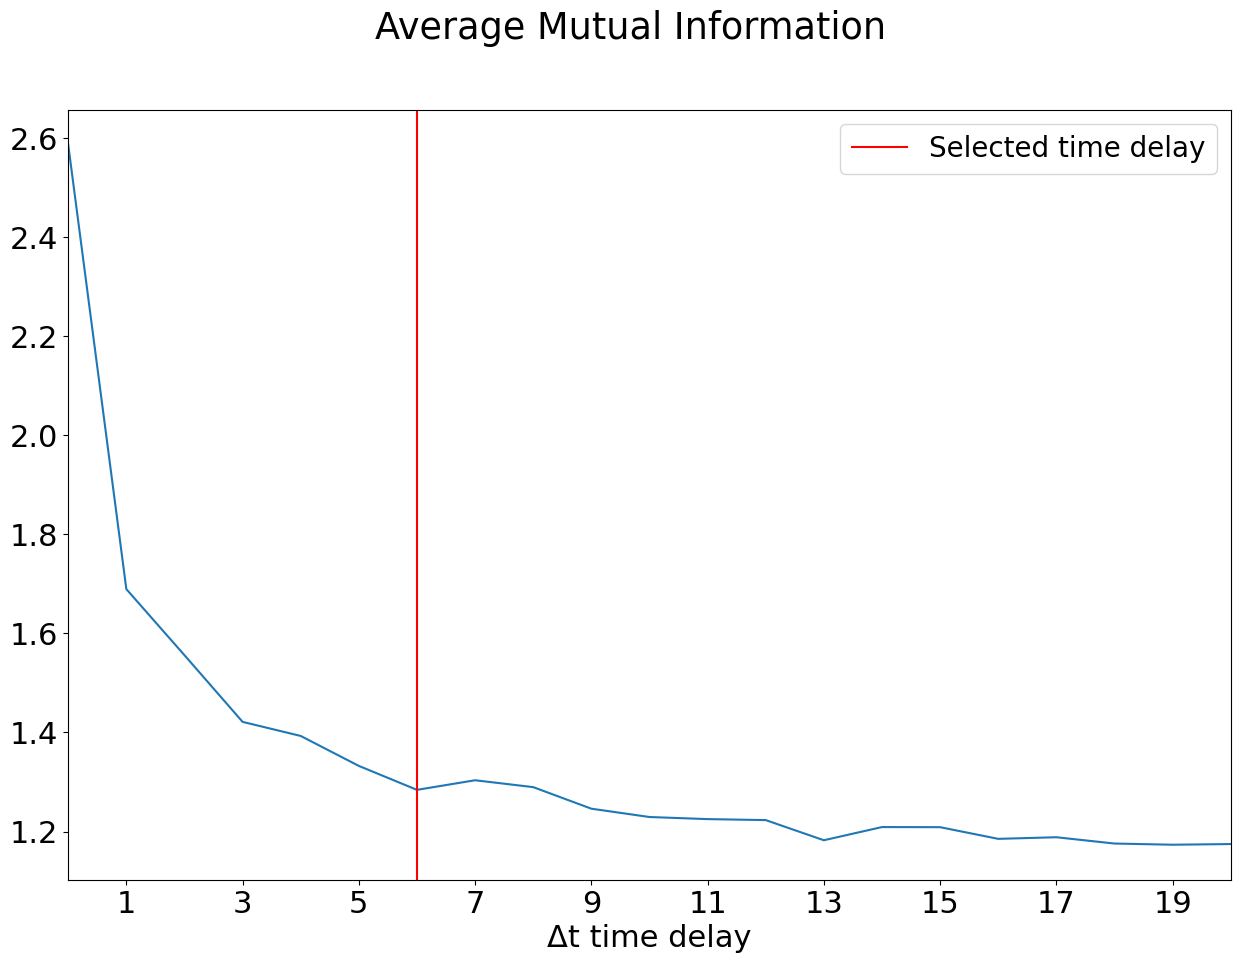

[ 6 13 16 19]
6


In [5]:
os.system("./mutual stocks -D20 -o files/mutual_stocks -V0")
m_site1 = np.loadtxt("files/mutual_stocks", delimiter =' ', usecols =(1) , skiprows=0)
fig2, axs = plt.subplots(1)
fig2.suptitle("Average Mutual Information")
axs.plot(m_site1)
plt.axvline(x = 6, color = 'red', label = 'Selected time delay')
plt.xticks(range(1,20,2))
axs.set_xlim([0, 20])
#axs.set_ylim([1, 2])
plt.xlabel("Δt time delay")
plt.legend()
fig2.savefig('test_output/AMI.eps', format="eps", dpi=650)
plt.show()
plt.close()
g = np.loadtxt("files/mutual_stocks", skiprows=1, usecols=1)
mn = np.where((g[1:-1] < g[:-2]) & (g[1:-1] < g[2:]))[0] + 1
print(mn)
t_min=mn[0]
print(t_min)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


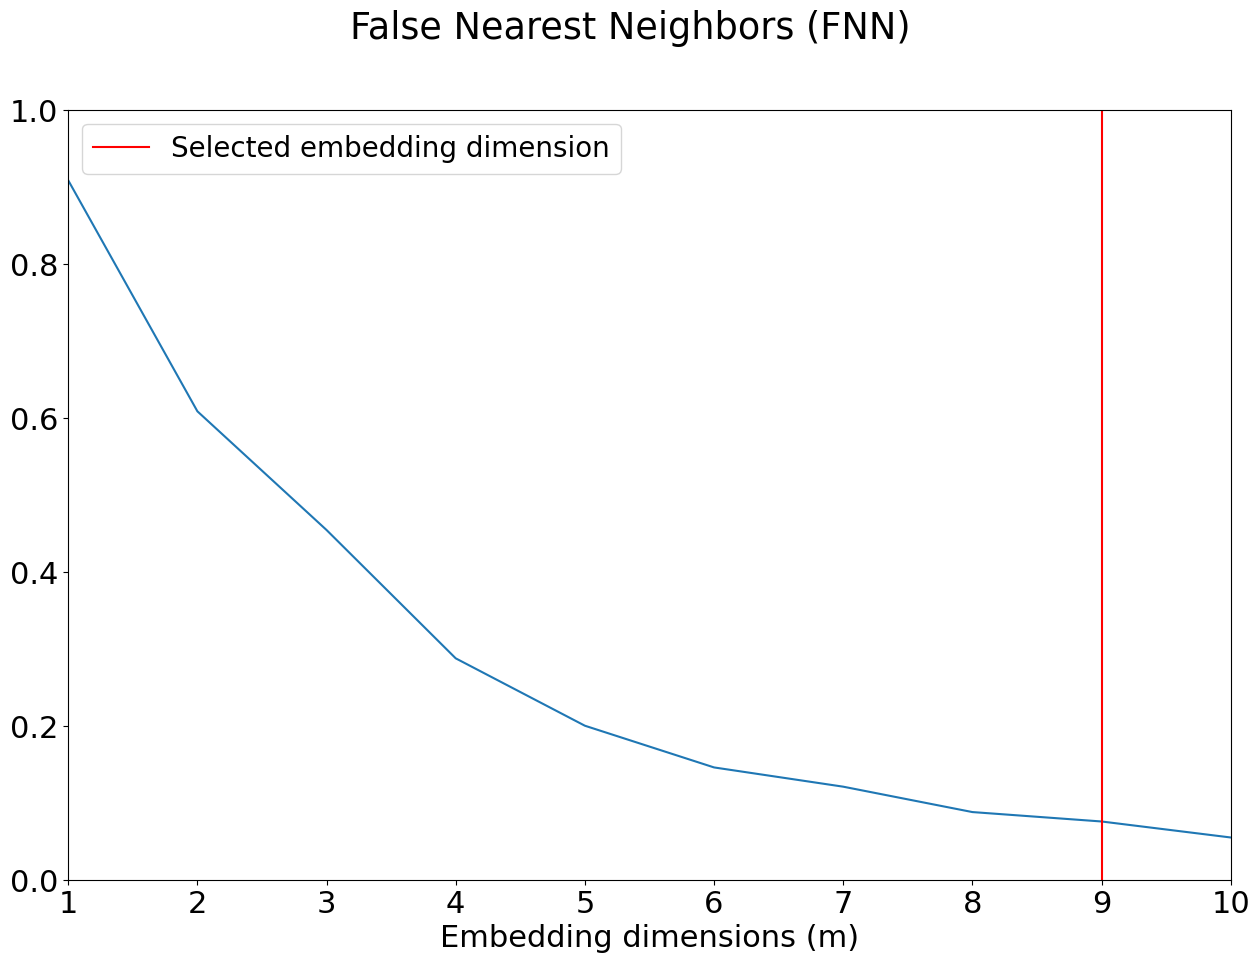

In [6]:
os.system("./false_nearest stocks -M1,10 -d6 -o files/stocks.fnn -V0")
m1 = np.loadtxt("files/stocks.fnn", usecols=1)
d1 = np.loadtxt("files/stocks.fnn", usecols=0)
fig2, ax = plt.subplots(1)
fig2.suptitle("False Nearest Neighbors (FNN)")
ax.plot(d1, m1)
#ax.set_yscale("log")
plt.xticks(range(1,20,1))
plt.xlabel("Embedding dimensions (m)")
plt.axvline(x = 9, color = 'red', label = 'Selected embedding dimension')
plt.legend()
ax.set_xlim([1, 10])
ax.set_ylim([0.00, 1])
fig2.savefig('test_output/FNN.eps', format="eps", dpi=650)
plt.show()
plt.close()


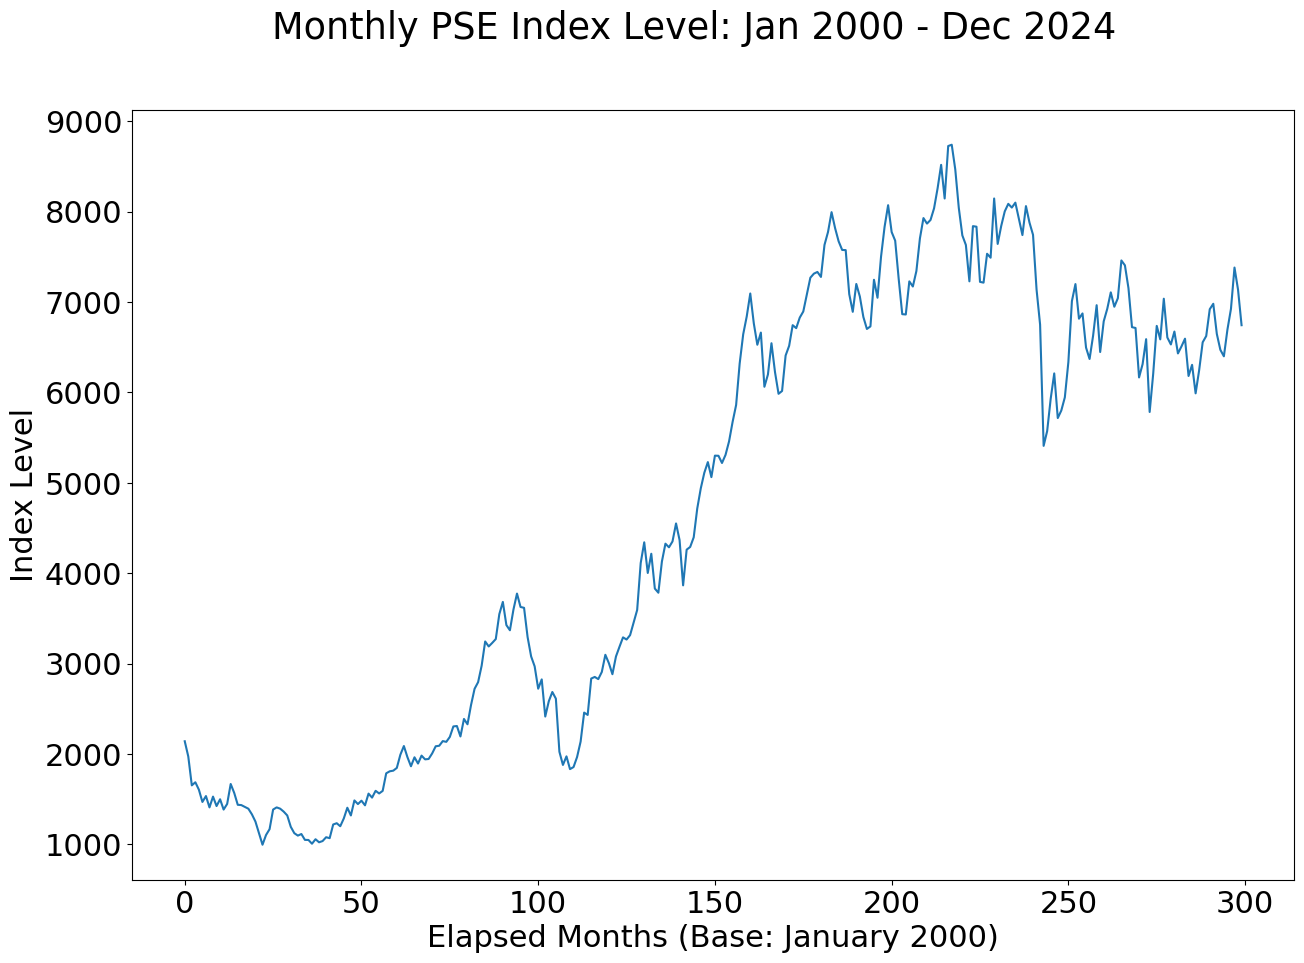

In [7]:
f1, ax1 = plt.subplots(1)
f1.suptitle("Monthly PSE Index Level: Jan 2000 - Dec 2024")
ax1.plot(data)
plt.xlabel("Elapsed Months (Base: January 2000)")
plt.ylabel("Index Level")
f1.savefig('test_output/closing_price.eps', format="eps", dpi=650)

# WIAAFT surrogate test

In [8]:
def sur_test_WIAAFT(m, thr):
    return open_file("surro_index/WIAAFT/qp_surr", m, thr)
    

WIAAFT surrogate datasets generated


  0%|                                                     | 0/8 [00:00<?, ?it/s]

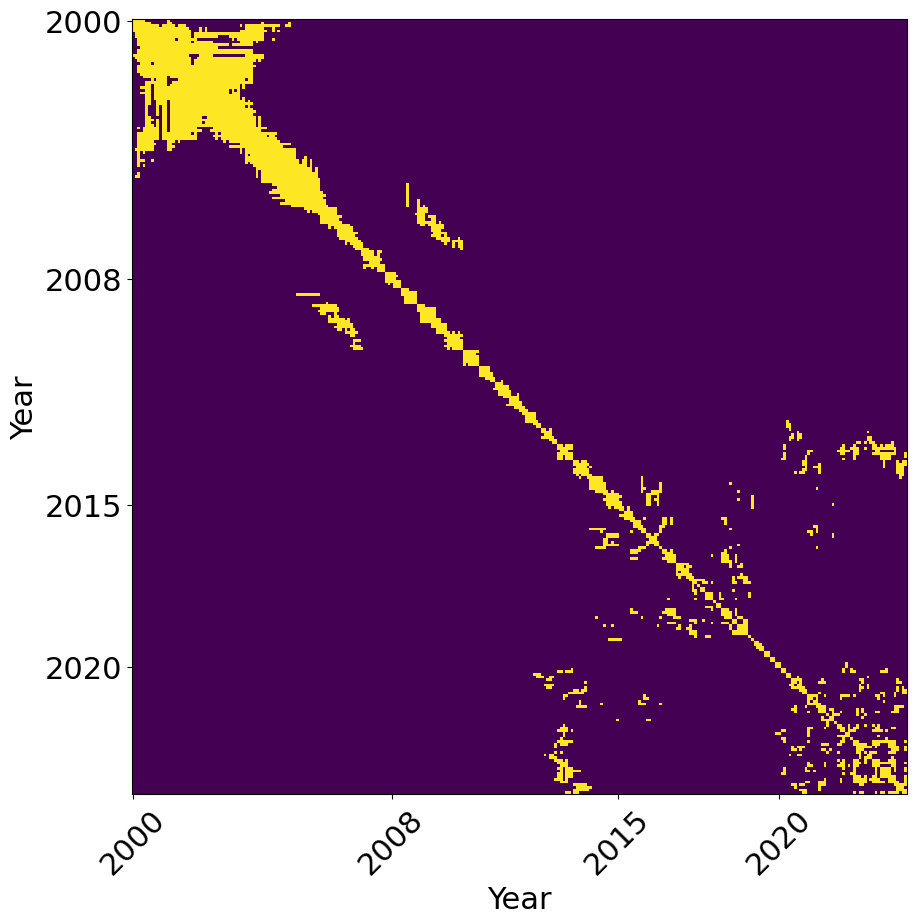

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


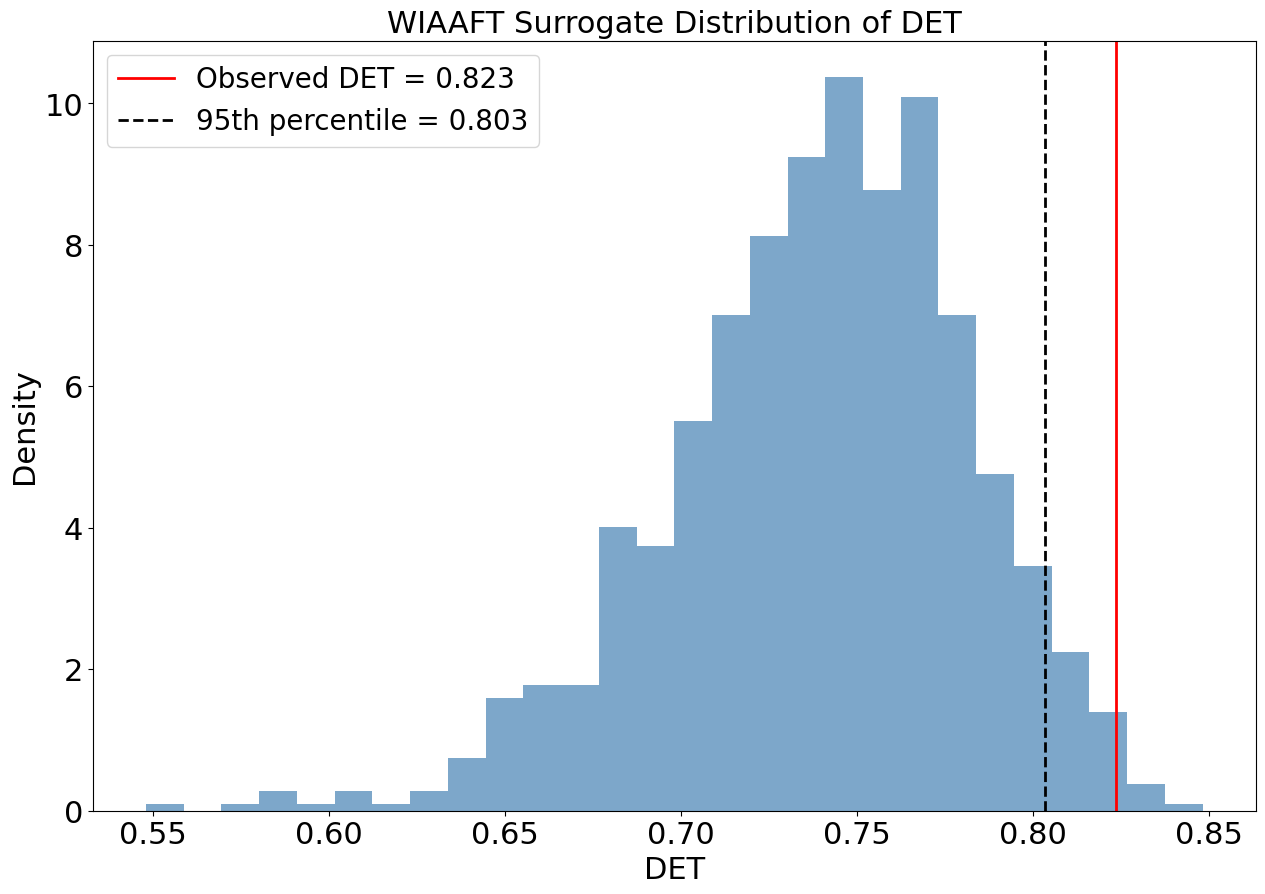

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


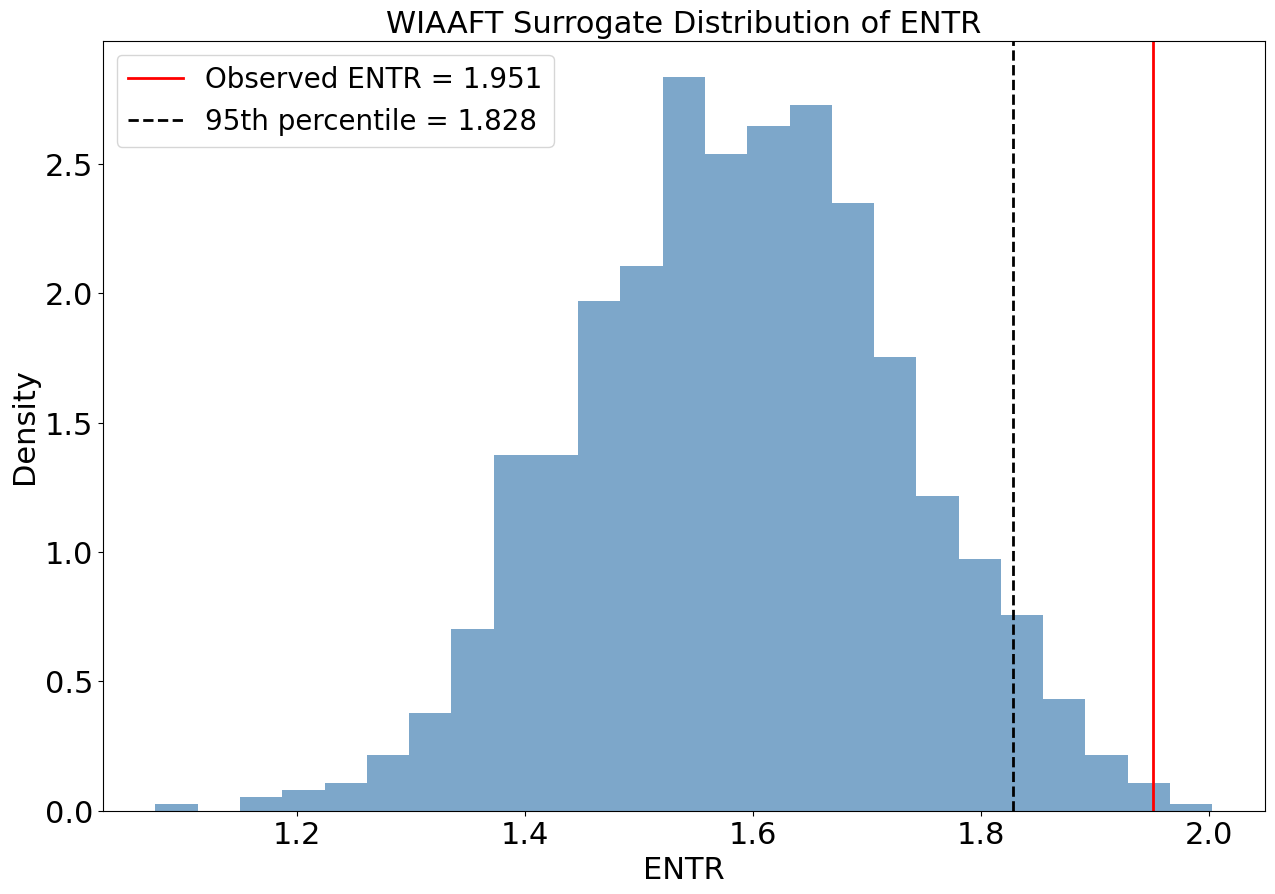

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


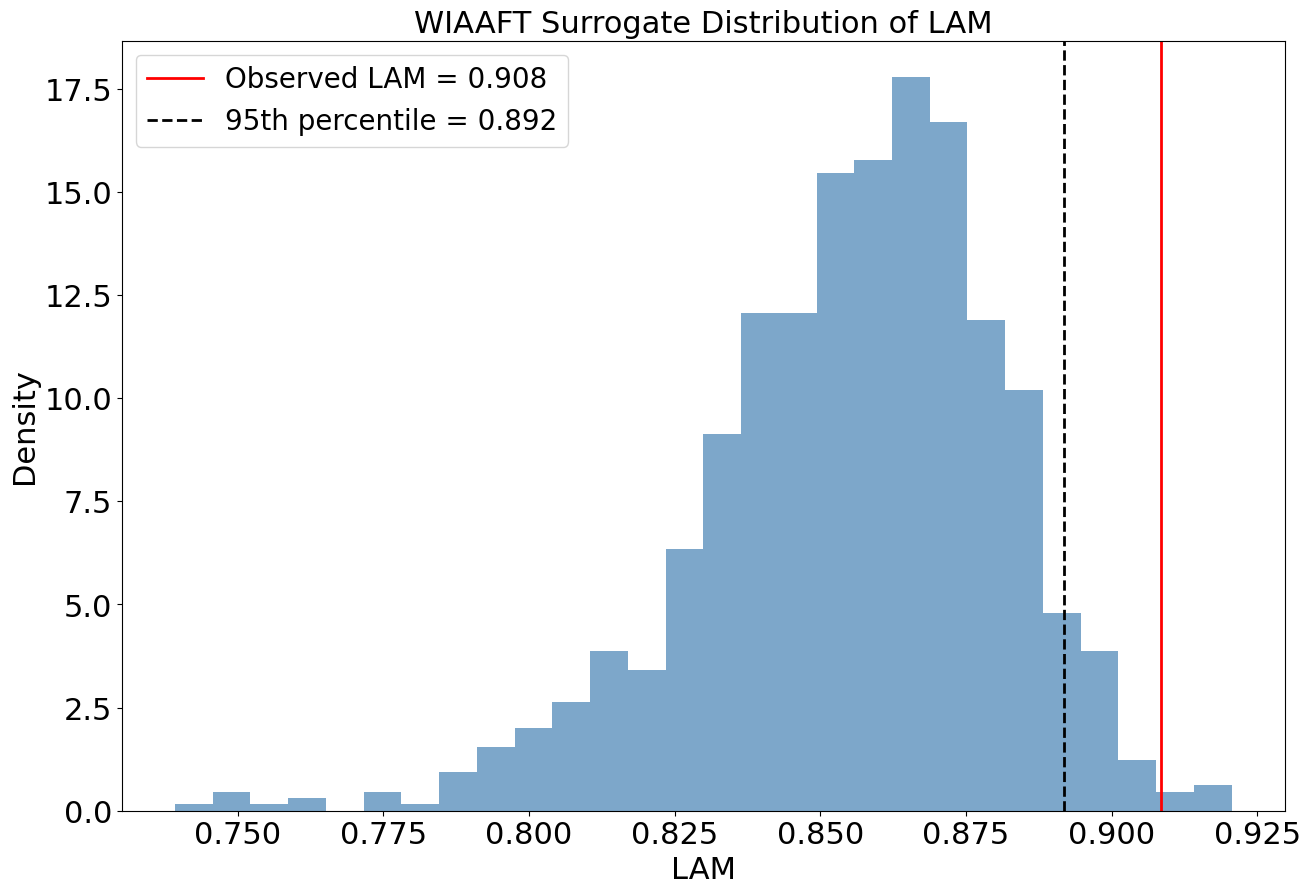

 12%|█████▋                                       | 1/8 [00:04<00:33,  4.84s/it]

RQA  stocks Embedding dimensions:3 
 DET of original:0.8234075608471688 
 Recurrence rate: 0.050033757716049385 
Threshold:0.23889999999999 
 Laminarity:0.9084337349375701 
Shannon Entropy:1.9508420715265373 
Rank-order p-value (det):0.012 
Rank-order p-value (lam):0.006 
Rank-order p-value (entr):0.002 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



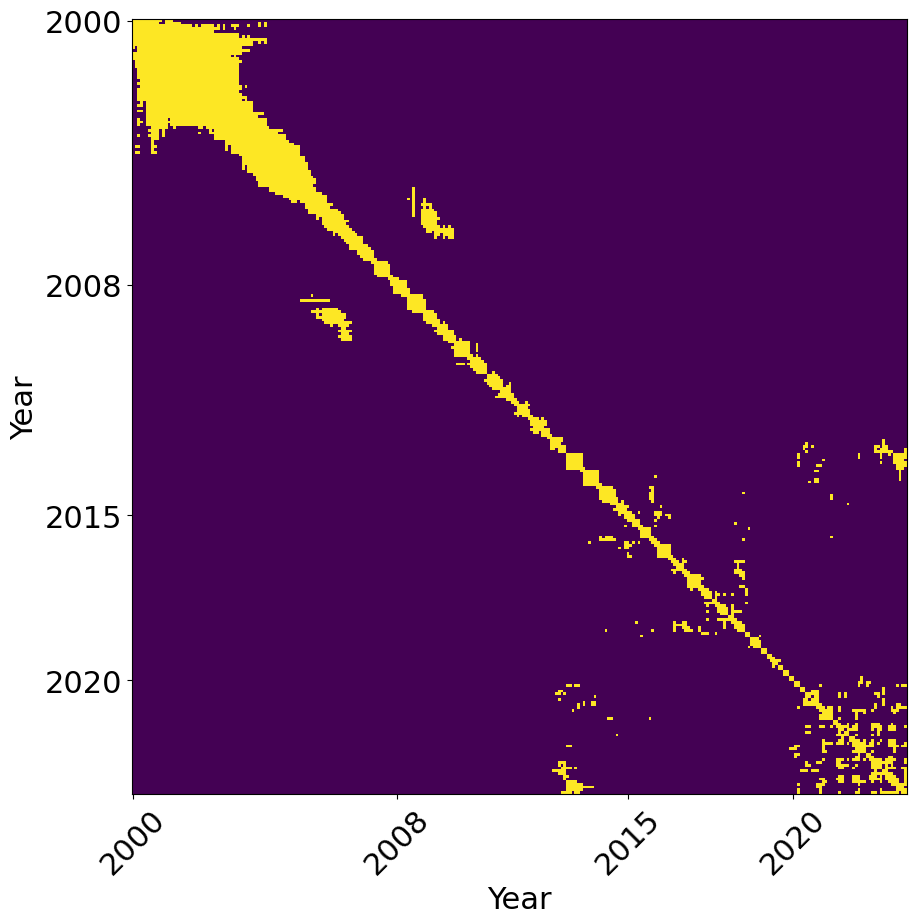

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


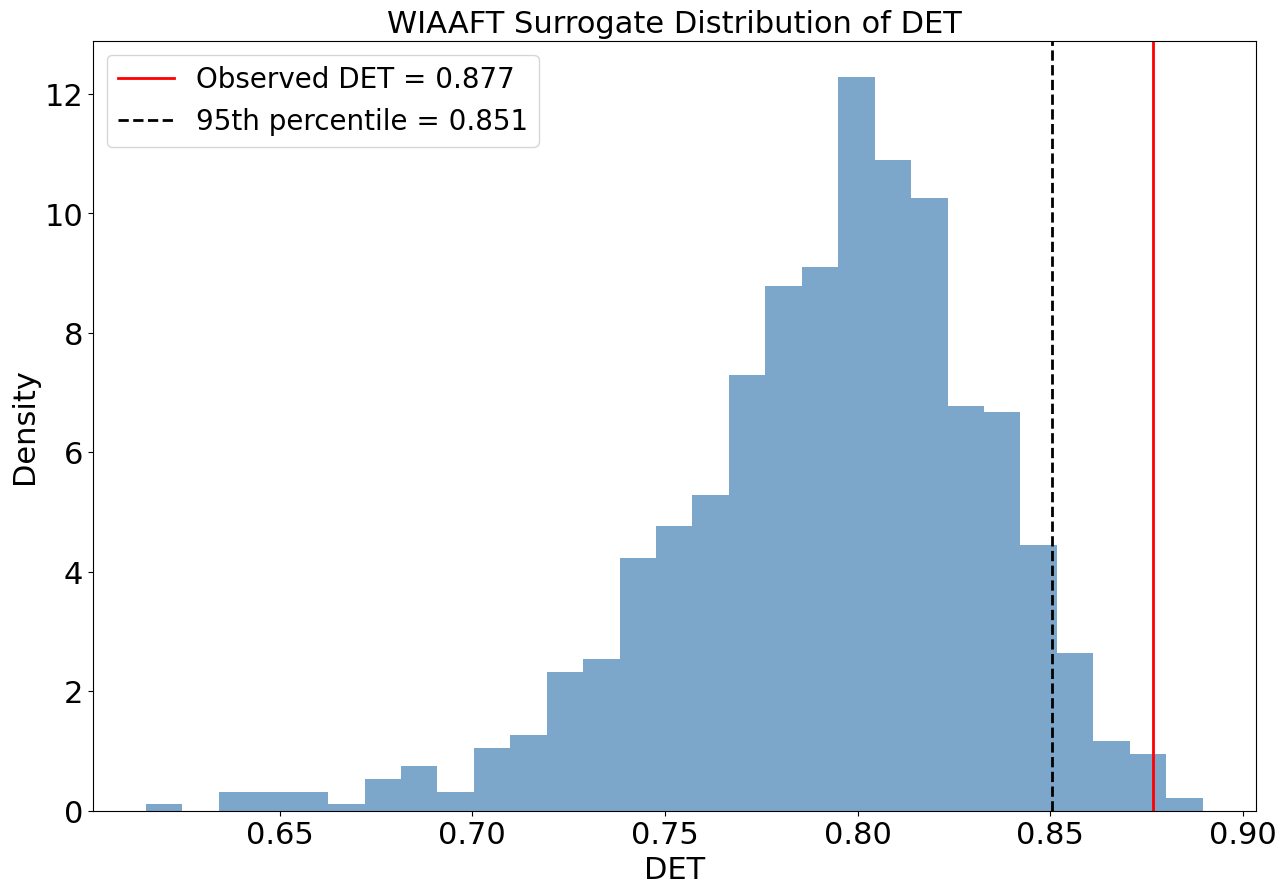

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


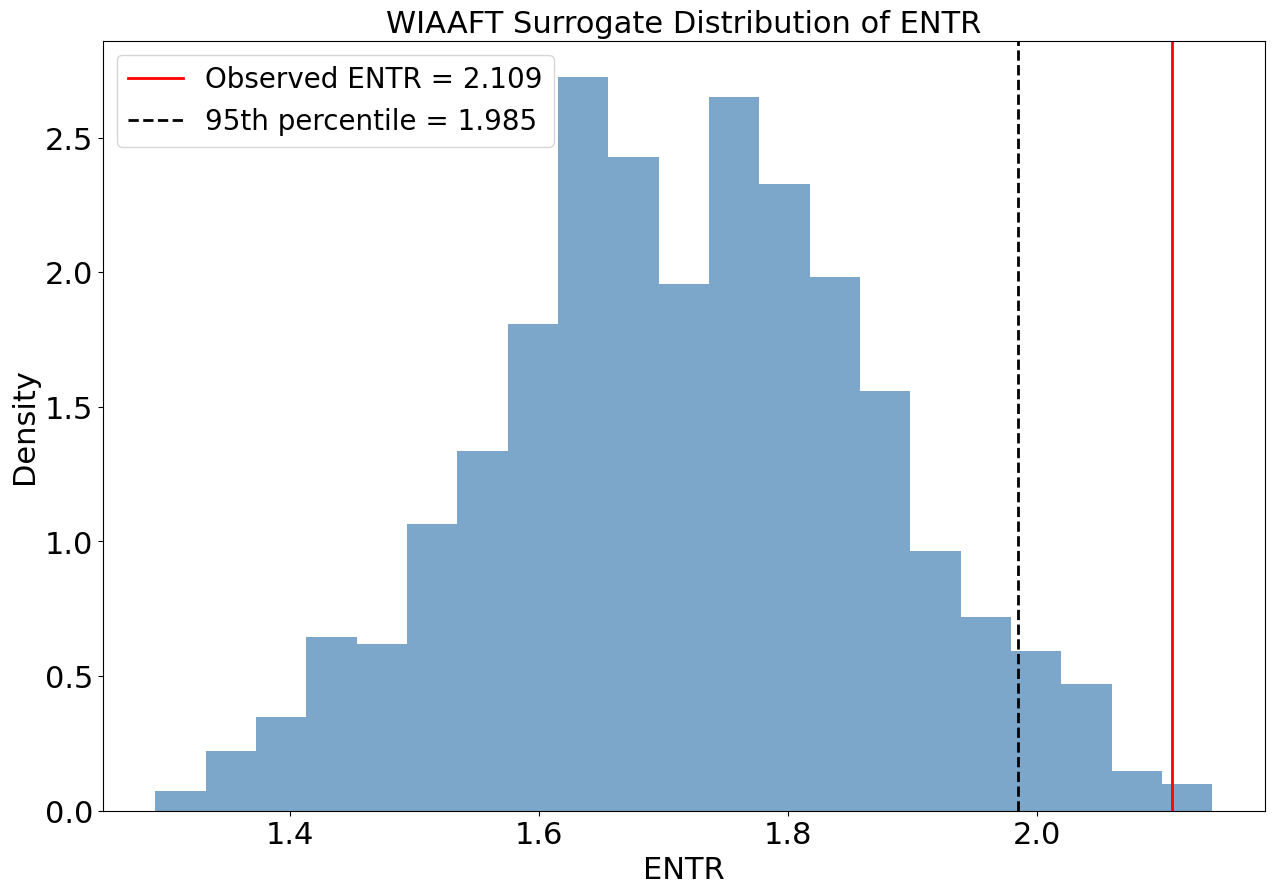

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


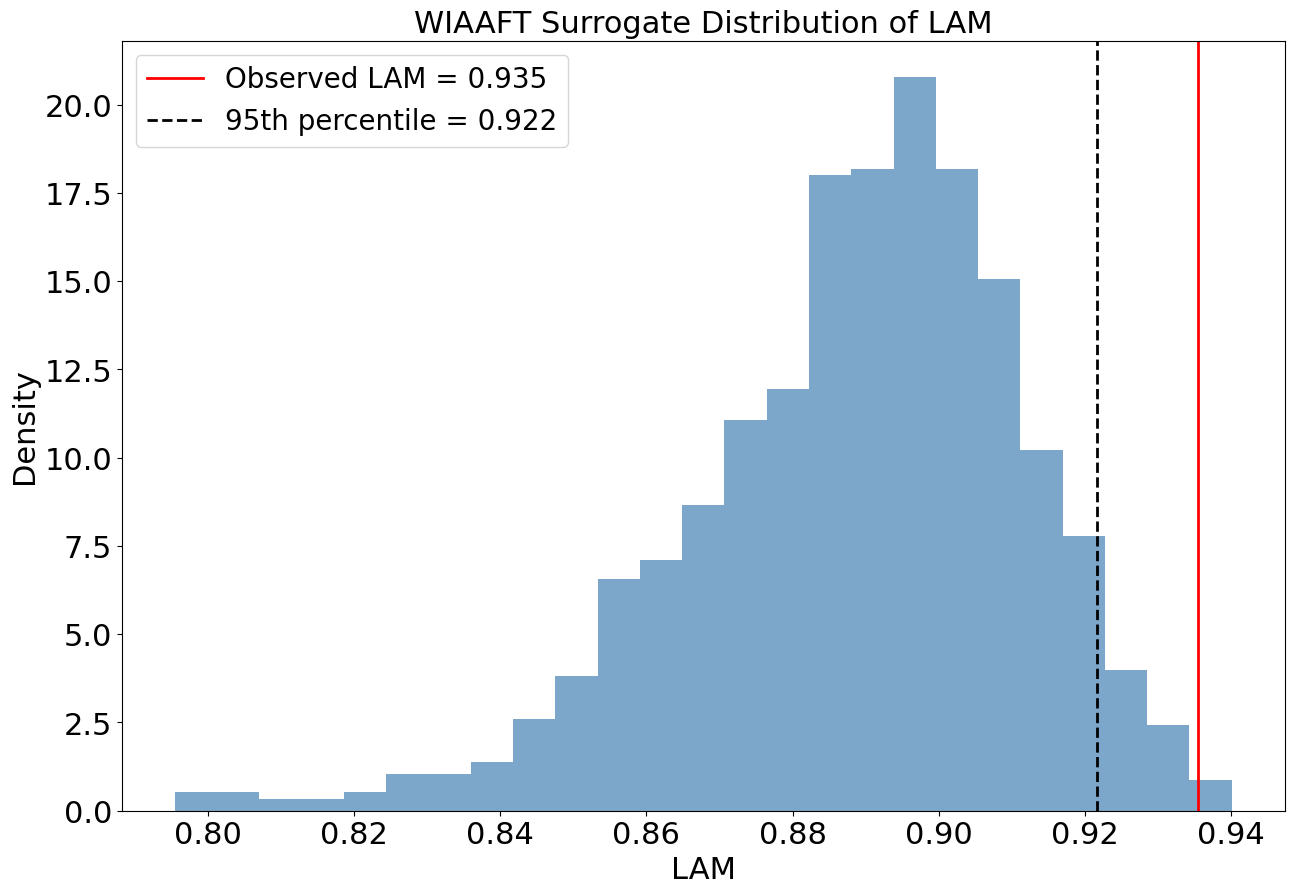

 25%|███████████▎                                 | 2/8 [00:10<00:30,  5.03s/it]

RQA  stocks Embedding dimensions:4 
 DET of original:0.876690102755877 
 Recurrence rate: 0.050047784316684274 
Threshold:0.3259999999999804 
 Laminarity:0.9354271356760416 
Shannon Entropy:2.1089753584358295 
Rank-order p-value (det):0.003 
Rank-order p-value (lam):0.005 
Rank-order p-value (entr):0.003 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



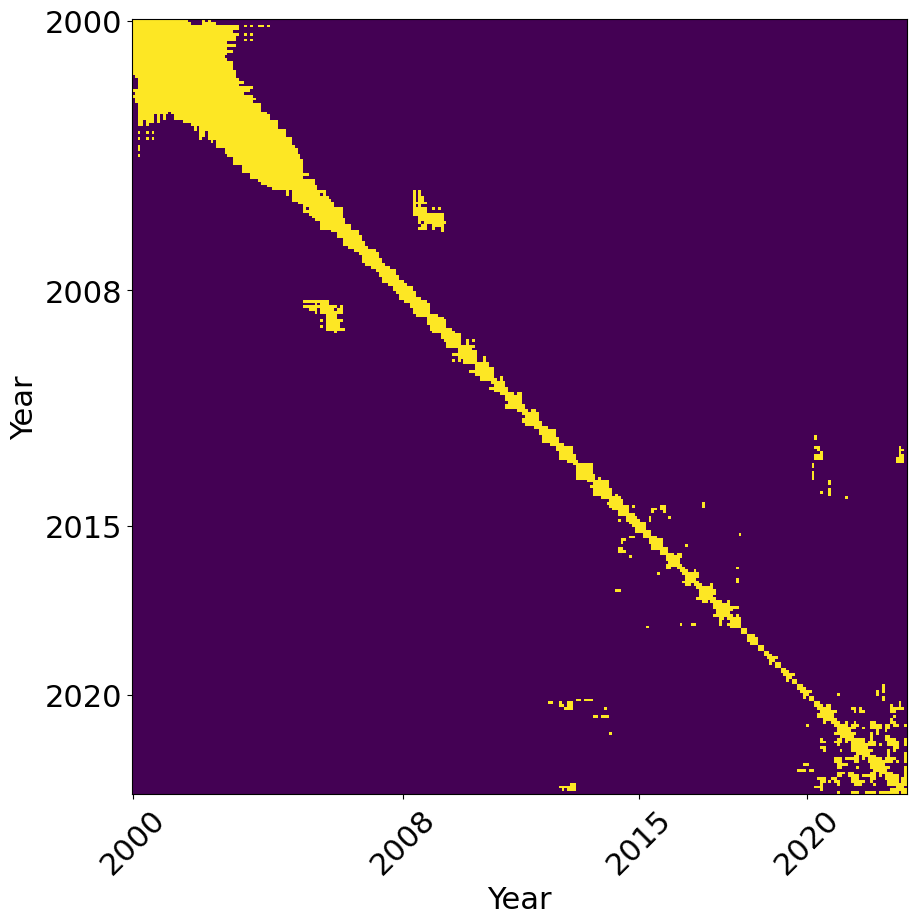

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


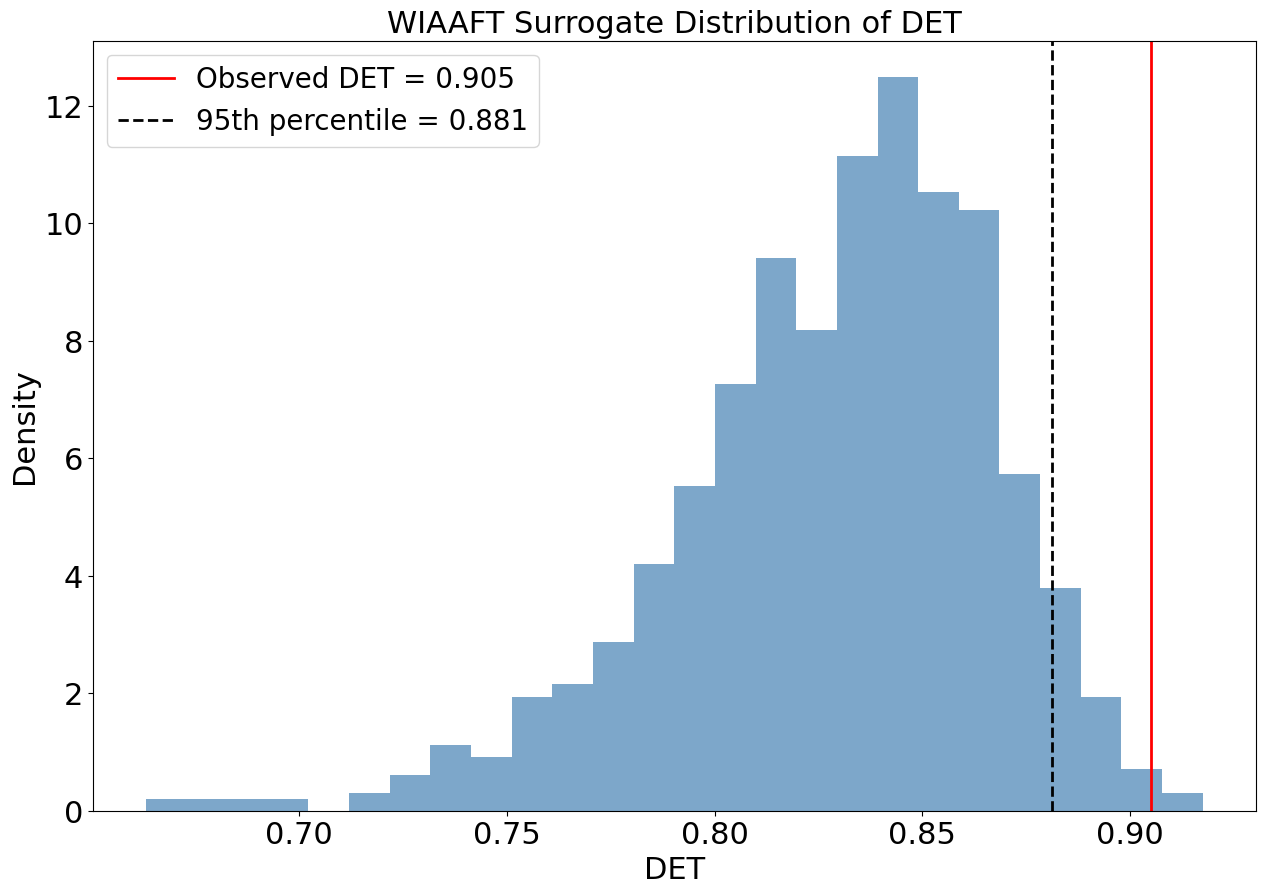

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


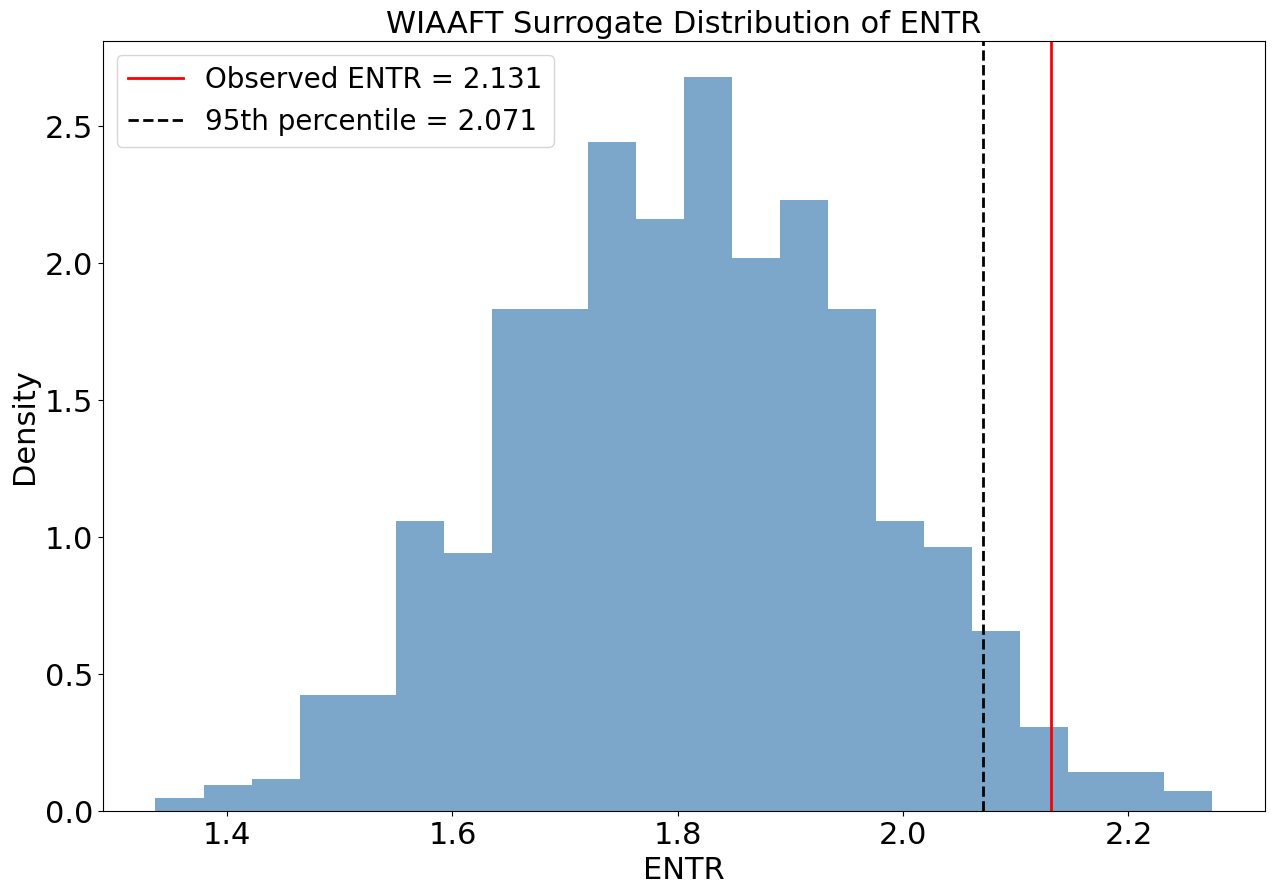

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


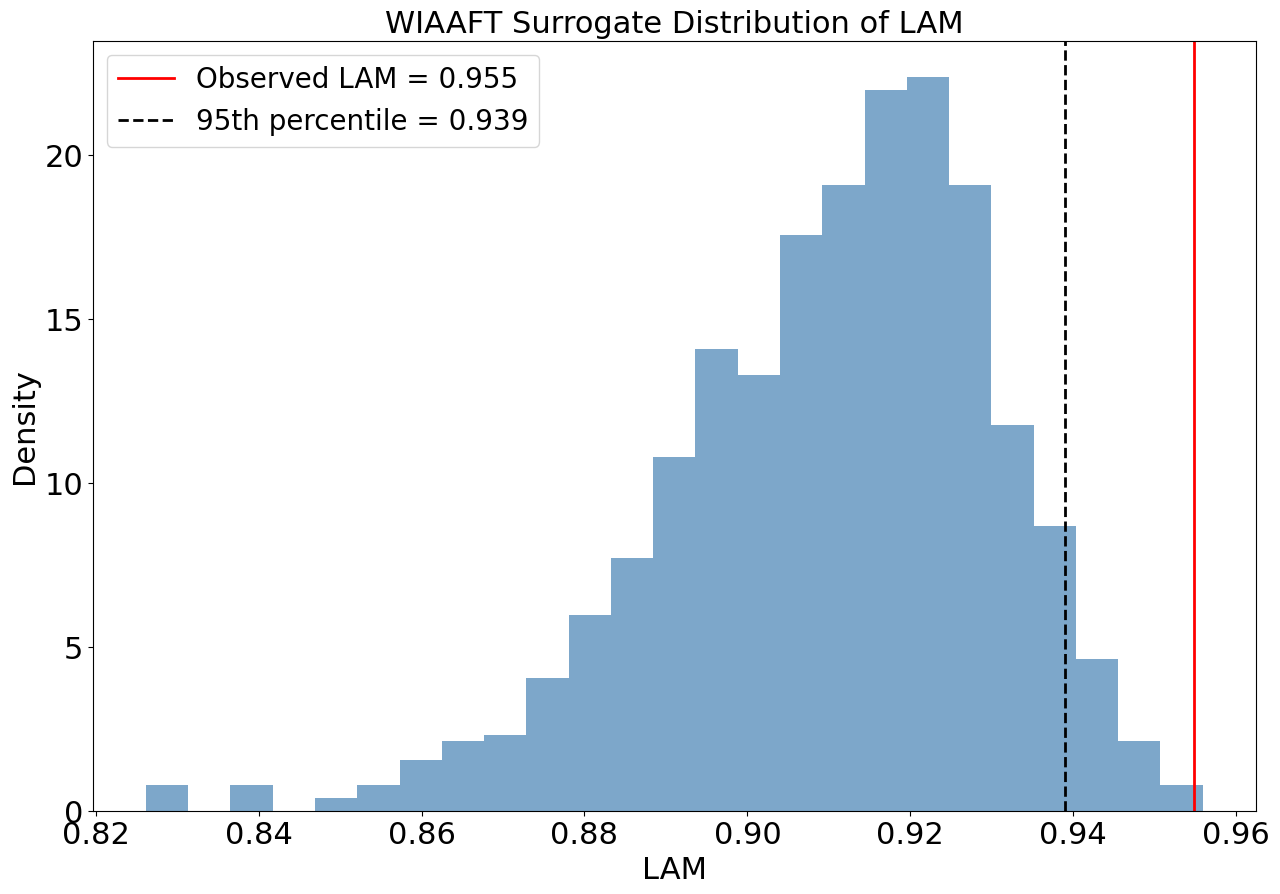

 38%|████████████████▉                            | 3/8 [00:15<00:26,  5.27s/it]

RQA  stocks Embedding dimensions:5 
 DET of original:0.9049235993183222 
 Recurrence rate: 0.050015752993068686 
Threshold:0.40469999999997175 
 Laminarity:0.9548556430421132 
Shannon Entropy:2.1310423583923637 
Rank-order p-value (det):0.005 
Rank-order p-value (lam):0.002 
Rank-order p-value (entr):0.02 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



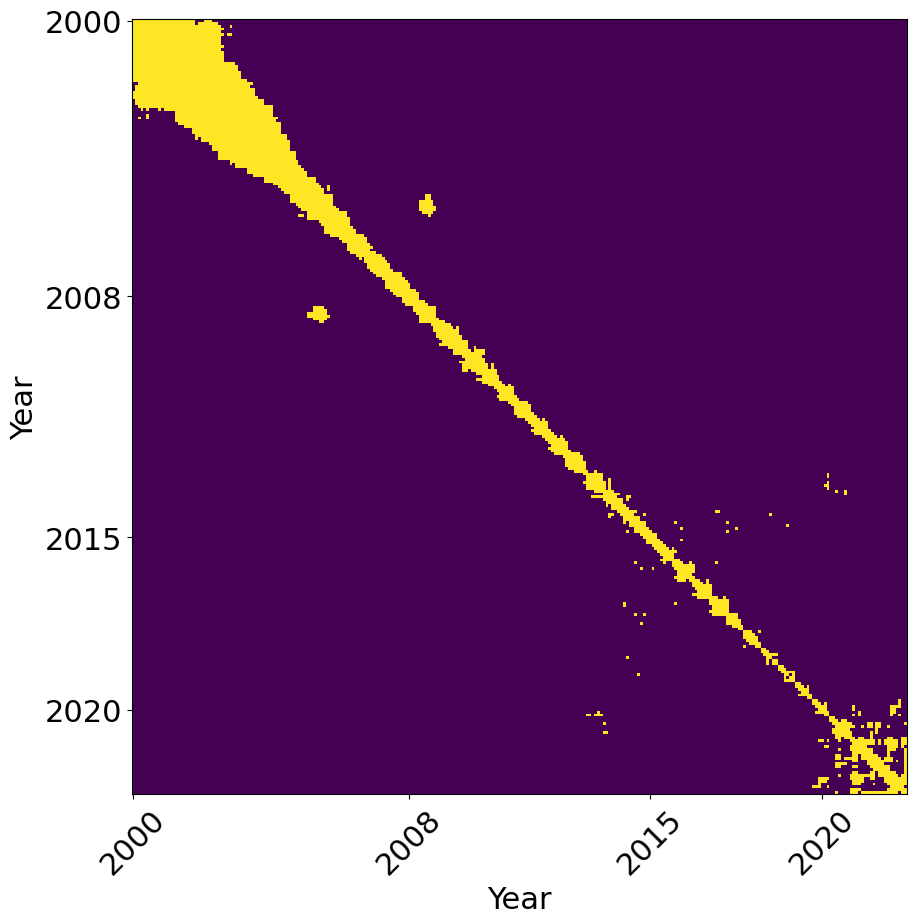

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


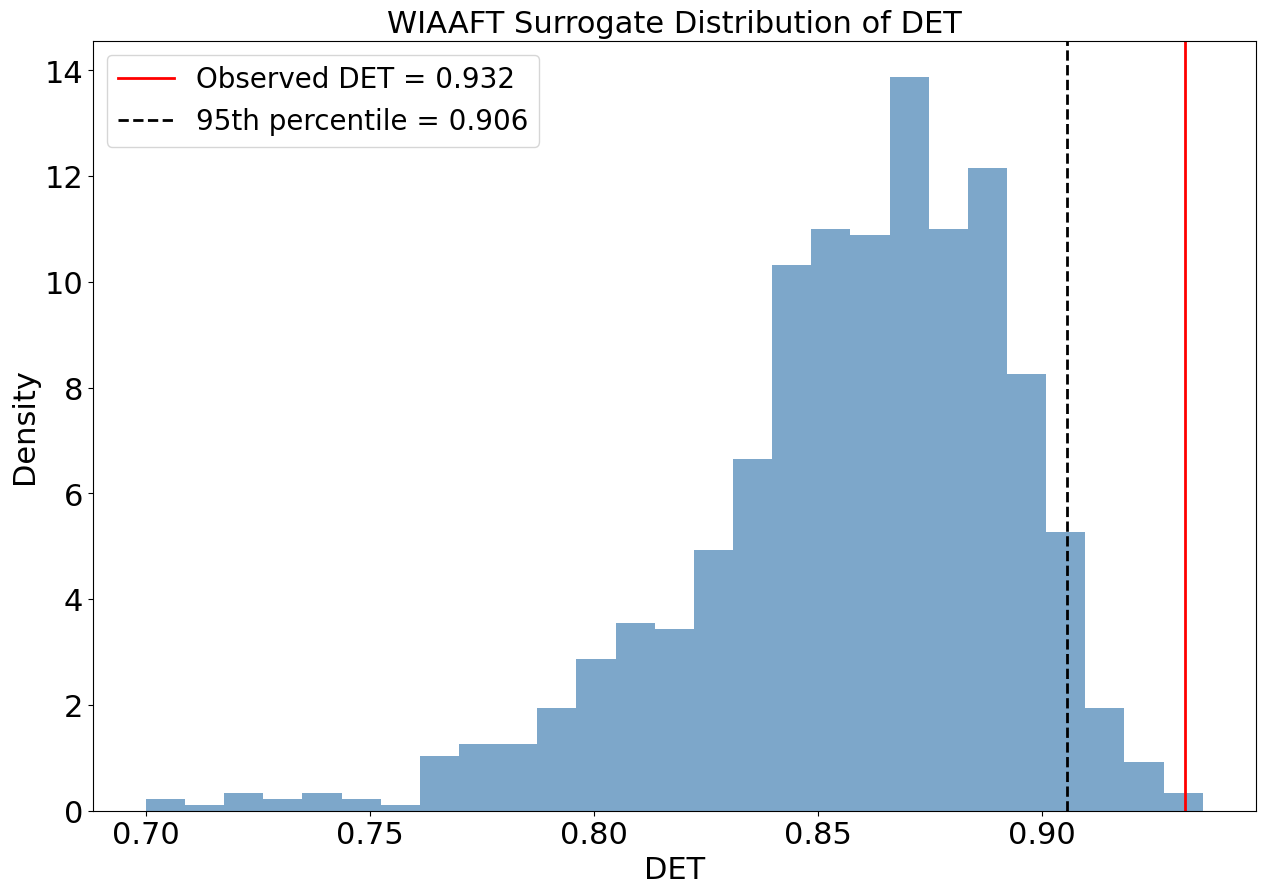

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


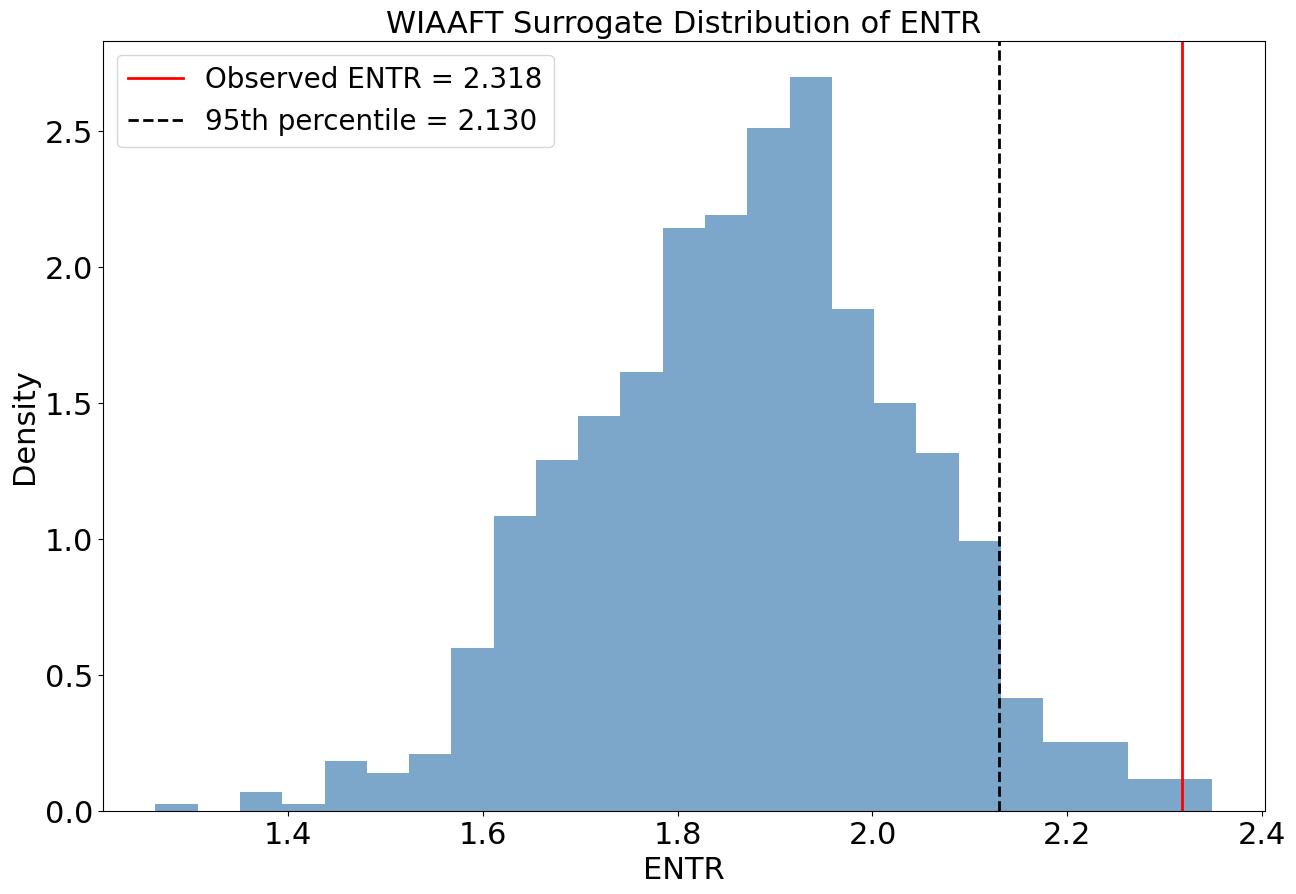

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


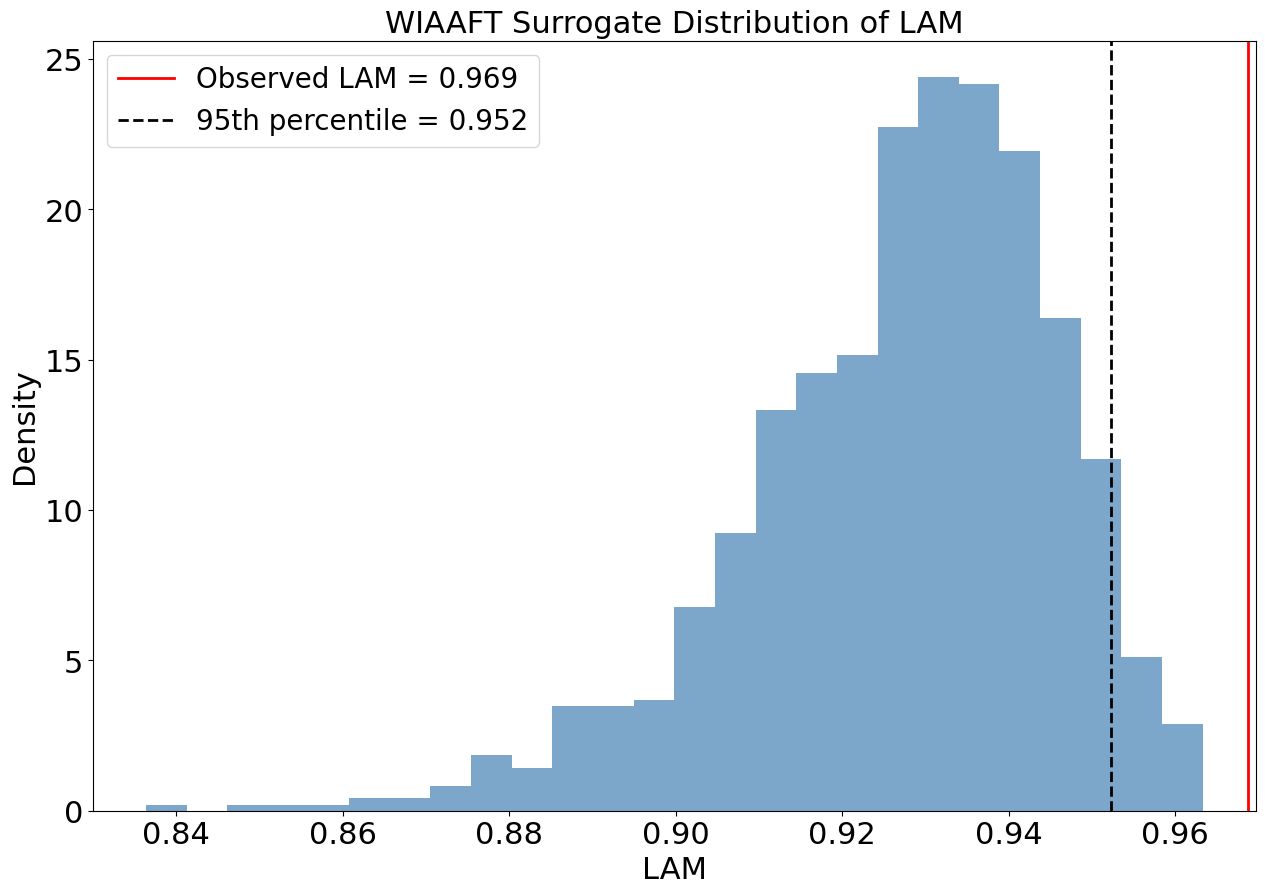

 50%|██████████████████████▌                      | 4/8 [00:21<00:22,  5.67s/it]

RQA  stocks Embedding dimensions:6 
 DET of original:0.9318720379119317 
 Recurrence rate: 0.05001371742112483 
Threshold:0.48369999999996305 
 Laminarity:0.9687328579238379 
Shannon Entropy:2.318085964176623 
Rank-order p-value (det):0.002 
Rank-order p-value (lam):0.001 
Rank-order p-value (entr):0.005 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



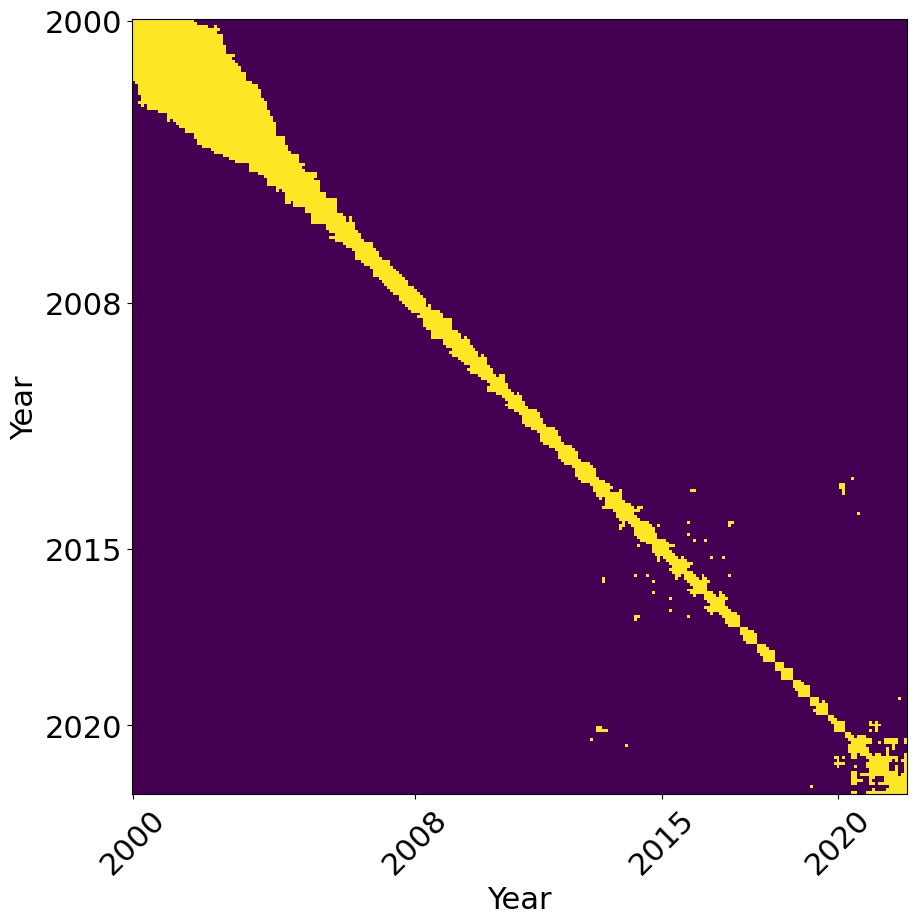

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


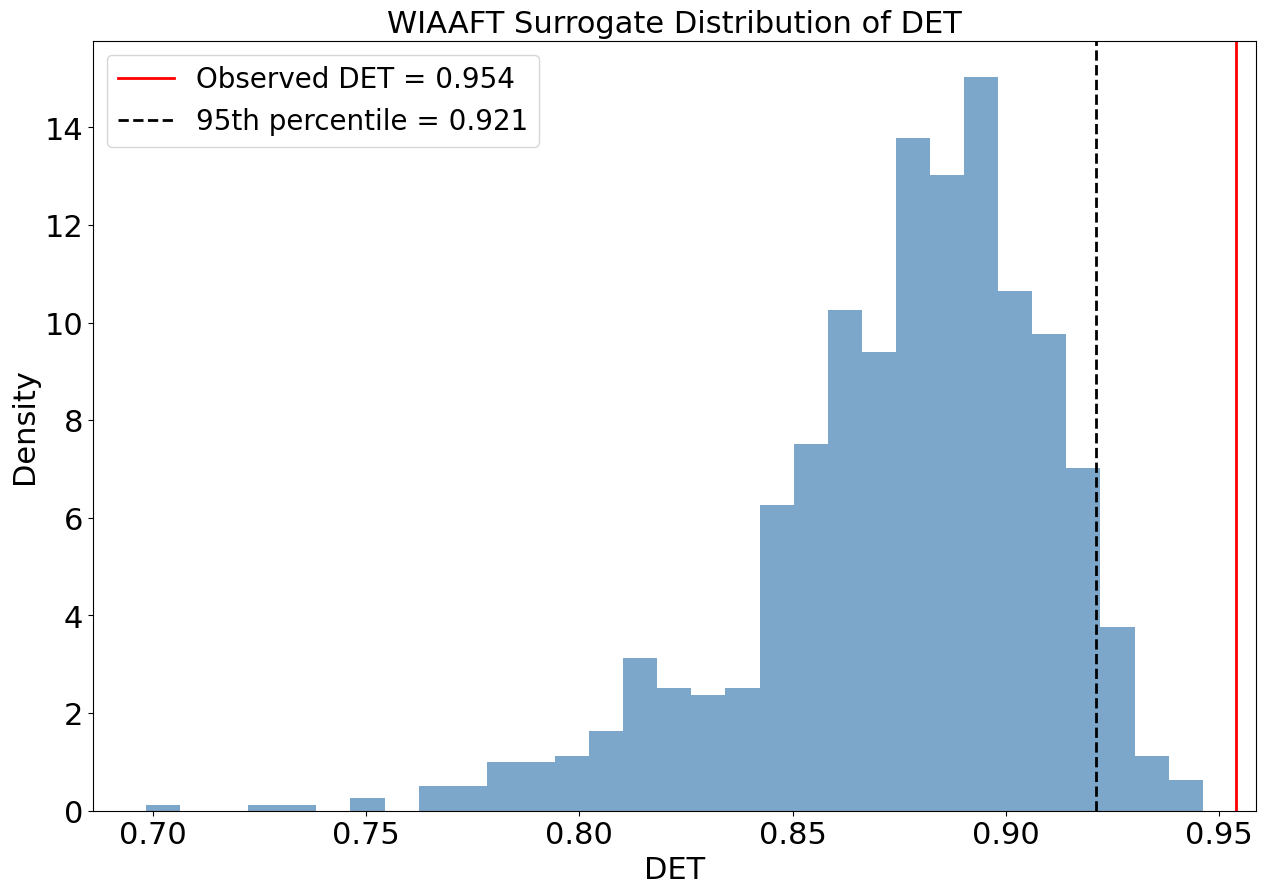

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


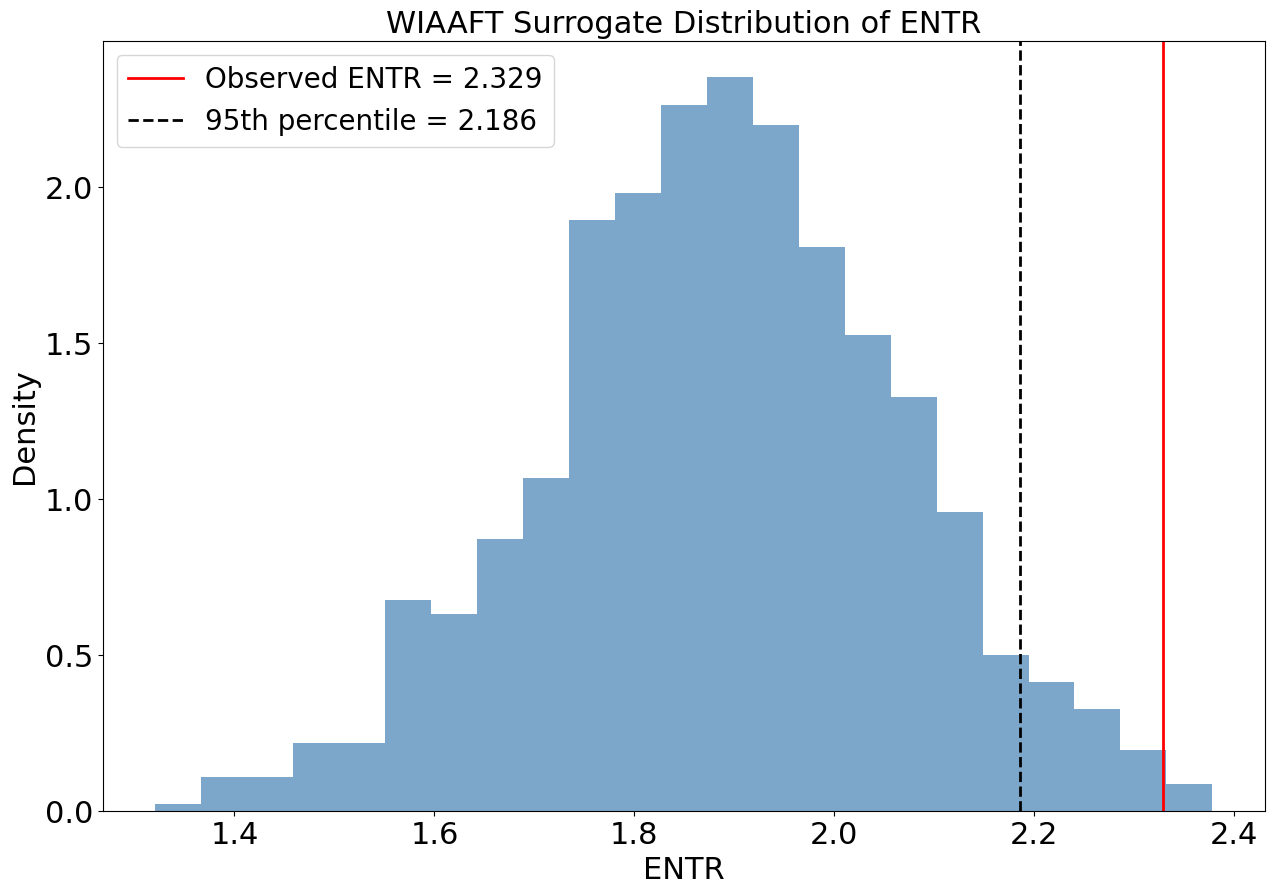

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


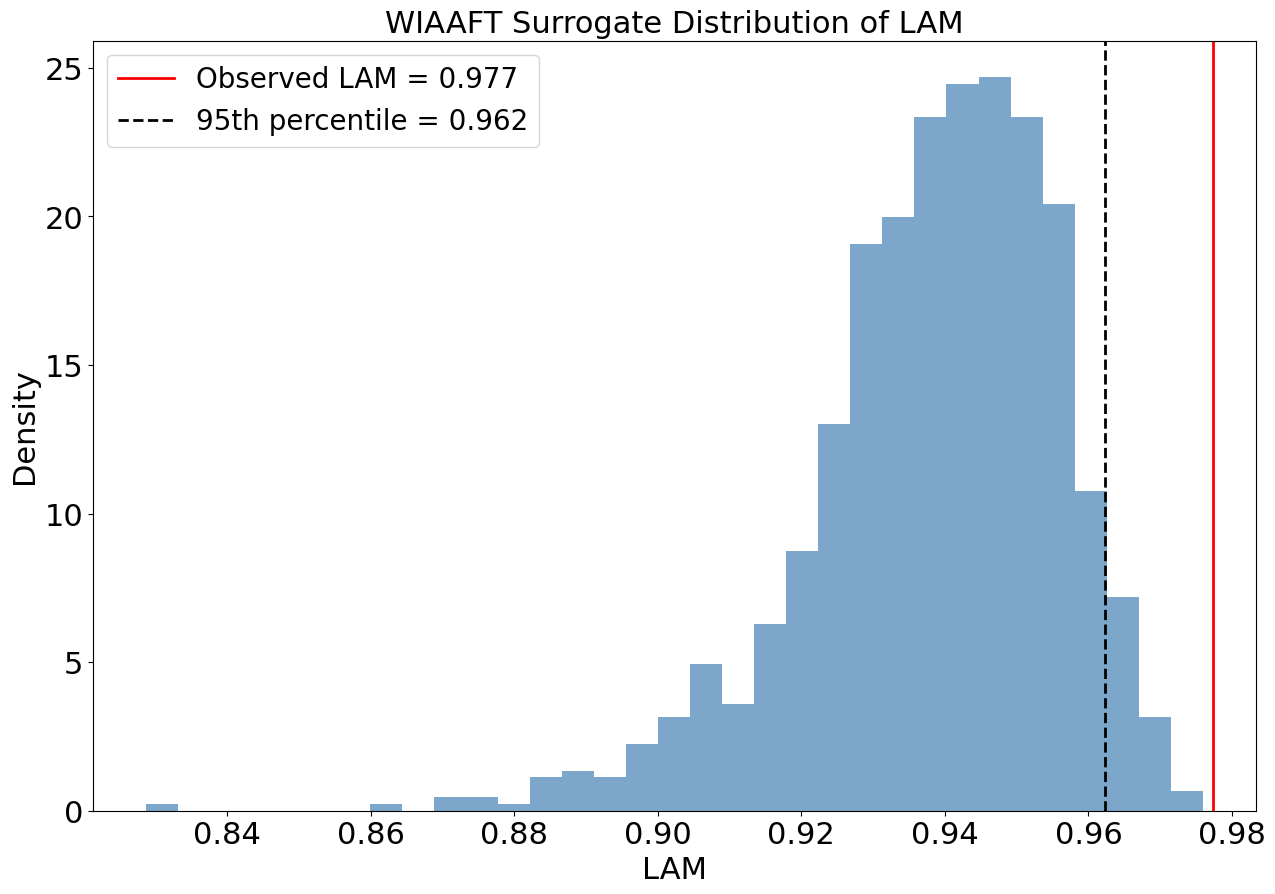

 62%|████████████████████████████▏                | 5/8 [00:28<00:18,  6.16s/it]

RQA  stocks Embedding dimensions:7 
 DET of original:0.9540657976382556 
 Recurrence rate: 0.050017217630854 
Threshold:0.5500999999999557 
 Laminarity:0.9773379231182521 
Shannon Entropy:2.328730875911501 
Rank-order p-value (det):0.001 
Rank-order p-value (lam):0.001 
Rank-order p-value (entr):0.005 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



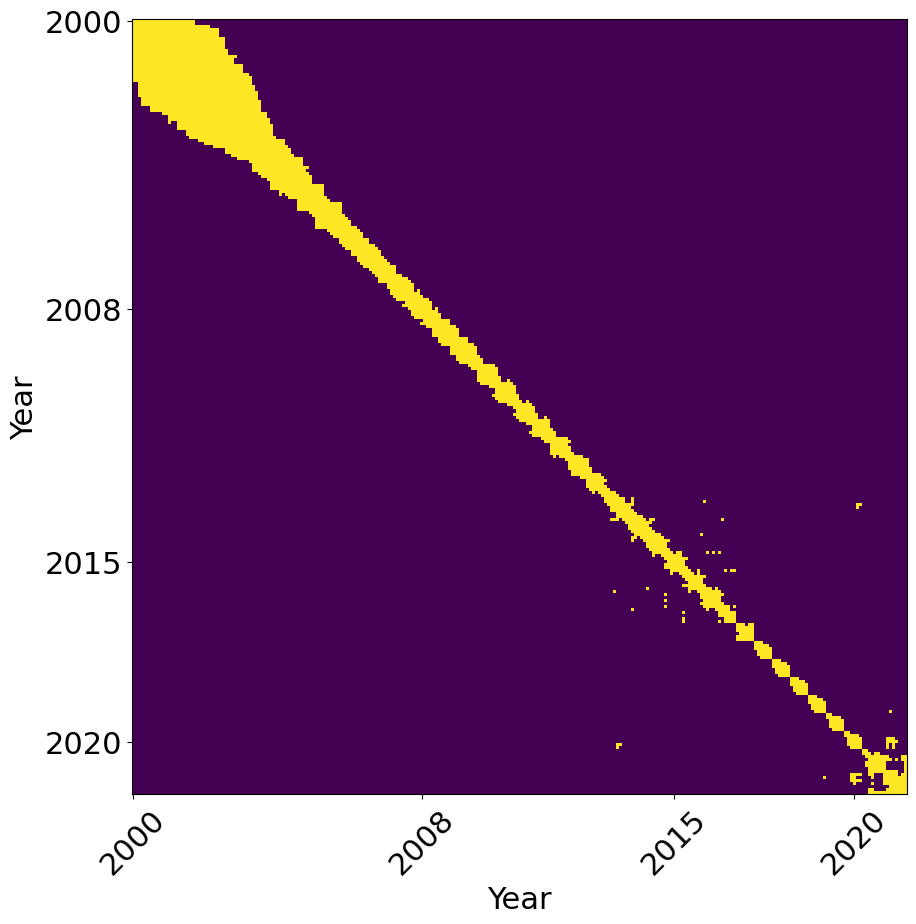

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


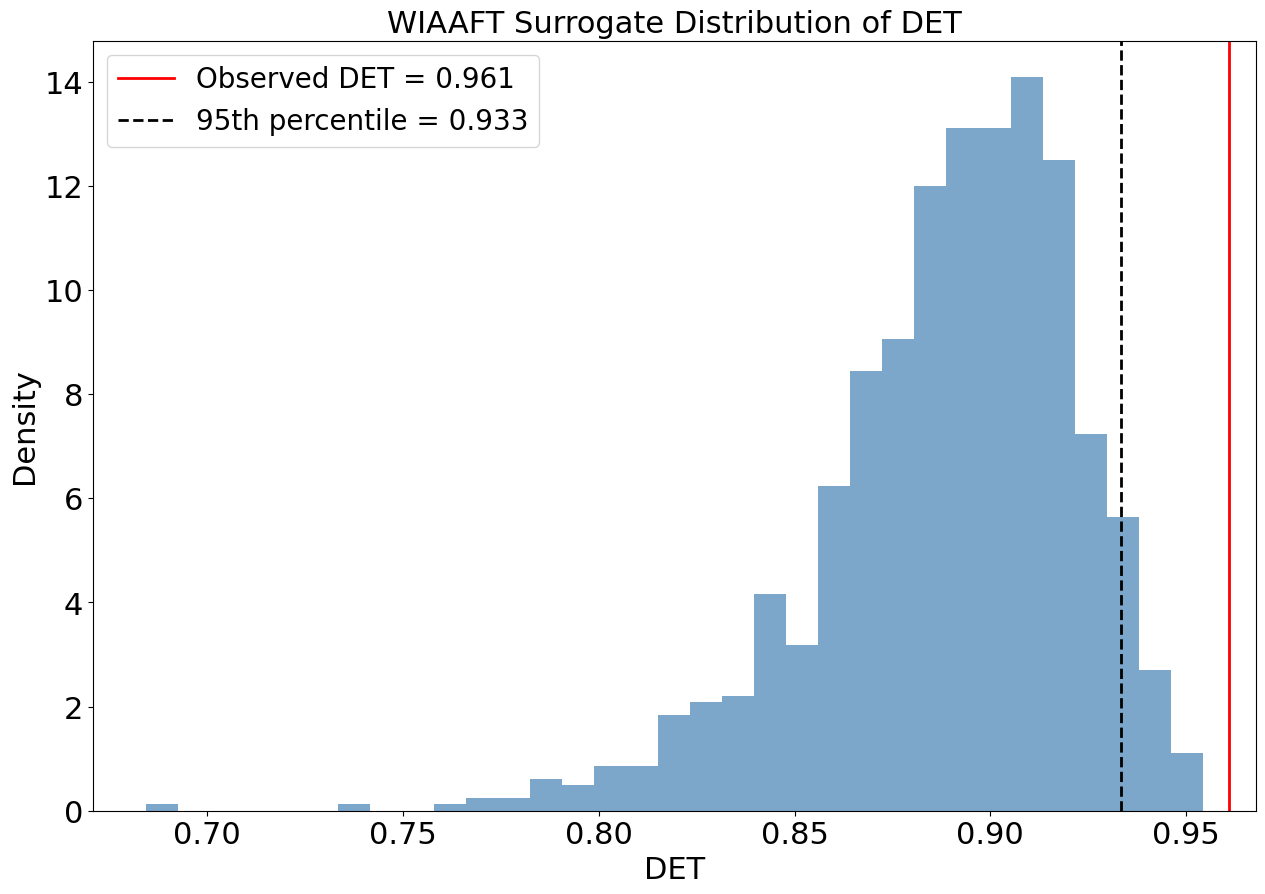

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


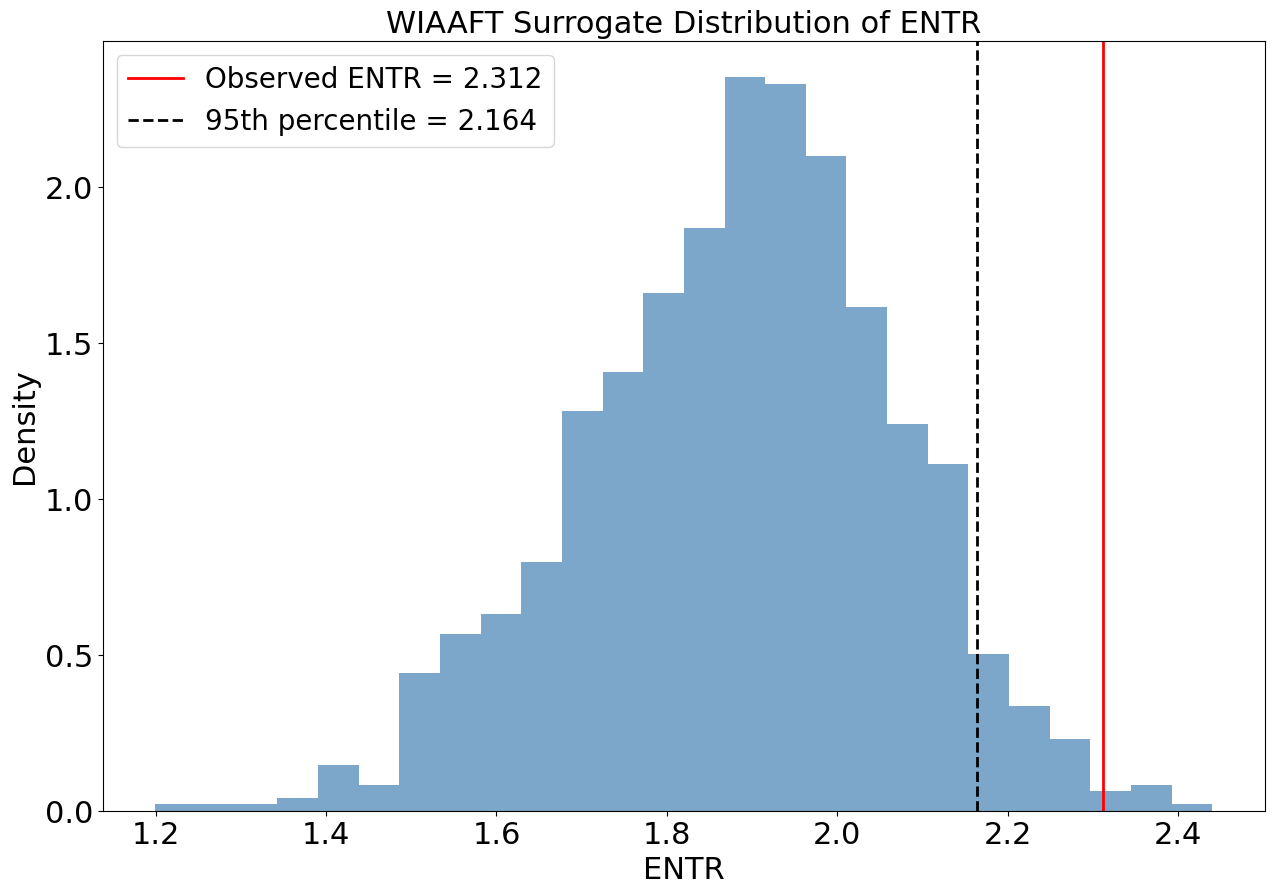

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


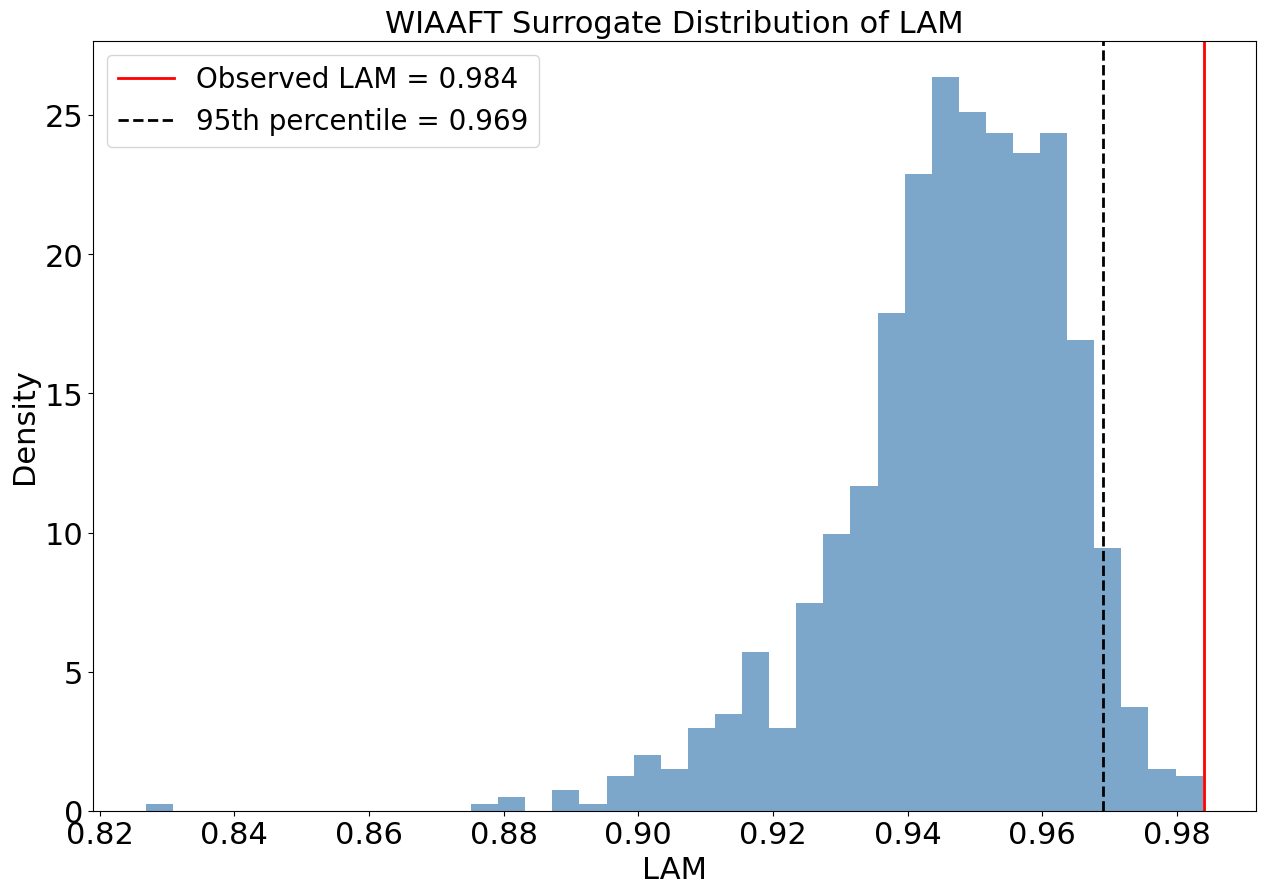

 75%|█████████████████████████████████▊           | 6/8 [00:36<00:13,  6.53s/it]

RQA  stocks Embedding dimensions:8 
 DET of original:0.960937499996872 
 Recurrence rate: 0.050027041644131964 
Threshold:0.6095999999999492 
 Laminarity:0.9840840840811289 
Shannon Entropy:2.312170199777547 
Rank-order p-value (det):0.001 
Rank-order p-value (lam):0.001 
Rank-order p-value (entr):0.009 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



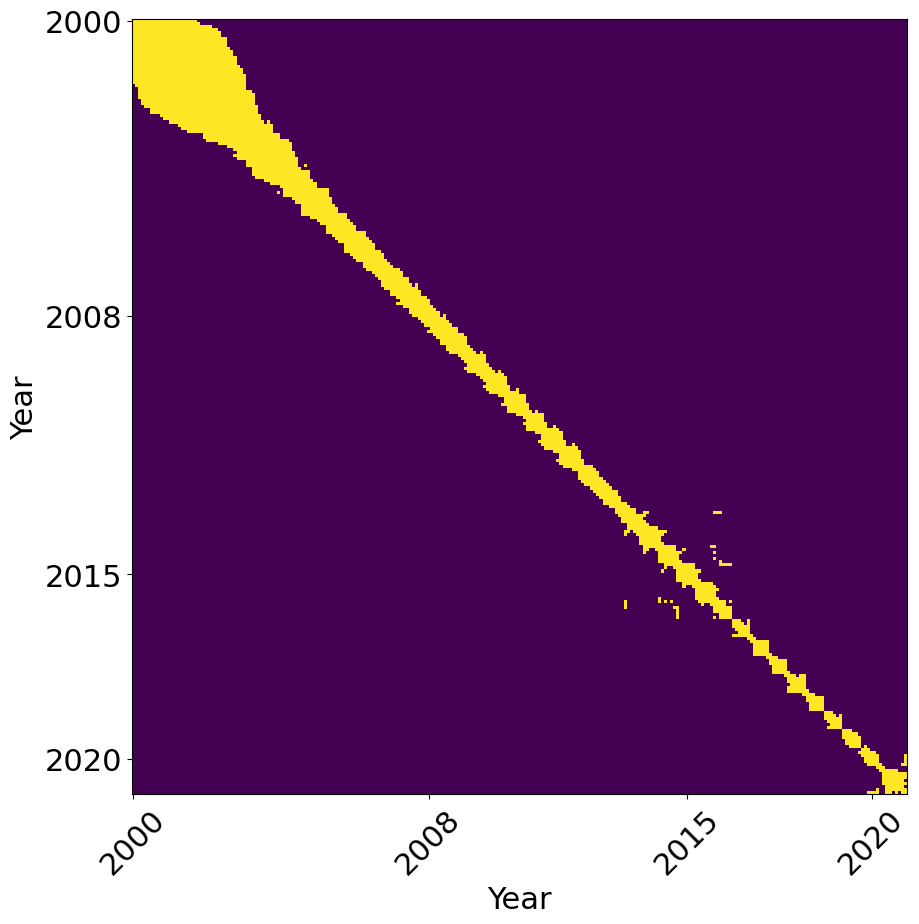

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


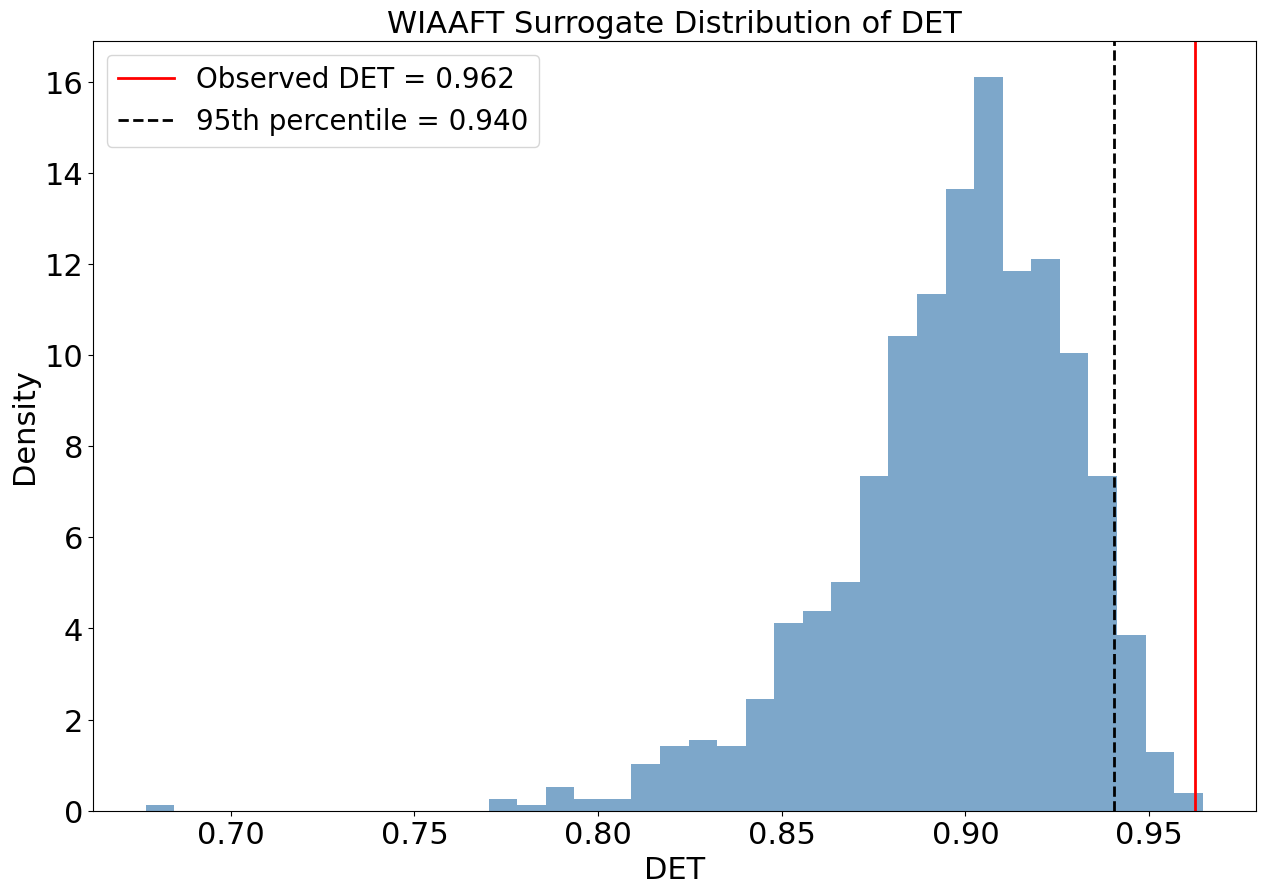

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


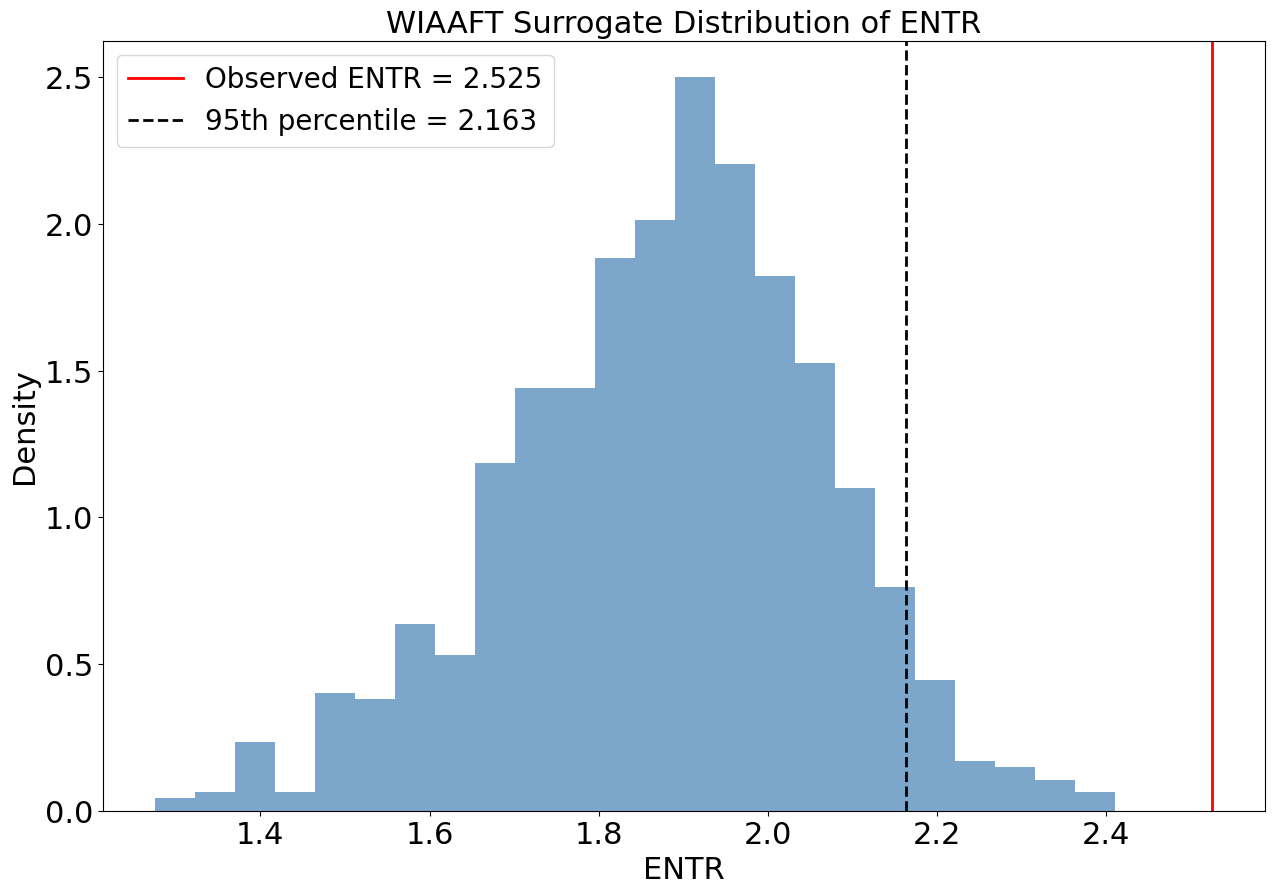

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


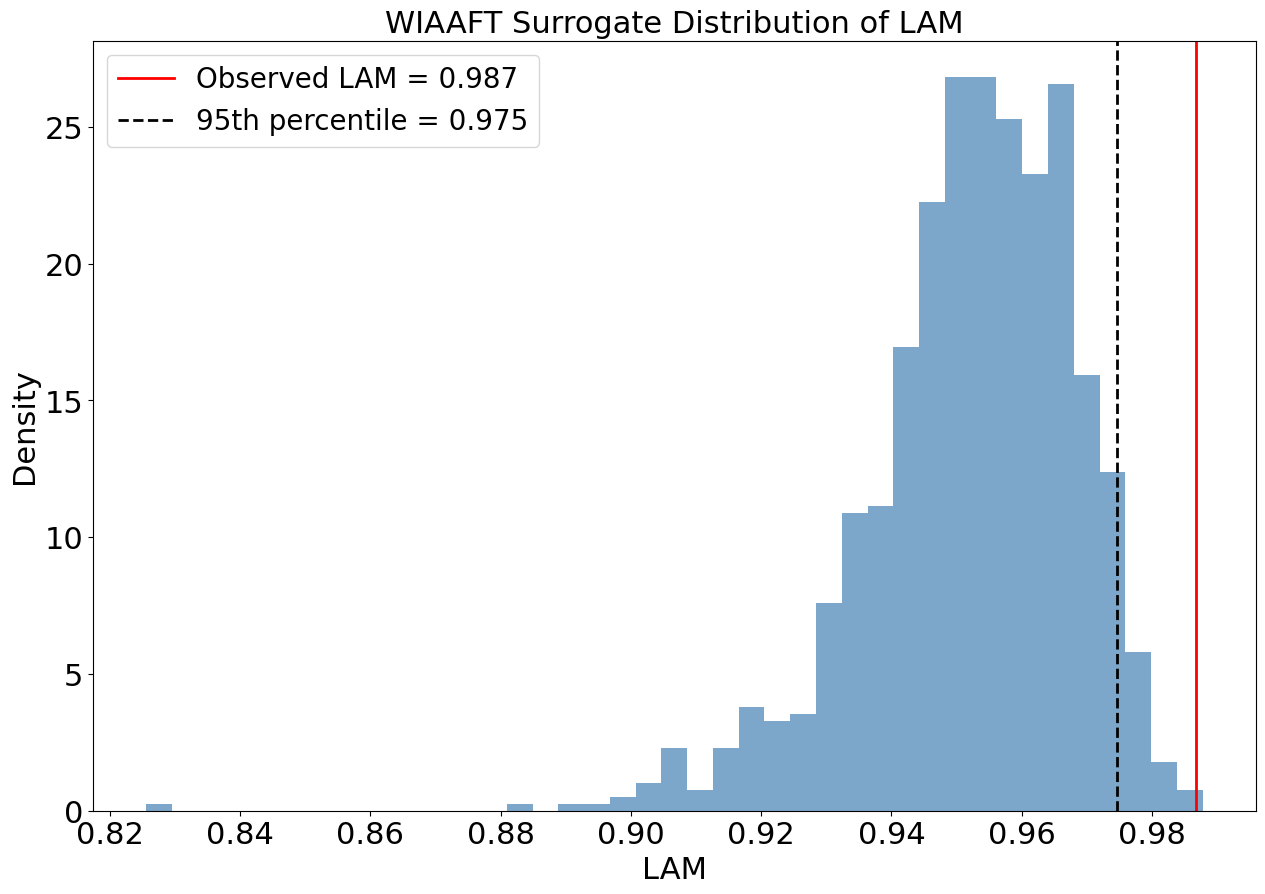

 88%|███████████████████████████████████████▍     | 7/8 [00:43<00:06,  6.91s/it]

RQA  stocks Embedding dimensions:9 
 DET of original:0.962380300954301 
 Recurrence rate: 0.05001259763164525 
Threshold:0.665699999999943 
 Laminarity:0.9867758186366915 
Shannon Entropy:2.5253136633279296 
Rank-order p-value (det):0.002 
Rank-order p-value (lam):0.002 
Rank-order p-value (entr):0.001 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



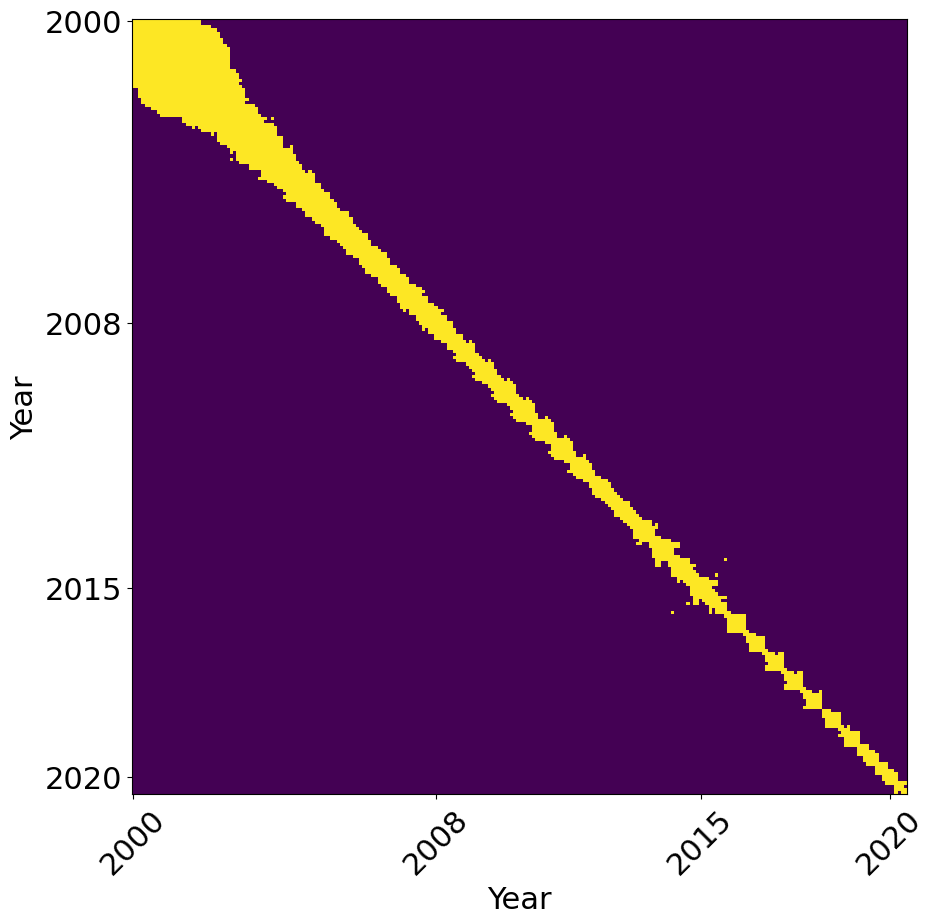

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


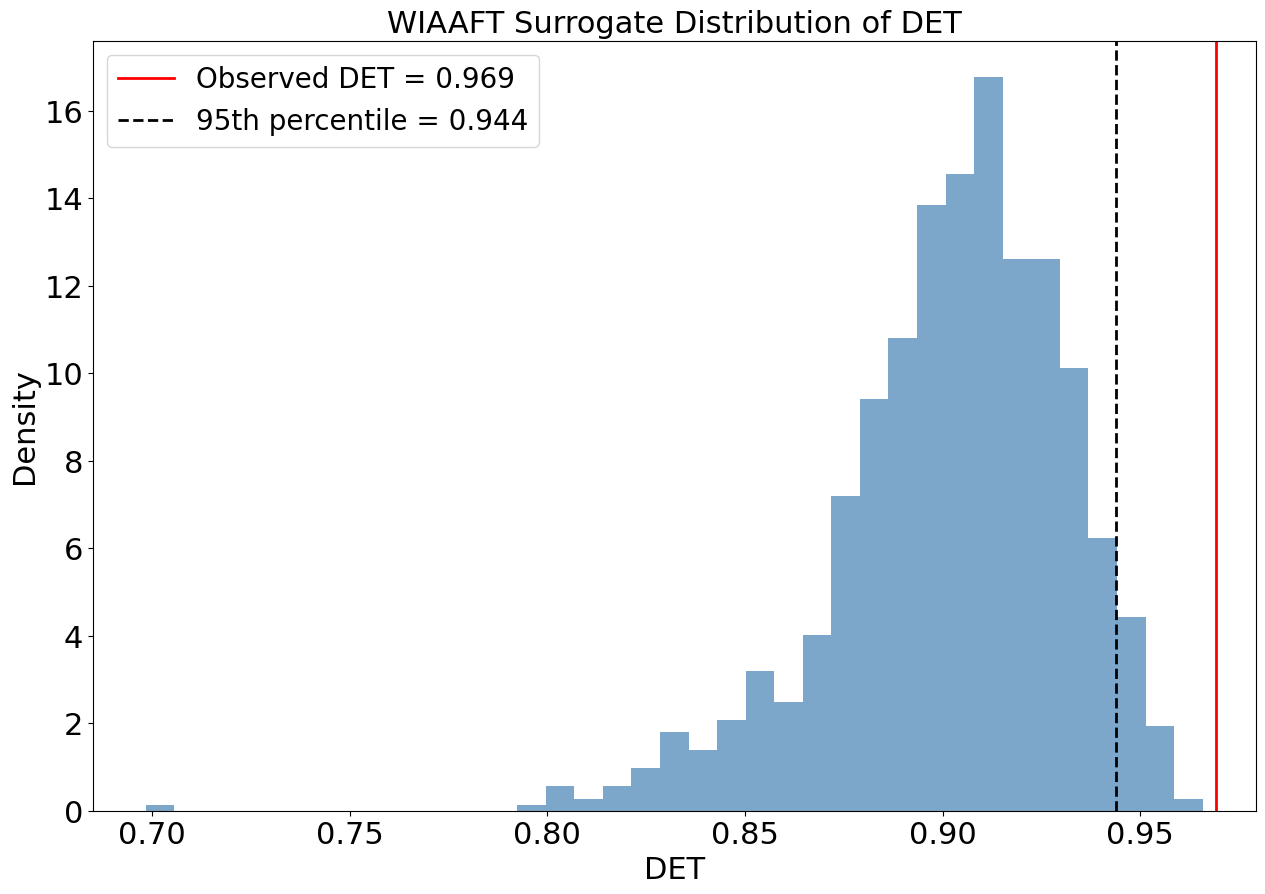

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


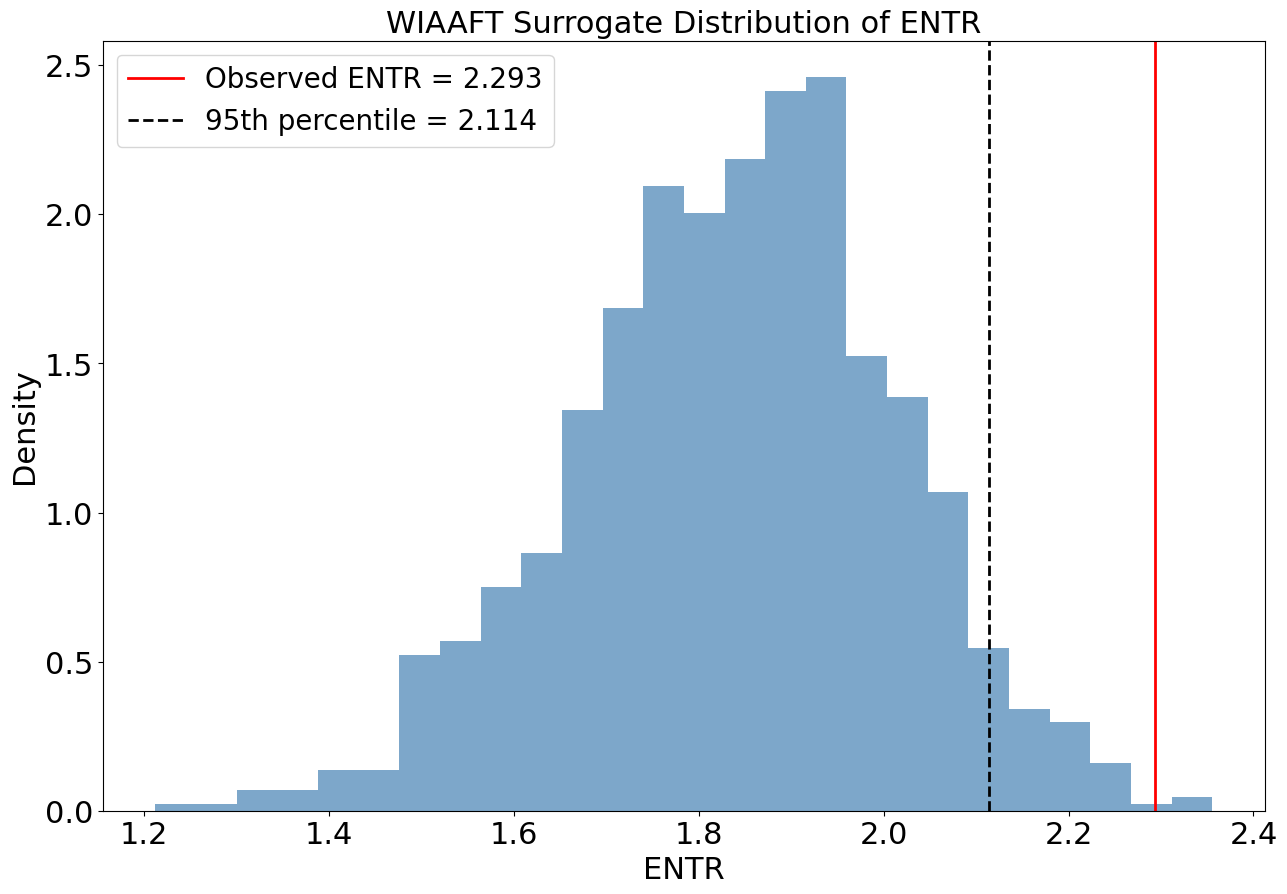

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


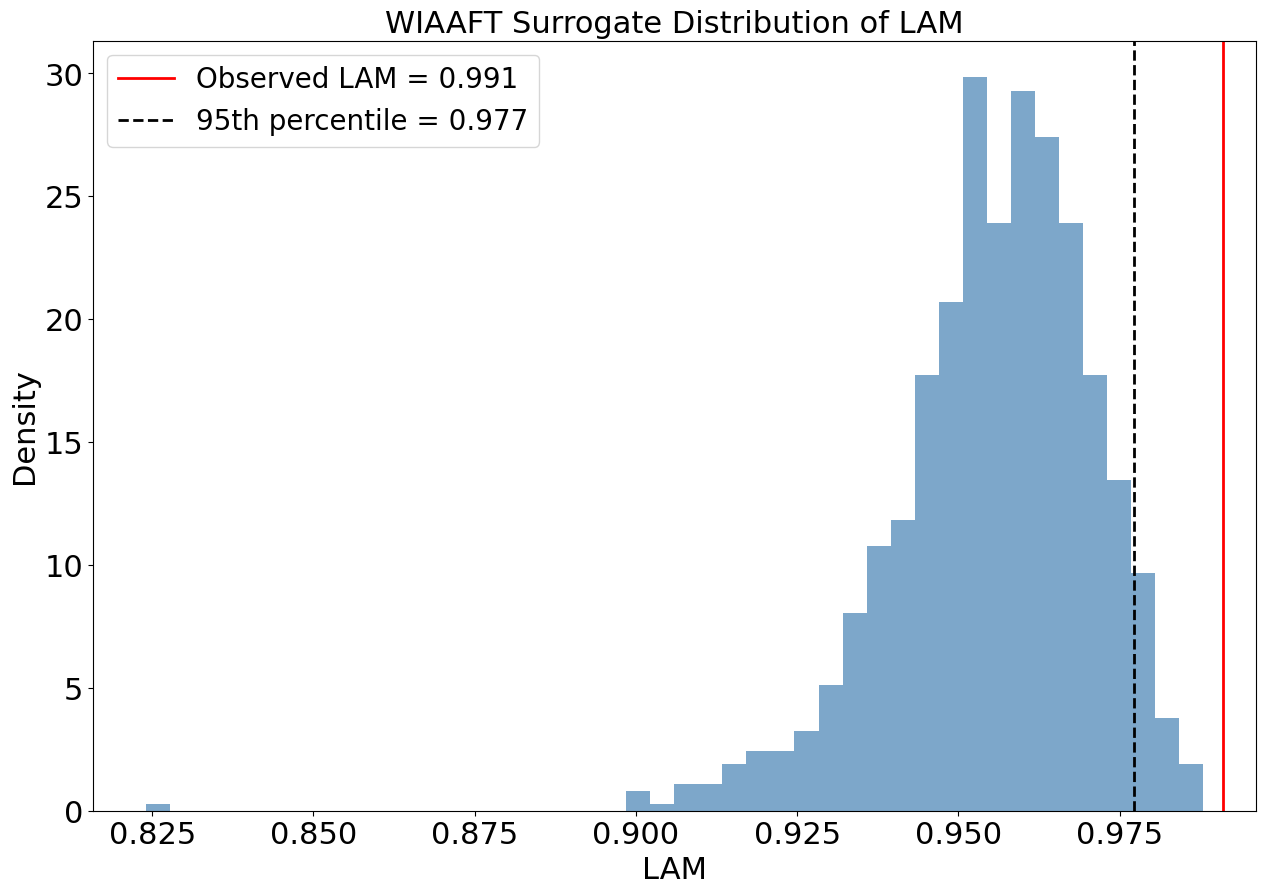

100%|█████████████████████████████████████████████| 8/8 [00:51<00:00,  6.43s/it]

RQA  stocks Embedding dimensions:10 
 DET of original:0.9690647481979531 
 Recurrence rate: 0.05000330491109789 
Threshold:0.7181999999999372 
 Laminarity:0.9910773298050527 
Shannon Entropy:2.2934929304263174 
Rank-order p-value (det):0.001 
Rank-order p-value (lam):0.001 
Rank-order p-value (entr):0.003 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



In [9]:
t_min=6
k="stocks"
det_j=[]
embed=[]
det_surro_ff=[]
kkk=[]
lam_j=[]
ent_j=[]
lam_surro = []
ent_surro=[]
s = lcurve(k)
with open("test_output/stocks_WIAAFT", "w") as f:
    subprocess.run(["julia", "WIAAFT_surrogates.jl", "stocks"], text=True, check=True)
    for dim in tqdm(range(3, 11, 1)):
        tt1=0.001
        dimension=dim
        RR_orig = 0
        while RR_orig < 0.05:
            tt1 = tt1 + 0.0001
            det, RR_orig, lam_orig, entr_orig, matrix= RP_RN(s, dim, tt1)
        det_j.append(det)
        embed.append(dim)
        lam_j.append(lam_orig)
        ent_j.append(entr_orig)

        n = matrix.shape[0]
        
        ticks = [0, 96, 180, 240]

        labels = [
            "2000",
            "2008",
            "2015",
            "2020"
        ]
        
        pylab.matshow(matrix)

        
        pylab.xticks(
            ticks,
            labels,
            rotation=45
        )
        
        pylab.yticks(
            ticks,
            labels
        )
        pylab.gca().xaxis.tick_bottom()
        pylab.xlabel("Year")
        pylab.ylabel("Year")
        
        pylab.savefig(
            f"test_output/WIAAFT/WIAAFT_RP_{dim}.pdf",
            format="pdf",
            dpi=650
        )
        
        pylab.show()

        det_ff, lam_ff, entr_ff = sur_test_WIAAFT(dim, tt1)

        fig1, ax1 = plt.subplots(1)
        qd95 = np.percentile(det_ff, 95)
        ax1.hist(det_ff,bins='auto',density=True,alpha=0.7,color='steelblue')
        ax1.axvline(det,color='red',linewidth=2,label=f'Observed DET = {det:.3f}')
        ax1.axvline(qd95,color='black',linestyle='--',linewidth=2,label=f'95th percentile = {qd95:.3f}')
        ax1.set_xlabel("DET")
        ax1.set_ylabel("Density")
        ax1.set_title("WIAAFT Surrogate Distribution of DET")
        ax1.legend()
        fig1.savefig('test_output/WIAAFT/surro_{}.eps'.format(dim), format="eps", dpi=650)
        plt.show()
        plt.close()

        fig2, ax2 = plt.subplots(1)
        qe95 = np.percentile(entr_ff, 95)
        ax2.hist(entr_ff,bins='auto',density=True,alpha=0.7,color='steelblue')
        ax2.axvline(entr_orig,color='red',linewidth=2,label=f'Observed ENTR = {entr_orig:.3f}')
        ax2.axvline(qe95,color='black',linestyle='--',linewidth=2,label=f'95th percentile = {qe95:.3f}')
        ax2.set_xlabel("ENTR")
        ax2.set_ylabel("Density")
        ax2.set_title("WIAAFT Surrogate Distribution of ENTR")
        ax2.legend()
        fig2.savefig('test_output/WIAAFT/surro_{}_ENTR.eps'.format(dim), format="eps", dpi=650)
        plt.show()
        plt.close()

        fig3, axs3 = plt.subplots(1)
        ql95 = np.percentile(lam_ff, 95)
        axs3.hist(lam_ff,bins='auto',density=True,alpha=0.7,color='steelblue')
        axs3.axvline(lam_orig,color='red',linewidth=2,label=f'Observed LAM = {lam_orig:.3f}')
        axs3.axvline(ql95,color='black',linestyle='--',linewidth=2,label=f'95th percentile = {ql95:.3f}')
        axs3.set_xlabel("LAM")
        axs3.set_ylabel("Density")
        axs3.set_title("WIAAFT Surrogate Distribution of LAM")
        axs3.legend()
        fig3.savefig('test_output/WIAAFT/surro_{}_LAM.eps'.format(dim), format="eps", dpi=650)
        plt.show()
        plt.close()
        
        r = np.sum(det_ff >= det)
        r1 = np.sum(lam_ff >= lam_orig)
        r2 = np.sum(entr_ff >= entr_orig)
        p_rank = (r + 1) / (999 + 1)
        p_rank_lam =(r1 + 1) / (999 + 1)
        p_rank_entr = (r2 + 1) / (999 + 1)
        alpha = 0.05
        reject_null1 = p_rank < alpha
        reject_null2 = p_rank_lam < alpha
        reject_null3 = p_rank_entr < alpha
        f.write("RQA  {} Embedding dimensions:{} \n" 
            " DET of original:{} \n"
            " Recurrence rate: {} \n" 
            "Threshold:{} \n "
            "Laminarity:{} \n" 
            "Shannon Entropy:{} \n" 
            "Rank-order p-value (det):{} \n"
            "Rank-order p-value (lam):{} \n"
            "Rank-order p-value (entr):{} \n" 
            "Reject null (det) hypothesis:{}\n Reject null (lam) hypothesis:{}\n"
            "Reject null (entr) hypothesis:{}\n \n \n".format(k, dim, det, RR_orig, tt1, lam_orig, entr_orig, 
                                                              p_rank, p_rank_lam, p_rank_entr, reject_null1, reject_null2, 
                                                              reject_null3))
        print("RQA  {} Embedding dimensions:{} \n" 
            " DET of original:{} \n"
            " Recurrence rate: {} \n" 
            "Threshold:{} \n "
            "Laminarity:{} \n" 
            "Shannon Entropy:{} \n" 
            "Rank-order p-value (det):{} \n"
            "Rank-order p-value (lam):{} \n"
            "Rank-order p-value (entr):{} \n" 
            "Reject null (det) hypothesis:{}\n Reject null (lam) hypothesis:{}\n"
            "Reject null (entr) hypothesis:{}\n \n \n".format(k, dim, det, RR_orig, tt1, lam_orig, entr_orig, 
                                                              p_rank, p_rank_lam, p_rank_entr, reject_null1, reject_null2, 
                                                              reject_null3))
        det_surro_ff.append(det_ff)
        kkk.append(np.full(999, dimension))
        lam_surro.append(lam_ff)
        ent_surro.append(entr_ff)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


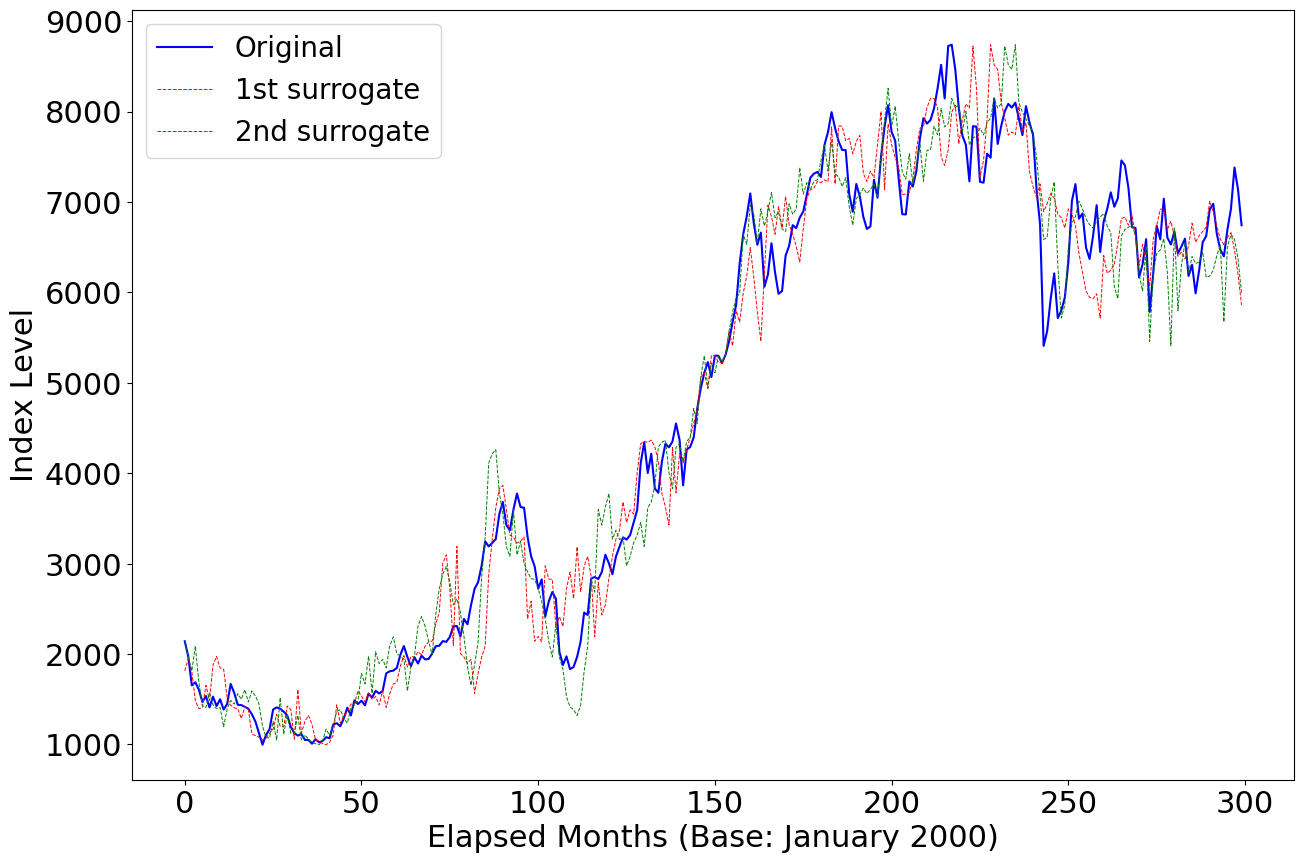

In [10]:
surro1 = np.loadtxt("surro_index/WIAAFT/qp_surr_001")
surro2 = np.loadtxt("surro_index/WIAAFT/qp_surr_002")
surro3 = np.loadtxt("surro_index/WIAAFT/qp_surr_003")
f1, ax1 = plt.subplots(1)
ax1.plot(data,linewidth=1.5,label = 'Original', color="blue")
ax1.plot(surro1, "r--",linewidth=0.7,label = '1st surrogate')
ax1.plot(surro2, "g--",linewidth=0.7, label = '2nd surrogate')
plt.xlabel("Elapsed Months (Base: January 2000)")
plt.legend()
plt.ylabel("Index Level")
f1.savefig('test_output/wiaaft_surrogates_index.eps', format="eps", dpi=650)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


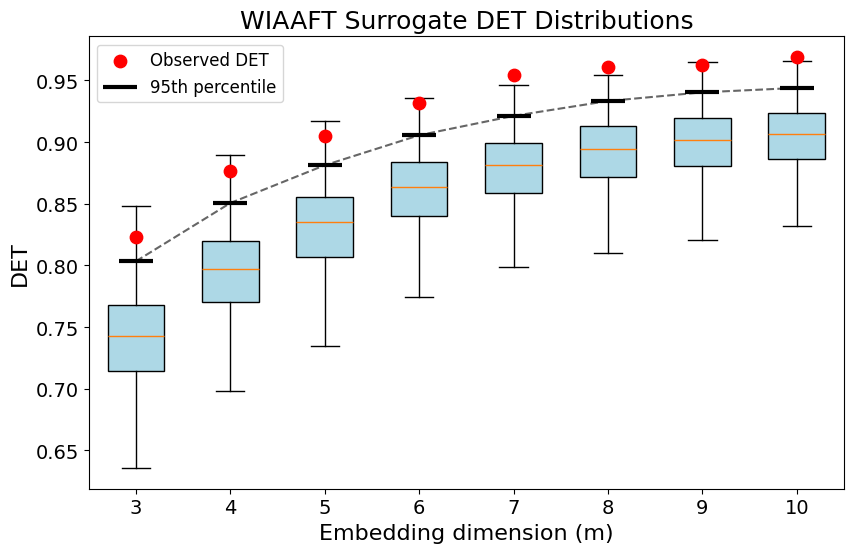

In [10]:

fig, ax = plt.subplots(1)

# Use actual embedding dimensions
dims = embed    # e.g. [3,4,5,6,7,8,9,10,11,12]

# Boxplots of surrogate DET distributions
bp = ax.boxplot(
    det_surro_ff,
    positions=dims,
    widths=0.6,
    patch_artist=True,
    showfliers=False
)

for box in bp['boxes']:
    box.set(
        facecolor='lightblue',
        edgecolor='black'
    )

# Observed DET values
ax.scatter(
    dims,
    det_j,
    color='red',
    s=80,
    zorder=10,
    label='Observed DET'
)

# 95th percentile of surrogate distributions
q95 = [
    np.percentile(x, 95)
    for x in det_surro_ff
]

ax.scatter(
    dims,
    q95,
    color='black',
    marker='_',
    s=600,
    linewidths=3,
    zorder=11,
    label='95th percentile'
)

# Connect the 95th percentiles
ax.plot(
    dims,
    q95,
    'k--',
    alpha=0.6
)

ax.set_xticks(dims)

ax.set_xlabel(
    "Embedding dimension (m)",
    fontsize=16
)

ax.set_ylabel(
    "DET",
    fontsize=16
)

ax.set_title(
    "WIAAFT Surrogate DET Distributions",
    fontsize=18
)

ax.tick_params(
    axis='both',
    labelsize=14
)

ax.legend(fontsize=12)

plt.tight_layout()

fig.savefig(
    "test_output/WIAAFT/WIAAFT_surro_m.eps",
    format="eps",
    dpi=650,
    bbox_inches="tight"
)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


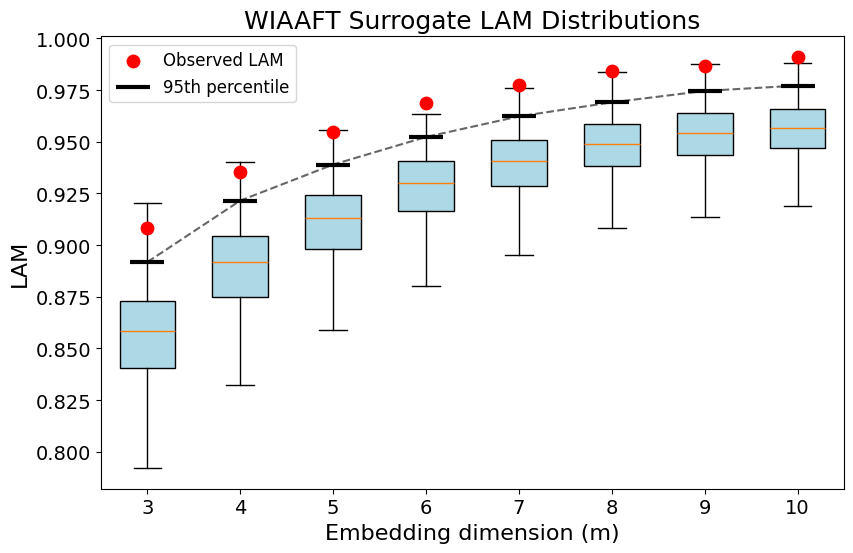

In [11]:

fig, ax = plt.subplots(1)

# Use actual embedding dimensions
dims = embed    # e.g. [3,4,5,6,7,8,9,10,11,12]

# Boxplots of surrogate DET distributions
bp = ax.boxplot(
    lam_surro,
    positions=dims,
    widths=0.6,
    patch_artist=True,
    showfliers=False
)

for box in bp['boxes']:
    box.set(
        facecolor='lightblue',
        edgecolor='black'
    )

# Observed DET values
ax.scatter(
    dims,
    lam_j,
    color='red',
    s=80,
    zorder=10,
    label='Observed LAM'
)

# 95th percentile of surrogate distributions
ql95 = [
    np.percentile(x, 95)
    for x in lam_surro
]

ax.scatter(
    dims,
    ql95,
    color='black',
    marker='_',
    s=600,
    linewidths=3,
    zorder=11,
    label='95th percentile'
)

# Connect the 95th percentiles
ax.plot(
    dims,
    ql95,
    'k--',
    alpha=0.6
)

ax.set_xticks(dims)

ax.set_xlabel(
    "Embedding dimension (m)",
    fontsize=16
)

ax.set_ylabel(
    "LAM",
    fontsize=16
)

ax.set_title(
    "WIAAFT Surrogate LAM Distributions",
    fontsize=18
)

ax.tick_params(
    axis='both',
    labelsize=14
)

ax.legend(fontsize=12)

plt.tight_layout()

fig.savefig(
    "test_output/WIAAFT/WIAAFT_surro_lam_m.eps",
    format="eps",
    dpi=650,
    bbox_inches="tight"
)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


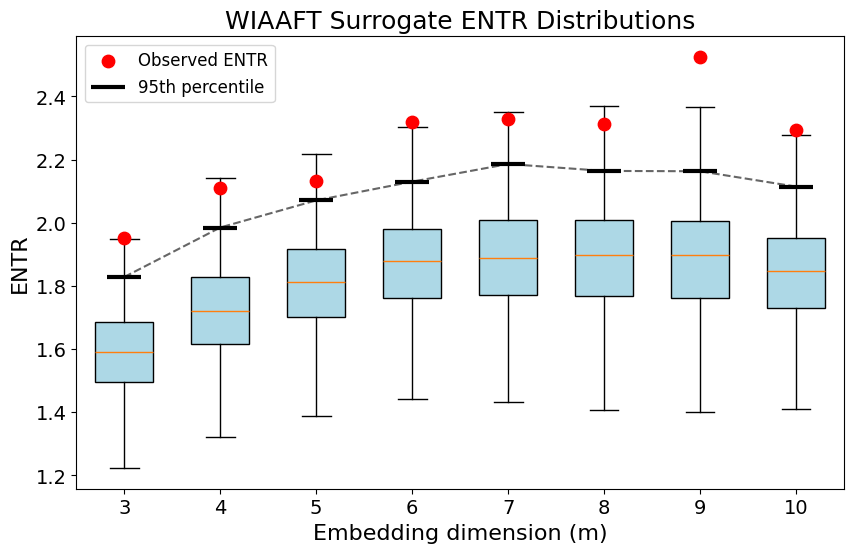

In [12]:

fig, ax = plt.subplots(1)

# Use actual embedding dimensions
dims = embed    # e.g. [3,4,5,6,7,8,9,10,11,12]

# Boxplots of surrogate DET distributions
bp = ax.boxplot(
    ent_surro,
    positions=dims,
    widths=0.6,
    patch_artist=True,
    showfliers=False
)

for box in bp['boxes']:
    box.set(
        facecolor='lightblue',
        edgecolor='black'
    )

# Observed DET values
ax.scatter(
    dims,
    ent_j,
    color='red',
    s=80,
    zorder=10,
    label='Observed ENTR'
)

# 95th percentile of surrogate distributions
qe95 = [
    np.percentile(x, 95)
    for x in ent_surro
]

ax.scatter(
    dims,
    qe95,
    color='black',
    marker='_',
    s=600,
    linewidths=3,
    zorder=11,
    label='95th percentile'
)

# Connect the 95th percentiles
ax.plot(
    dims,
    qe95,
    'k--',
    alpha=0.6
)

ax.set_xticks(dims)

ax.set_xlabel(
    "Embedding dimension (m)",
    fontsize=16
)

ax.set_ylabel(
    "ENTR",
    fontsize=16
)

ax.set_title(
    "WIAAFT Surrogate ENTR Distributions",
    fontsize=18
)

ax.tick_params(
    axis='both',
    labelsize=14
)

ax.legend(fontsize=12)

plt.tight_layout()

fig.savefig(
    "test_output/WIAAFT/WIAAFT_surro_entr_m.eps",
    format="eps",
    dpi=650,
    bbox_inches="tight"
)

plt.show()

# PP surrogate test

In [9]:
def sur_test_PP(m, thr):
    return open_file("surro_index/PP/qp_surr", m, thr)

  0%|                                                     | 0/8 [00:00<?, ?it/s]

Mean Nearest Neighbor Distance: 0.0873456421356951
Pseudo-periodic surrogates generated successfullly


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


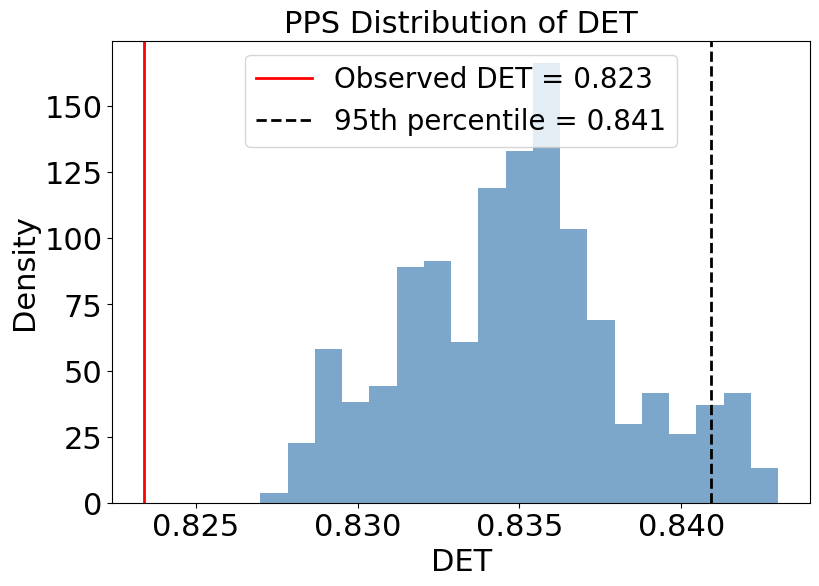

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


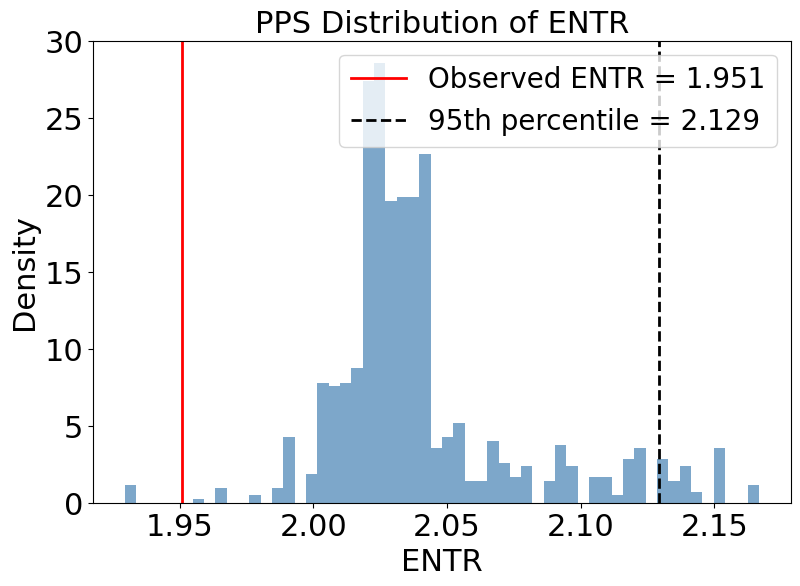

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


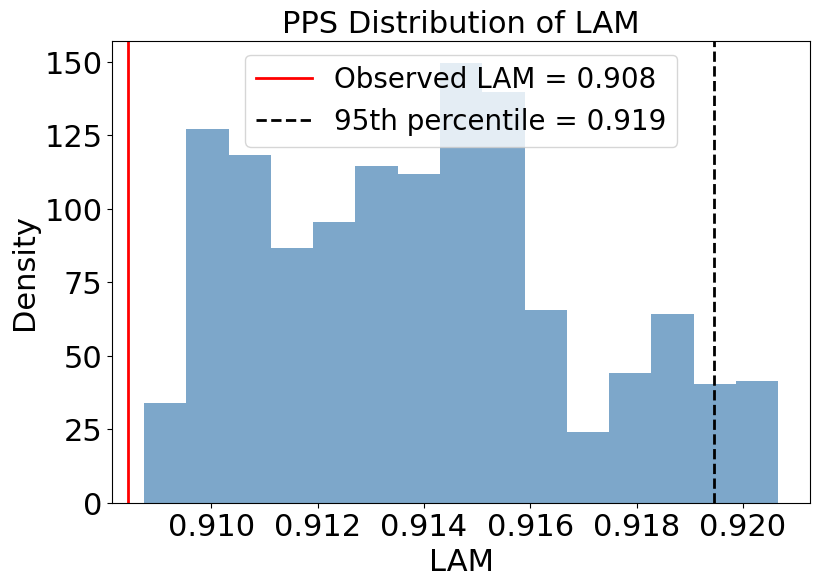

 12%|█████▋                                       | 1/8 [00:08<00:57,  8.22s/it]

RQA  stocks Embedding dimensions:3 
 DET of original:0.8234075608471688 
 Recurrence rate: 0.050033757716049385 
Threshold:0.23889999999999 
 Laminarity:0.9084337349375701 
Shannon Entropy:1.9508420715265373 
Rank-order p-value (det):0.002 
Rank-order p-value (lam):0.002 
Rank-order p-value (entr):0.012 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 

Mean Nearest Neighbor Distance: 0.12535602890065076
Pseudo-periodic surrogates generated successfullly


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


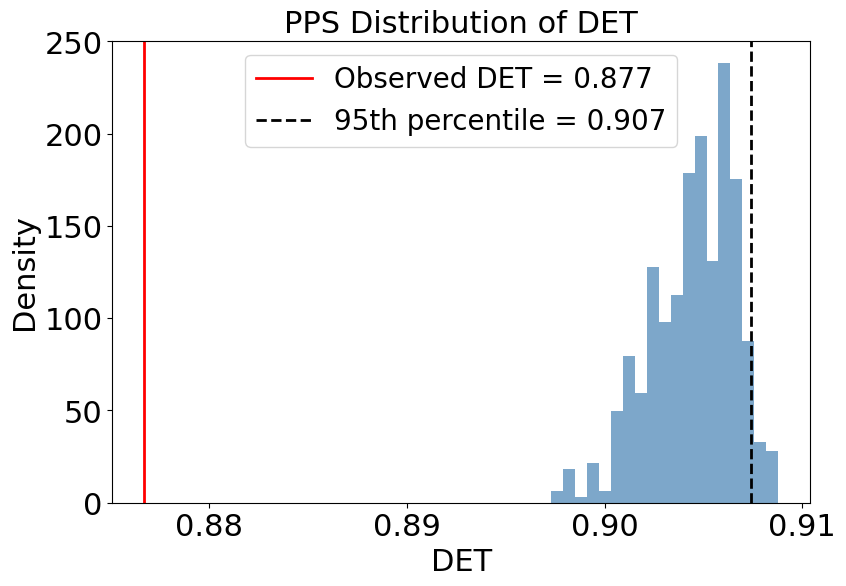

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


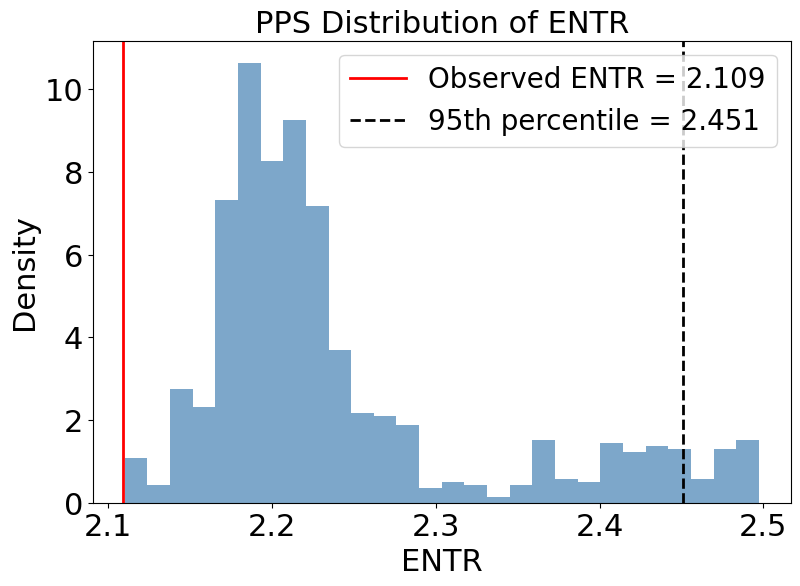

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


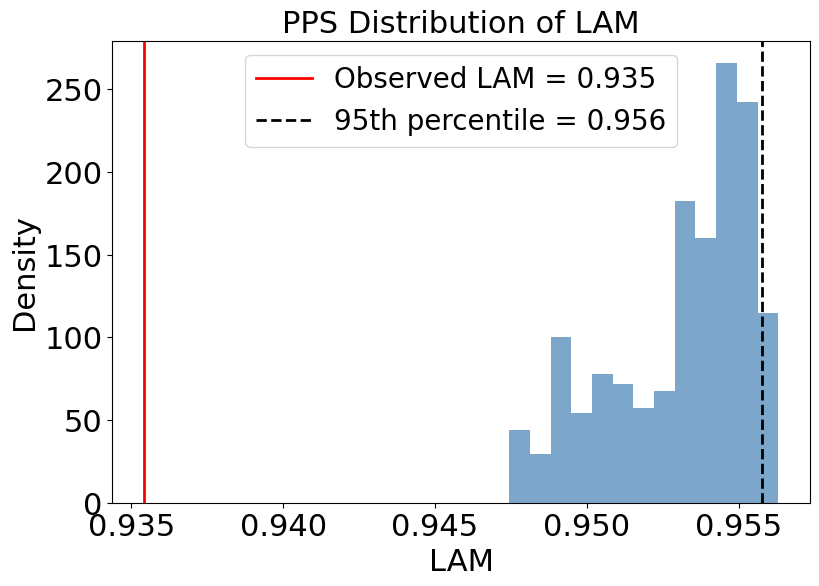

 25%|███████████▎                                 | 2/8 [00:17<00:51,  8.64s/it]

RQA  stocks Embedding dimensions:4 
 DET of original:0.876690102755877 
 Recurrence rate: 0.050047784316684274 
Threshold:0.3259999999999804 
 Laminarity:0.9354271356760416 
Shannon Entropy:2.1089753584358295 
Rank-order p-value (det):0.002 
Rank-order p-value (lam):0.002 
Rank-order p-value (entr):0.002 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 

Mean Nearest Neighbor Distance: 0.1548192544025659
Pseudo-periodic surrogates generated successfullly


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


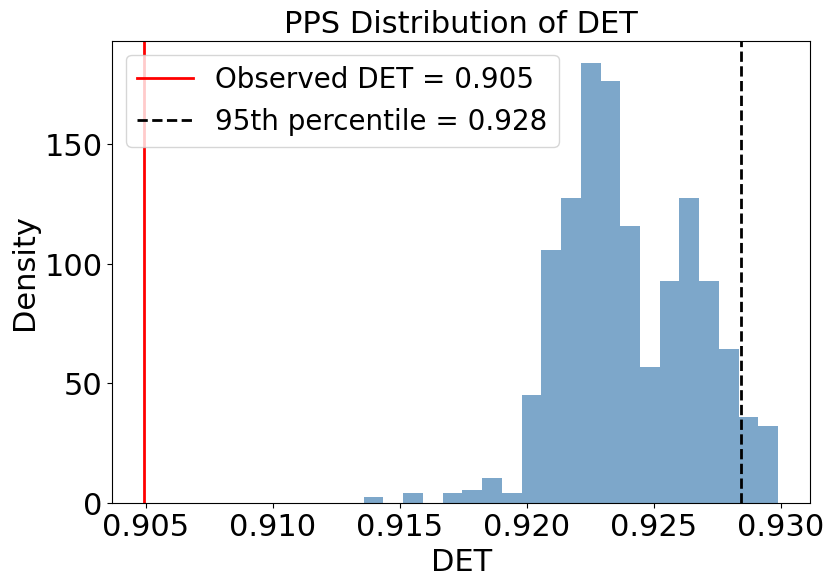

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


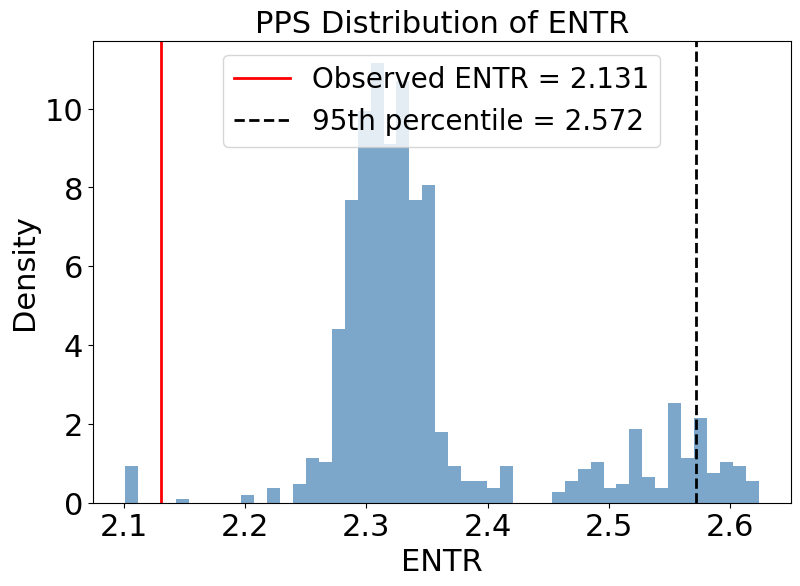

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


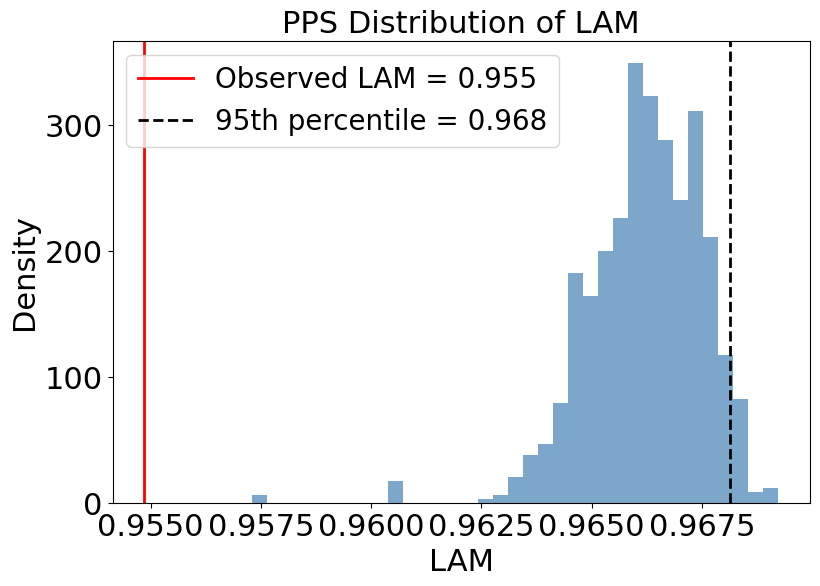

 38%|████████████████▉                            | 3/8 [00:26<00:45,  9.02s/it]

RQA  stocks Embedding dimensions:5 
 DET of original:0.9049235993183222 
 Recurrence rate: 0.050015752993068686 
Threshold:0.40469999999997175 
 Laminarity:0.9548556430421132 
Shannon Entropy:2.1310423583923637 
Rank-order p-value (det):0.002 
Rank-order p-value (lam):0.002 
Rank-order p-value (entr):0.022 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 

Mean Nearest Neighbor Distance: 0.17740384209547802
Pseudo-periodic surrogates generated successfullly


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


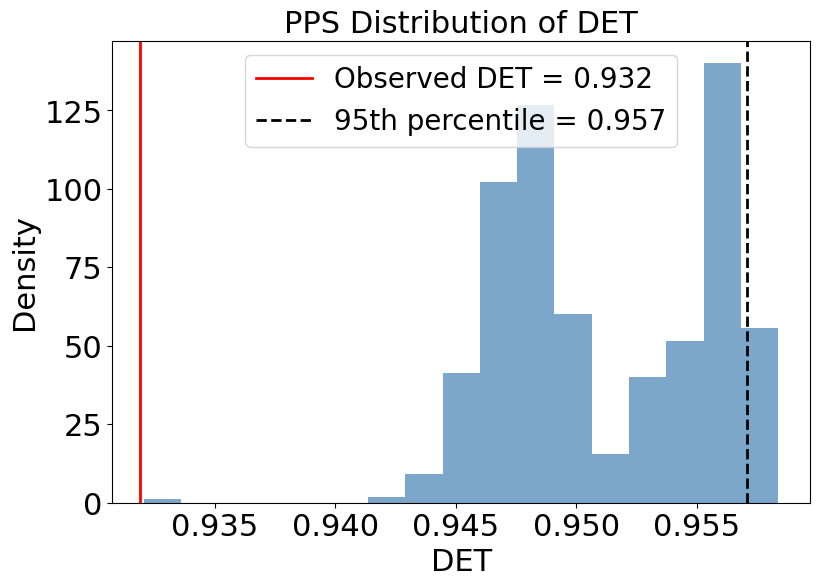

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


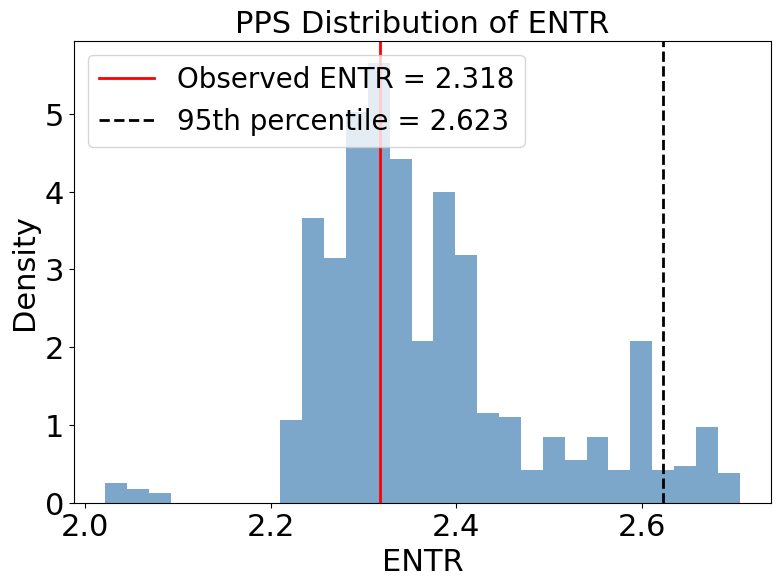

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


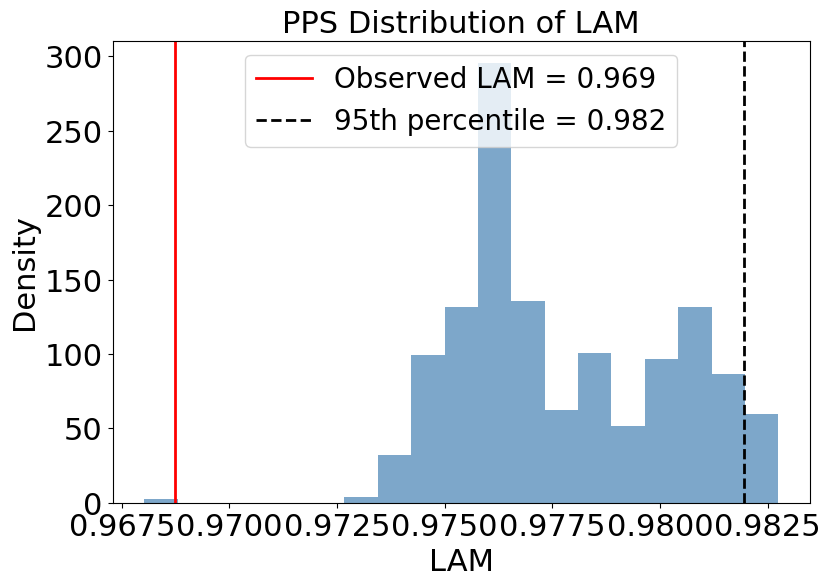

 50%|██████████████████████▌                      | 4/8 [00:36<00:37,  9.37s/it]

RQA  stocks Embedding dimensions:6 
 DET of original:0.9318720379119317 
 Recurrence rate: 0.05001371742112483 
Threshold:0.48369999999996305 
 Laminarity:0.9687328579238379 
Shannon Entropy:2.318085964176623 
Rank-order p-value (det):0.002 
Rank-order p-value (lam):0.006 
Rank-order p-value (entr):0.836 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:False
 
 

Mean Nearest Neighbor Distance: 0.19750768284721318
Pseudo-periodic surrogates generated successfullly


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


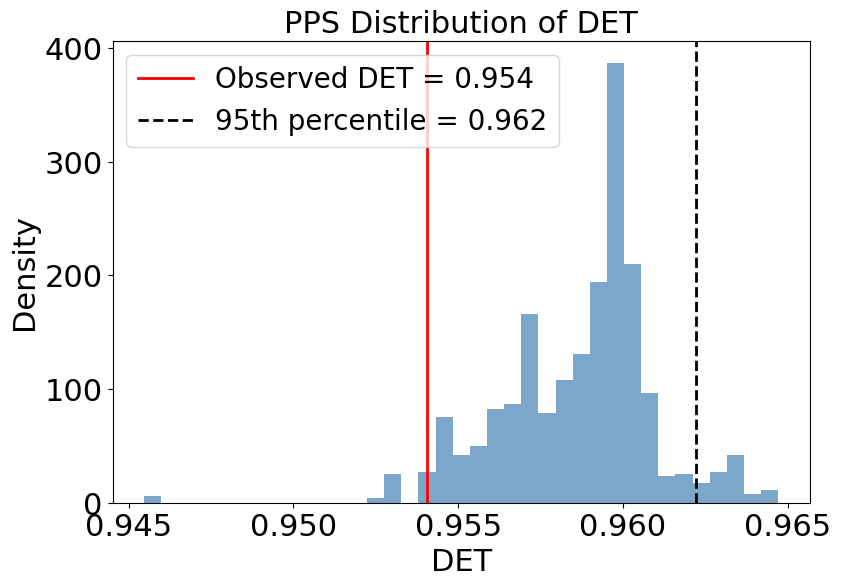

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


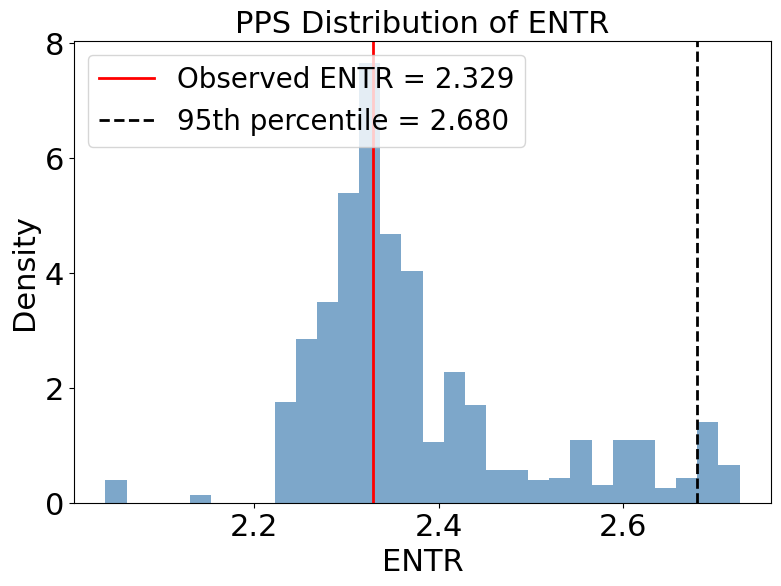

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


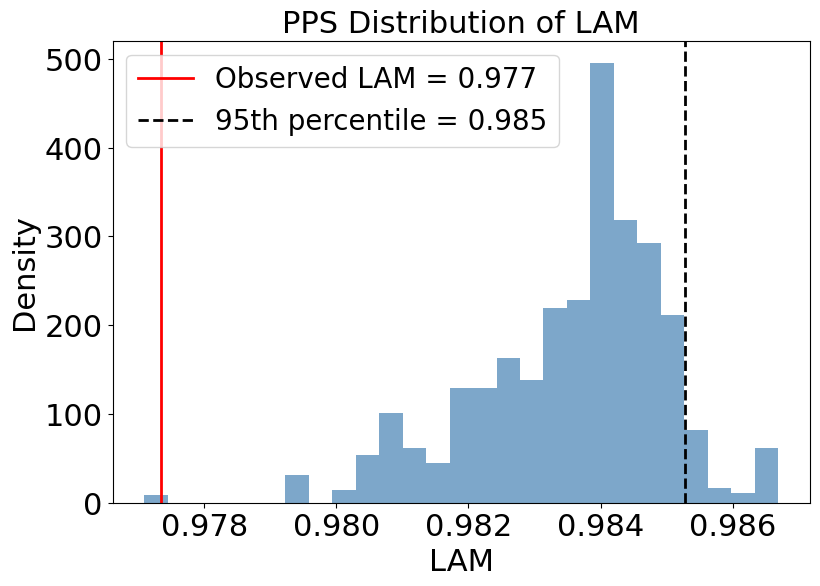

 62%|████████████████████████████▏                | 5/8 [00:47<00:29,  9.82s/it]

RQA  stocks Embedding dimensions:7 
 DET of original:0.9540657976382556 
 Recurrence rate: 0.050017217630854 
Threshold:0.5500999999999557 
 Laminarity:0.9773379231182521 
Shannon Entropy:2.328730875911501 
Rank-order p-value (det):0.062 
Rank-order p-value (lam):0.008 
Rank-order p-value (entr):0.87 
Reject null (det) hypothesis:False
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:False
 
 

Mean Nearest Neighbor Distance: 0.21624354848394695
Pseudo-periodic surrogates generated successfullly


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


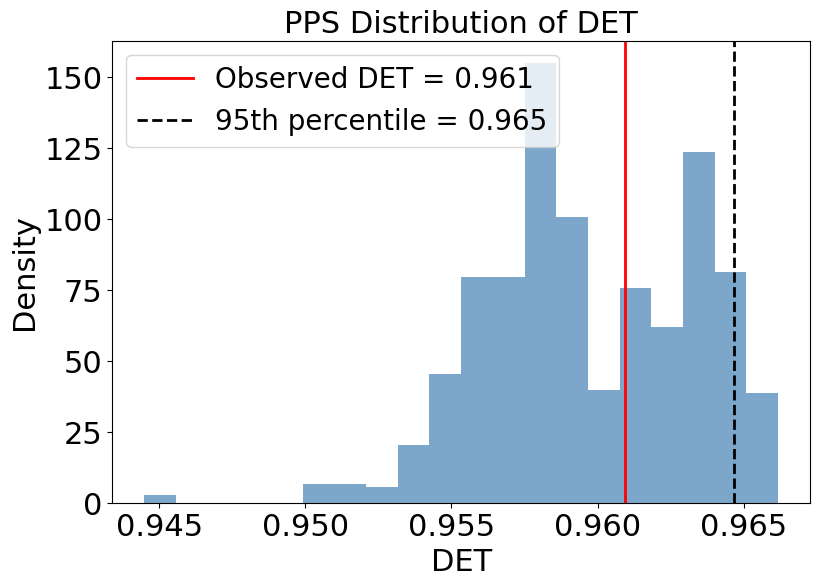

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


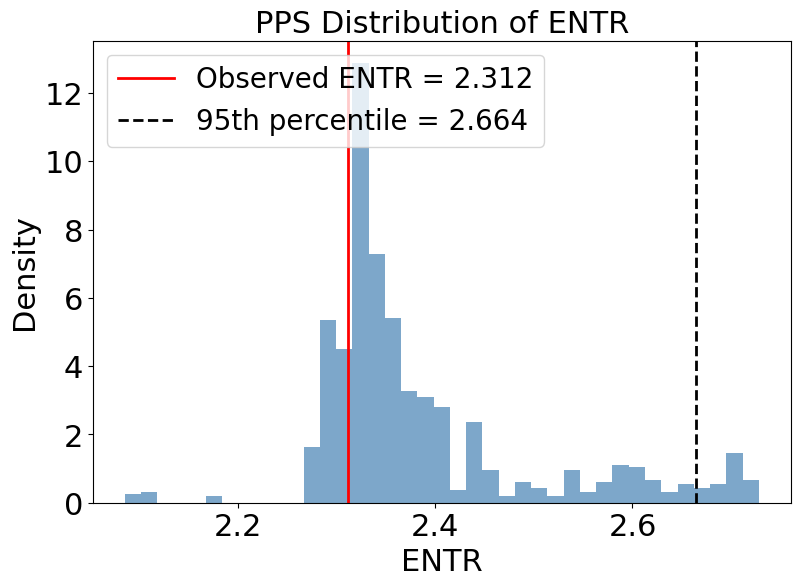

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


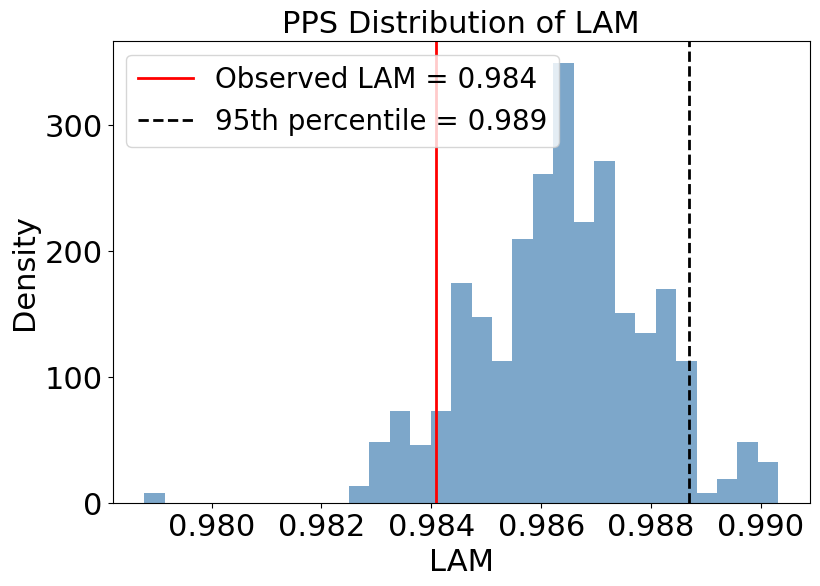

 75%|█████████████████████████████████▊           | 6/8 [00:58<00:20, 10.49s/it]

RQA  stocks Embedding dimensions:8 
 DET of original:0.960937499996872 
 Recurrence rate: 0.050027041644131964 
Threshold:0.6095999999999492 
 Laminarity:0.9840840840811289 
Shannon Entropy:2.312170199777547 
Rank-order p-value (det):0.814 
Rank-order p-value (lam):0.166 
Rank-order p-value (entr):0.356 
Reject null (det) hypothesis:False
 Reject null (lam) hypothesis:False
Reject null (entr) hypothesis:False
 
 

Mean Nearest Neighbor Distance: 0.2327783504019606
Pseudo-periodic surrogates generated successfullly


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


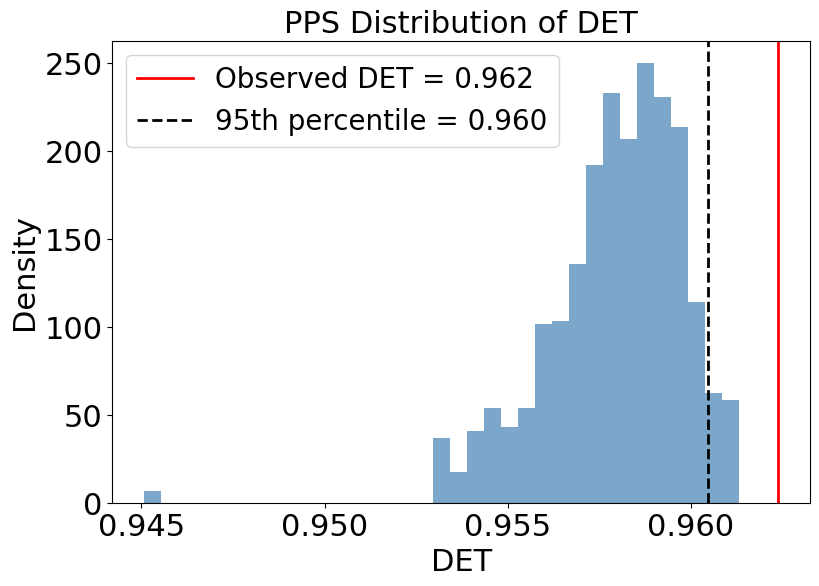

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


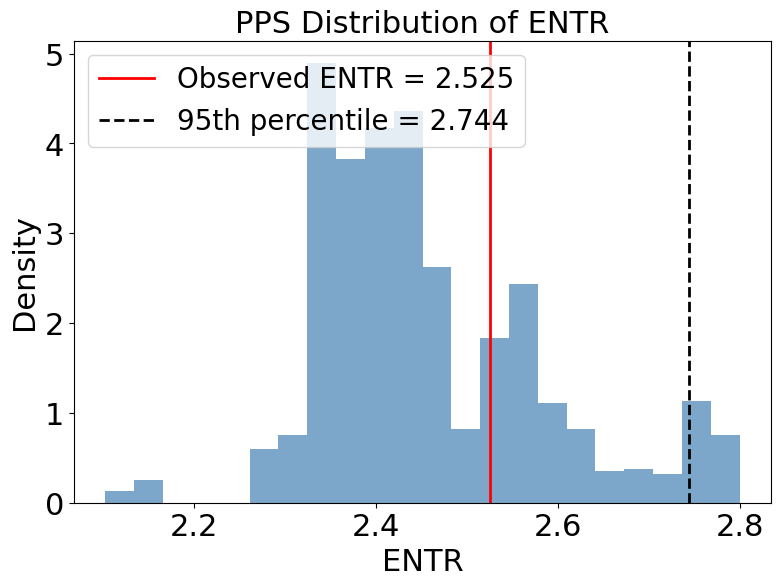

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


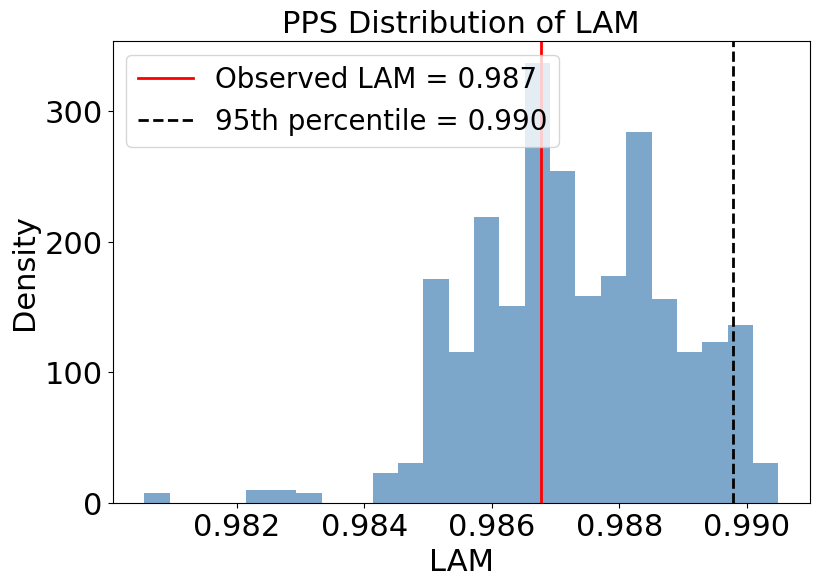

 88%|███████████████████████████████████████▍     | 7/8 [01:11<00:11, 11.08s/it]

RQA  stocks Embedding dimensions:9 
 DET of original:0.962380300954301 
 Recurrence rate: 0.05001259763164525 
Threshold:0.665699999999943 
 Laminarity:0.9867758186366915 
Shannon Entropy:2.5253136633279296 
Rank-order p-value (det):0.002 
Rank-order p-value (lam):0.794 
Rank-order p-value (entr):0.532 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:False
Reject null (entr) hypothesis:False
 
 

Mean Nearest Neighbor Distance: 0.24846023140960372
Pseudo-periodic surrogates generated successfullly


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


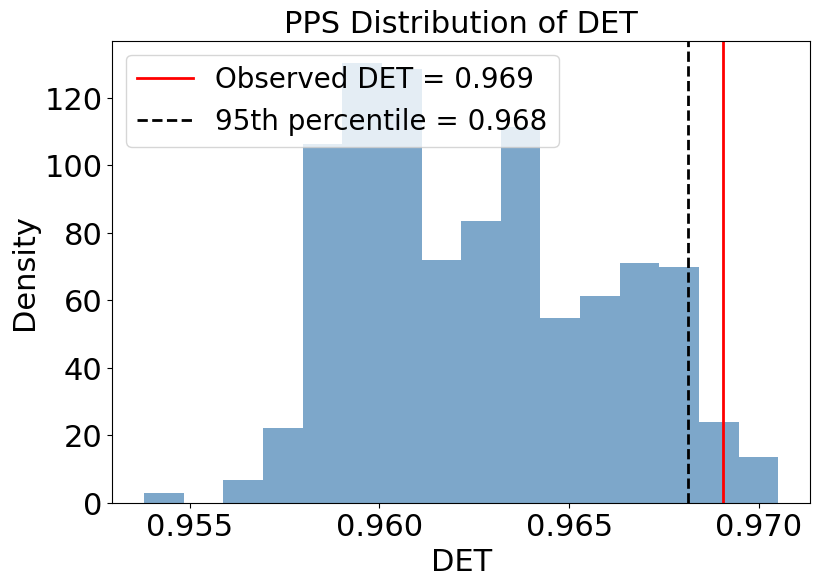

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


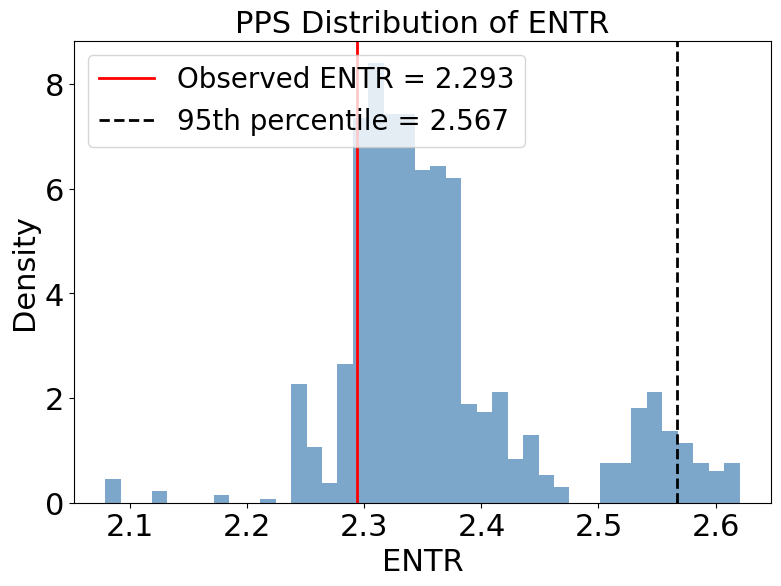

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


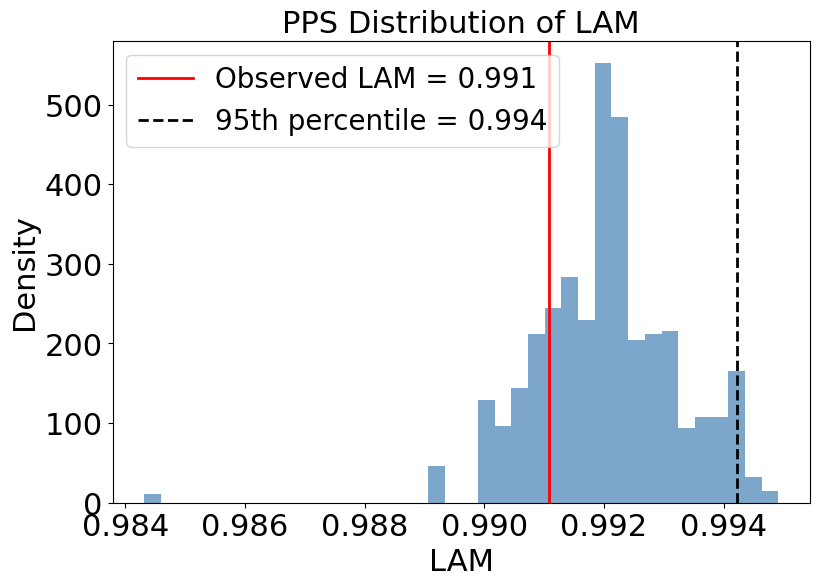

100%|█████████████████████████████████████████████| 8/8 [01:23<00:00, 10.41s/it]

RQA  stocks Embedding dimensions:10 
 DET of original:0.9690647481979531 
 Recurrence rate: 0.05000330491109789 
Threshold:0.7181999999999372 
 Laminarity:0.9910773298050527 
Shannon Entropy:2.2934929304263174 
Rank-order p-value (det):0.048 
Rank-order p-value (lam):0.376 
Rank-order p-value (entr):0.236 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:False
Reject null (entr) hypothesis:False
 
 



In [13]:
t_min=6
coeff = 0.9 #change this if you use 0.7
k="stocks"
det_j=[]
embed=[]
det_surro_ff=[]
kkk=[]
lam_j=[]
ent_j=[]
lam_surro = []
ent_surro=[]
s = lcurve(k)
with open("test_output/stocks_PP", "w") as f:
    for dim in tqdm(range(3, 11, 1)):
        tt1=0.001
        dimension=dim
        RR_orig = 0
        while RR_orig < 0.05:
            tt1 = tt1 + 0.0001
            det, RR_orig, lam_orig, entr_orig, matrix= RP_RN(s, dim, tt1)
        orig_rp=RecurrencePlot(s, dim=dimension , tau=t_min, metric = "euclidean", threshold=tt1, normalize=True, silence_level = 3)
        det_j.append(det)
        embed.append(dim)
        lam_j.append(lam_orig)
        ent_j.append(entr_orig)
        dist_matrix = orig_rp.euclidean_distance_matrix()
        np.fill_diagonal(dist_matrix, np.inf)
        nearest_neighbor_distances = np.min(dist_matrix, axis=1)
        mean_nn_distance = np.mean(nearest_neighbor_distances)
        print(f"Mean Nearest Neighbor Distance: {mean_nn_distance}")
        noise_rad = coeff*mean_nn_distance
        subprocess.run(["julia", "PP.jl", str(noise_rad), str(dim), str(t_min), "stocks"], text=True, check=True)
        det_ff, lam_ff, entr_ff = sur_test_PP( dim, tt1)

        fig1, ax1 = plt.subplots(1)
        qd95 = np.percentile(det_ff, 95)
        ax1.hist(det_ff,bins='auto',density=True,alpha=0.7,color='steelblue')
        ax1.axvline(det,color='red',linewidth=2,label=f'Observed DET = {det:.3f}')
        ax1.axvline(qd95,color='black',linestyle='--',linewidth=2,label=f'95th percentile = {qd95:.3f}')
        ax1.set_xlabel("DET")
        ax1.set_ylabel("Density")
        ax1.set_title("PPS Distribution of DET")
        ax1.legend()
        fig1.savefig('test_output/PP/PP_surro_{}.eps'.format(dim), format="eps", dpi=650)
        plt.show()
        plt.close()

        fig2, ax2 = plt.subplots(1)
        qe95 = np.percentile(entr_ff, 95)
        ax2.hist(entr_ff,bins='auto',density=True,alpha=0.7,color='steelblue')
        ax2.axvline(entr_orig,color='red',linewidth=2,label=f'Observed ENTR = {entr_orig:.3f}')
        ax2.axvline(qe95,color='black',linestyle='--',linewidth=2,label=f'95th percentile = {qe95:.3f}')
        ax2.set_xlabel("ENTR")
        ax2.set_ylabel("Density")
        ax2.set_title("PPS Distribution of ENTR")
        ax2.legend()
        fig2.savefig('test_output/PP/PP_surro_{}_ENTR.eps'.format(dim), format="eps", dpi=650)
        plt.show()
        plt.close()

        fig3, axs3 = plt.subplots(1)
        ql95 = np.percentile(lam_ff, 95)
        axs3.hist(lam_ff,bins='auto',density=True,alpha=0.7,color='steelblue')
        axs3.axvline(lam_orig,color='red',linewidth=2,label=f'Observed LAM = {lam_orig:.3f}')
        axs3.axvline(ql95,color='black',linestyle='--',linewidth=2,label=f'95th percentile = {ql95:.3f}')
        axs3.set_xlabel("LAM")
        axs3.set_ylabel("Density")
        axs3.set_title("PPS Distribution of LAM")
        axs3.legend()
        fig3.savefig('test_output/PP/PP_surro_{}_LAM.eps'.format(dim), format="eps", dpi=650)
        plt.show()
        plt.close()
        


        r_up = np.sum(det_ff >= det)
        r1_up = np.sum(lam_ff >= lam_orig)
        r2_up = np.sum(entr_ff >= entr_orig)
        r_down = np.sum(det_ff <= det)
        r1_down = np.sum(lam_ff <= lam_orig)
        r2_down = np.sum(entr_ff <= entr_orig)
        p_rank = min(1, 2.0 * ((min(r_up, r_down) + 1) / (999 + 1)))
        p_rank_lam = min(1, 2.0 * ((min(r1_up, r1_down) + 1) / (999 + 1)))
        p_rank_entr = min(1, 2.0 * ((min(r2_up, r2_down) + 1) / (999 + 1)))
        alpha = 0.05
        reject_null1 = p_rank < alpha
        reject_null2 = p_rank_lam < alpha
        reject_null3 = p_rank_entr < alpha
        f.write("RQA  {} Embedding dimensions:{} \n" 
            " DET of original:{} \n"
            " Recurrence rate: {} \n" 
            "Threshold:{} \n "
            "Laminarity:{} \n" 
            "Shannon Entropy:{} \n" 
            "Rank-order p-value (det):{} \n"
            "Rank-order p-value (lam):{} \n"
            "Rank-order p-value (entr):{} \n" 
            "Reject null (det) hypothesis:{}\n Reject null (lam) hypothesis:{}\n"
            "Reject null (entr) hypothesis:{}\n \n \n".format(k, dim, det, RR_orig, tt1, lam_orig, entr_orig, 
                                                              p_rank, p_rank_lam, p_rank_entr, reject_null1, reject_null2, 
                                                              reject_null3))
        print("RQA  {} Embedding dimensions:{} \n" 
            " DET of original:{} \n"
            " Recurrence rate: {} \n" 
            "Threshold:{} \n "
            "Laminarity:{} \n" 
            "Shannon Entropy:{} \n" 
            "Rank-order p-value (det):{} \n"
            "Rank-order p-value (lam):{} \n"
            "Rank-order p-value (entr):{} \n" 
            "Reject null (det) hypothesis:{}\n Reject null (lam) hypothesis:{}\n"
            "Reject null (entr) hypothesis:{}\n \n \n".format(k, dim, det, RR_orig, tt1, lam_orig, entr_orig, 
                                                              p_rank, p_rank_lam, p_rank_entr, reject_null1, reject_null2, 
                                                              reject_null3))
        det_surro_ff.append(det_ff)
        kkk.append(np.full(999, dimension))
        lam_surro.append(lam_ff)
        ent_surro.append(entr_ff)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


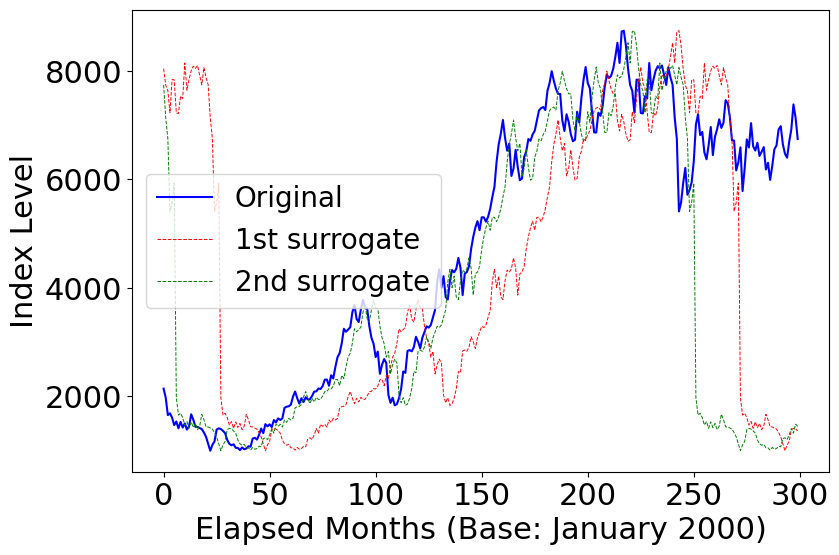

In [31]:
surro1 = np.loadtxt("surro_index/PP/qp_surr_001")
surro2 = np.loadtxt("surro_index/PP/qp_surr_002")
surro3 = np.loadtxt("surro_index/PP/qp_surr_003")
f1, ax1 = plt.subplots(1)
ax1.plot(data,linewidth=1.5,label = 'Original', color="blue")
ax1.plot(surro1, "r--",linewidth=0.7,label = '1st surrogate')
ax1.plot(surro2, "g--",linewidth=0.7, label = '2nd surrogate')
plt.xlabel("Elapsed Months (Base: January 2000)")
plt.legend()
plt.ylabel("Index Level")
f1.savefig('test_output/PP_surrogates_index.eps', format="eps", dpi=650)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


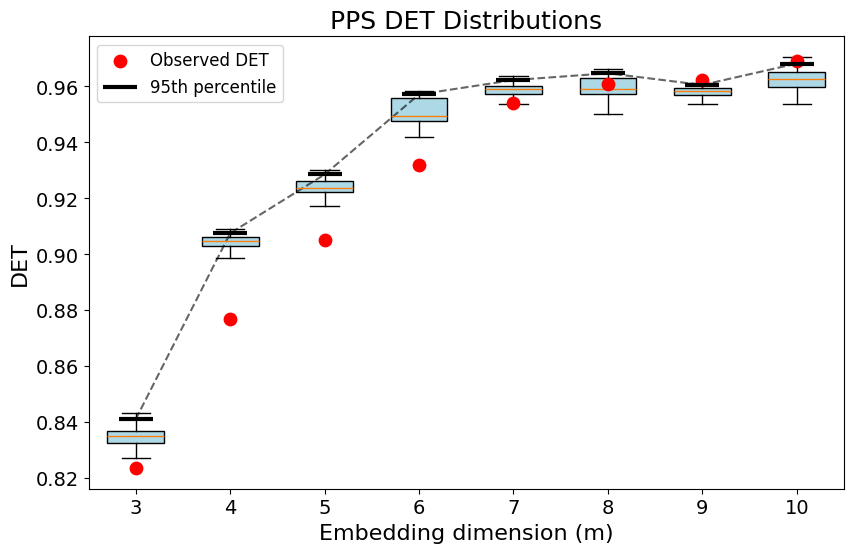

In [19]:

fig, ax = plt.subplots(1)

# Use actual embedding dimensions
dims = embed    # e.g. [3,4,5,6,7,8,9,10,11,12]

# Boxplots of surrogate DET distributions
bp = ax.boxplot(
    det_surro_ff,
    positions=dims,
    widths=0.6,
    patch_artist=True,
    showfliers=False
)

for box in bp['boxes']:
    box.set(
        facecolor='lightblue',
        edgecolor='black'
    )

# Observed DET values
ax.scatter(
    dims,
    det_j,
    color='red',
    s=80,
    zorder=10,
    label='Observed DET'
)

# 95th percentile of surrogate distributions
q95 = [
    np.percentile(x, 95)
    for x in det_surro_ff
]

ax.scatter(
    dims,
    q95,
    color='black',
    marker='_',
    s=600,
    linewidths=3,
    zorder=11,
    label='95th percentile'
)

# Connect the 95th percentiles
ax.plot(
    dims,
    q95,
    'k--',
    alpha=0.6
)

ax.set_xticks(dims)

ax.set_xlabel(
    "Embedding dimension (m)",
    fontsize=16
)

ax.set_ylabel(
    "DET",
    fontsize=16
)

ax.set_title(
    "PPS DET Distributions",
    fontsize=18
)

ax.tick_params(
    axis='both',
    labelsize=14
)

ax.legend(fontsize=12)

plt.tight_layout()

fig.savefig(
    "test_output/PP/PP_surro_m.eps",
    format="eps",
    dpi=650,
    bbox_inches="tight"
)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


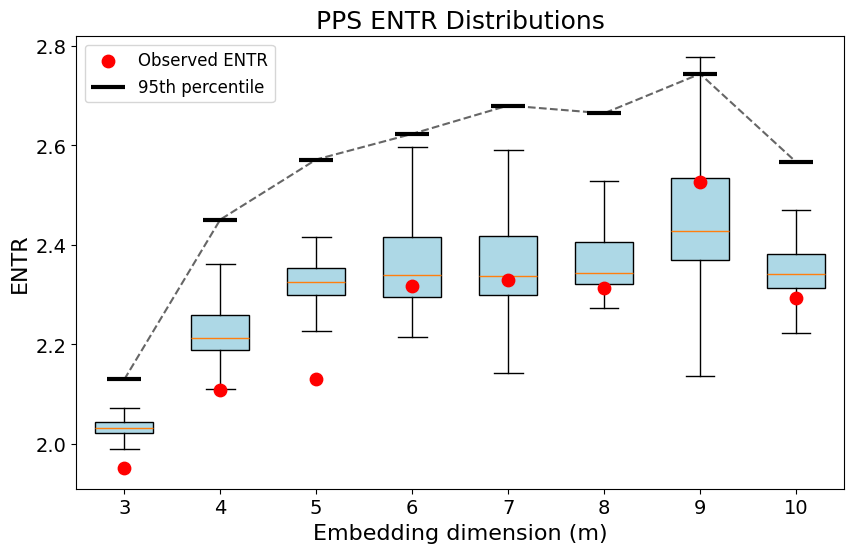

In [20]:

fig, ax = plt.subplots(1)

# Use actual embedding dimensions
dims = embed    # e.g. [3,4,5,6,7,8,9,10,11,12]

# Boxplots of surrogate DET distributions
bp = ax.boxplot(
    ent_surro,
    positions=dims,
    widths=0.6,
    patch_artist=True,
    showfliers=False
)

for box in bp['boxes']:
    box.set(
        facecolor='lightblue',
        edgecolor='black'
    )

# Observed DET values
ax.scatter(
    dims,
    ent_j,
    color='red',
    s=80,
    zorder=10,
    label='Observed ENTR'
)

# 95th percentile of surrogate distributions
qe95 = [
    np.percentile(x, 95)
    for x in ent_surro
]

ax.scatter(
    dims,
    qe95,
    color='black',
    marker='_',
    s=600,
    linewidths=3,
    zorder=11,
    label='95th percentile'
)

# Connect the 95th percentiles
ax.plot(
    dims,
    qe95,
    'k--',
    alpha=0.6
)

ax.set_xticks(dims)

ax.set_xlabel(
    "Embedding dimension (m)",
    fontsize=16
)

ax.set_ylabel(
    "ENTR",
    fontsize=16
)

ax.set_title(
    "PPS ENTR Distributions",
    fontsize=18
)

ax.tick_params(
    axis='both',
    labelsize=14
)

ax.legend(fontsize=12)

plt.tight_layout()

fig.savefig(
    "test_output/PP/PP_surro_entr_m.eps",
    format="eps",
    dpi=650,
    bbox_inches="tight"
)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


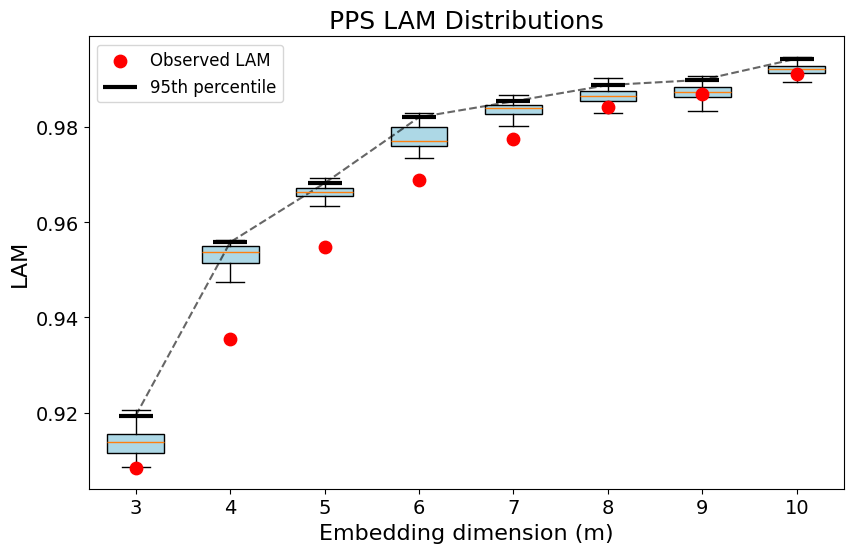

In [21]:

fig, ax = plt.subplots(1)

# Use actual embedding dimensions
dims = embed    # e.g. [3,4,5,6,7,8,9,10,11,12]

# Boxplots of surrogate DET distributions
bp = ax.boxplot(
    lam_surro,
    positions=dims,
    widths=0.6,
    patch_artist=True,
    showfliers=False
)

for box in bp['boxes']:
    box.set(
        facecolor='lightblue',
        edgecolor='black'
    )

# Observed DET values
ax.scatter(
    dims,
    lam_j,
    color='red',
    s=80,
    zorder=10,
    label='Observed LAM'
)

# 95th percentile of surrogate distributions
ql95 = [
    np.percentile(x, 95)
    for x in lam_surro
]

ax.scatter(
    dims,
    ql95,
    color='black',
    marker='_',
    s=600,
    linewidths=3,
    zorder=11,
    label='95th percentile'
)

# Connect the 95th percentiles
ax.plot(
    dims,
    ql95,
    'k--',
    alpha=0.6
)

ax.set_xticks(dims)

ax.set_xlabel(
    "Embedding dimension (m)",
    fontsize=16
)

ax.set_ylabel(
    "LAM",
    fontsize=16
)

ax.set_title(
    "PPS LAM Distributions",
    fontsize=18
)

ax.tick_params(
    axis='both',
    labelsize=14
)

ax.legend(fontsize=12)

plt.tight_layout()

fig.savefig(
    "test_output/PP/PP_surro_lam_m.eps",
    format="eps",
    dpi=650,
    bbox_inches="tight"
)

plt.show()

# Log-returns

In [16]:
log_returns = np.diff(np.log(data))
np.savetxt("log_returns", log_returns)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


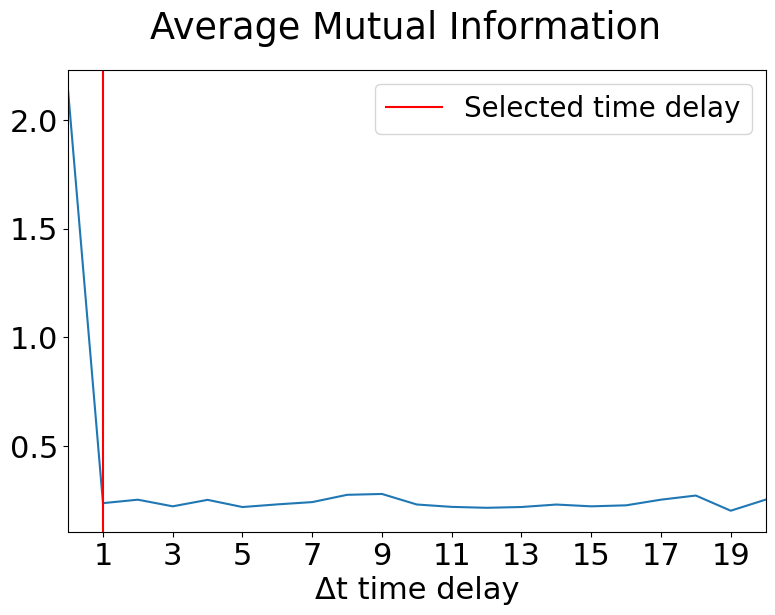

[ 1  3  5 12 15 19]
1


In [17]:
os.system("./mutual log_returns -D20 -o files/mutual_log_returns -V0")
m_site1 = np.loadtxt("files/mutual_log_returns", delimiter =' ', usecols =(1) , skiprows=0)
fig2, axs = plt.subplots(1)
fig2.suptitle("Average Mutual Information")
axs.plot(m_site1)
plt.axvline(x = 1, color = 'red', label = 'Selected time delay')
plt.xticks(range(1,20,2))
axs.set_xlim([0, 20])
#axs.set_ylim([1, 2])
plt.xlabel("Δt time delay")
plt.legend()
fig2.savefig('test_output/AMI_log_returns.eps', format="eps", dpi=650)
plt.show()
plt.close()
g = np.loadtxt("files/mutual_log_returns", skiprows=1, usecols=1)
mn = np.where((g[1:-1] < g[:-2]) & (g[1:-1] < g[2:]))[0] + 1
print(mn)
t_min=mn[0]
print(t_min)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


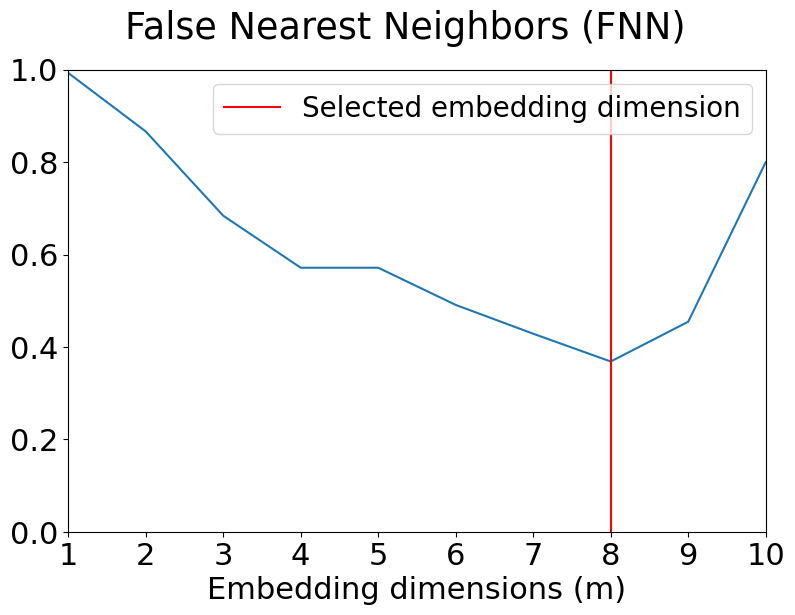

In [18]:
os.system("./false_nearest log_returns -M1,10 -d1 -o files/log_returns.fnn -V0")
m1 = np.loadtxt("files/log_returns.fnn", usecols=1)
d1 = np.loadtxt("files/log_returns.fnn", usecols=0)
fig2, ax = plt.subplots(1)
fig2.suptitle("False Nearest Neighbors (FNN)")
ax.plot(d1, m1)
#ax.set_yscale("log")
plt.xticks(range(1,20,1))
plt.xlabel("Embedding dimensions (m)")
plt.axvline(x = 8, color = 'red', label = 'Selected embedding dimension')
plt.legend()
ax.set_xlim([1, 10])
ax.set_ylim([0.00, 1])
fig2.savefig('test_output/FNN_log_returns.eps', format="eps", dpi=650)
plt.show()
plt.close()


{'m': 8,
 'fnn_value': 0.3684211,
 'method': 'No saturation detected (minimum FNN fallback)'}

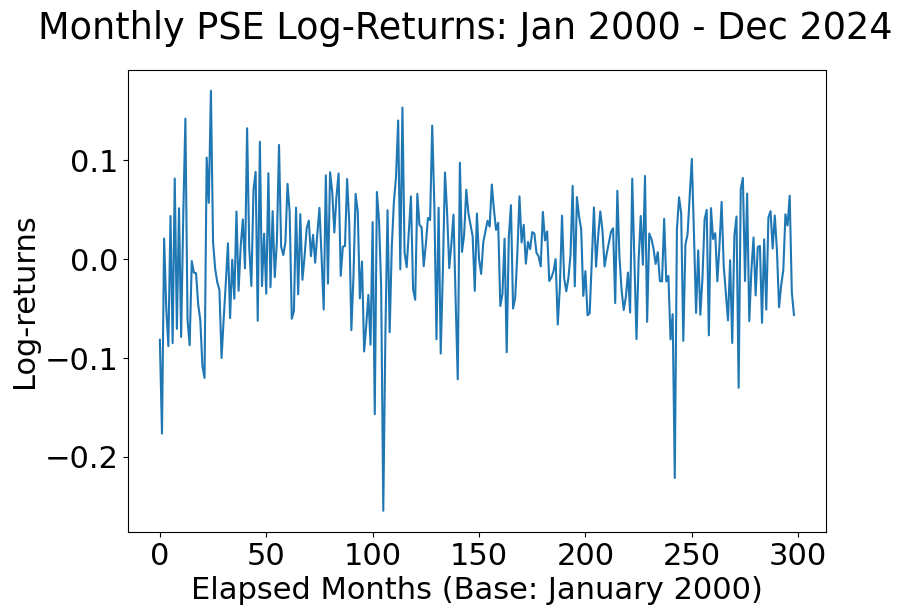

In [19]:
f1, ax1 = plt.subplots(1)
f1.suptitle("Monthly PSE Log-Returns: Jan 2000 - Dec 2024")
ax1.plot(log_returns)
plt.xlabel("Elapsed Months (Base: January 2000)")
plt.ylabel("Log-returns")
f1.savefig('test_output/log_returns.eps', format="eps", dpi=650)
extract_embedding_dimension("log_returns")

## WIAAFT

WIAAFT surrogate datasets generated


  0%|                                                     | 0/8 [00:00<?, ?it/s]

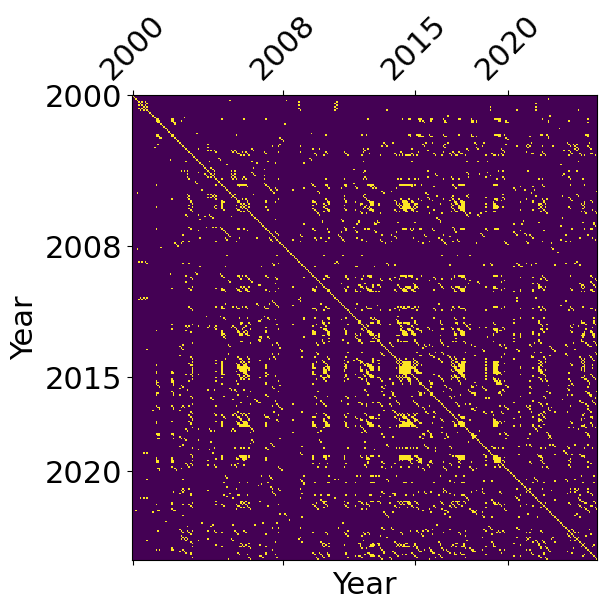

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


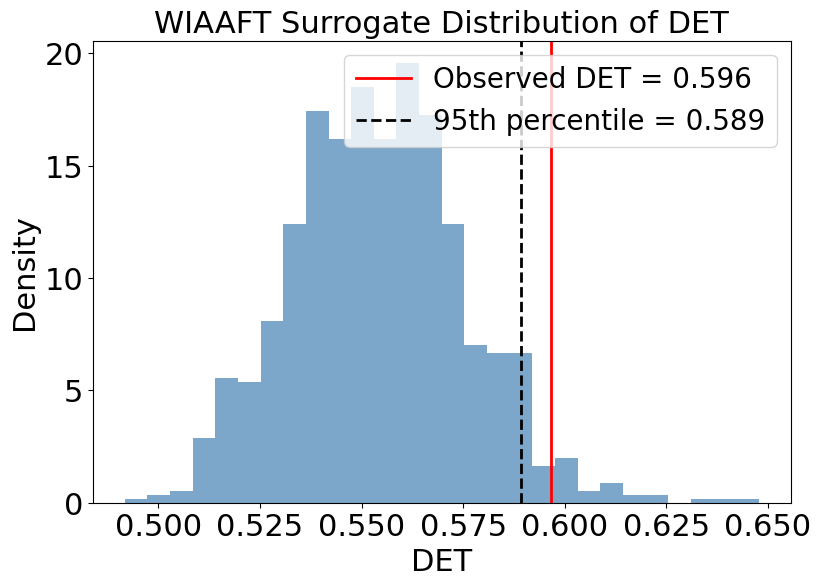

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


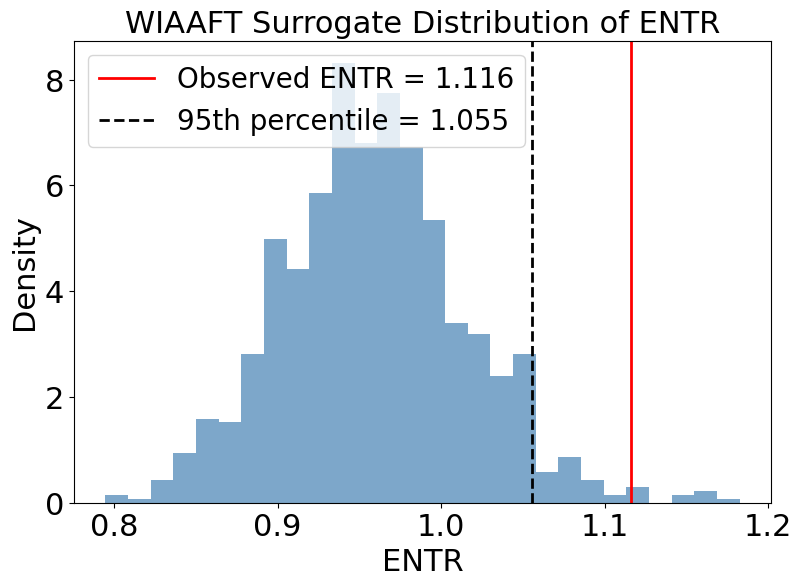

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


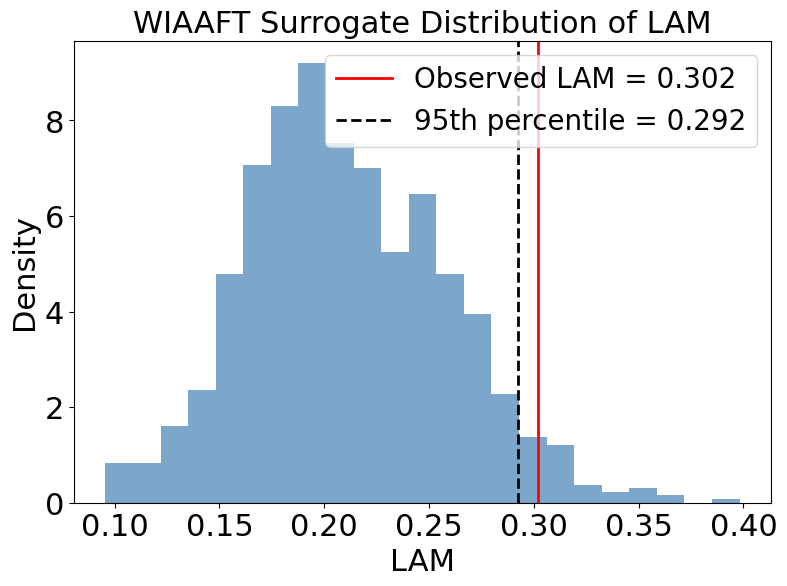

 12%|█████▋                                       | 1/8 [00:08<00:56,  8.11s/it]

RQA  log_returns Embedding dimensions:3 
 DET of original:0.5964997569261145 
 Recurrence rate: 0.050006235191420376 
Threshold:0.7344999999999354 
 Laminarity:0.302199047834273 
Shannon Entropy:1.1160913094215752 
Rank-order p-value (det):0.028 
Rank-order p-value (lam):0.04 
Rank-order p-value (entr):0.011 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



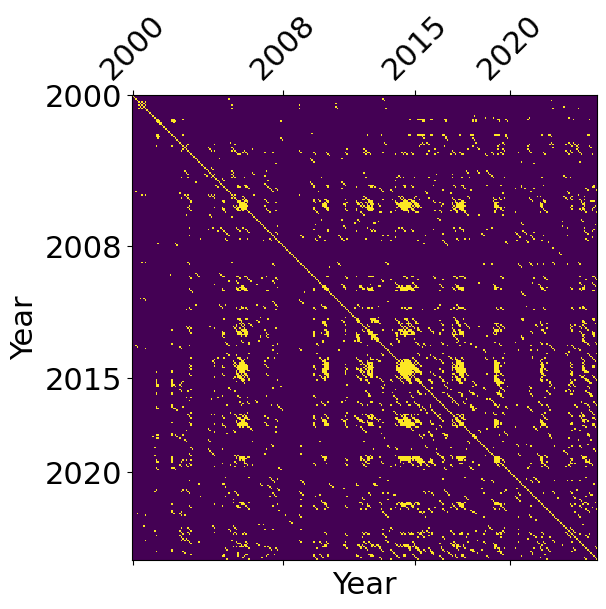

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


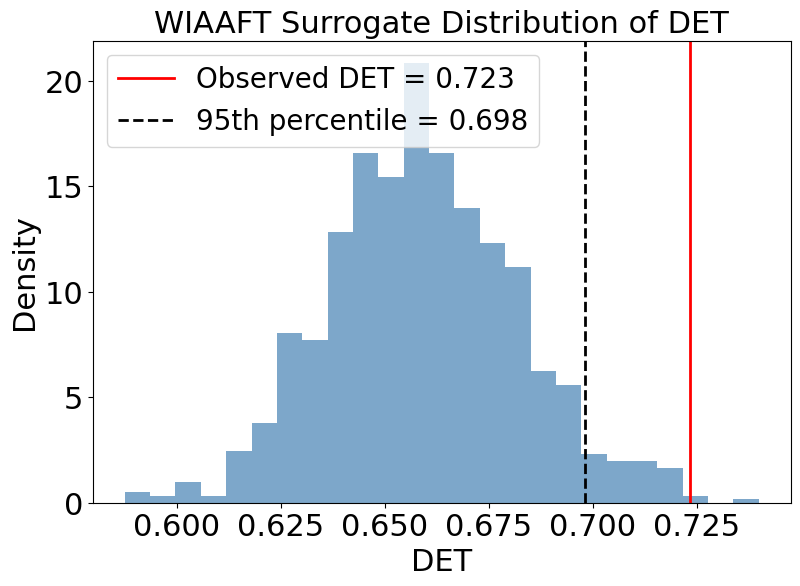

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


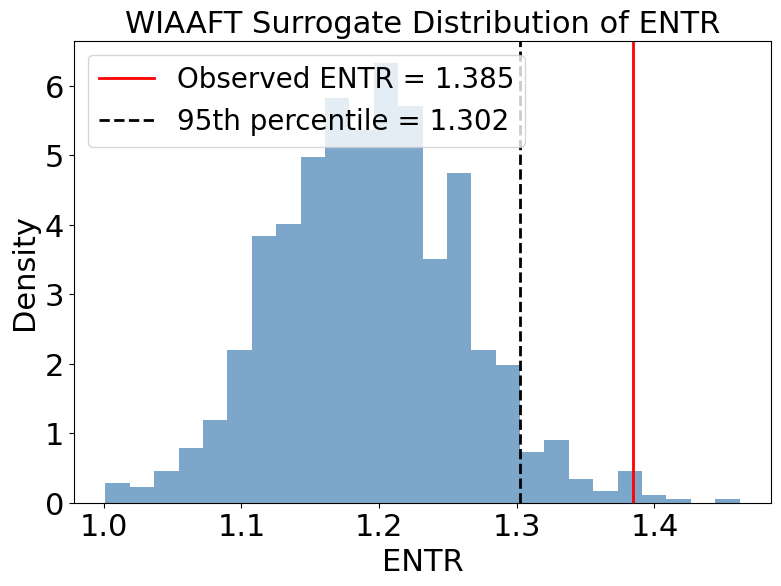

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


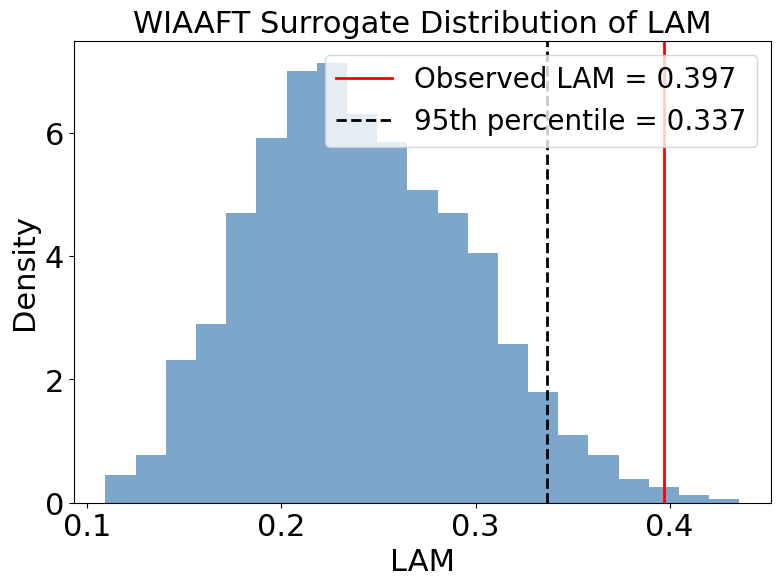

 25%|███████████▎                                 | 2/8 [00:19<00:58,  9.77s/it]

RQA  log_returns Embedding dimensions:4 
 DET of original:0.7234459128714551 
 Recurrence rate: 0.05001369612856099 
Threshold:1.039899999999902 
 Laminarity:0.397307165676866 
Shannon Entropy:1.3845141369528717 
Rank-order p-value (det):0.003 
Rank-order p-value (lam):0.005 
Rank-order p-value (entr):0.006 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



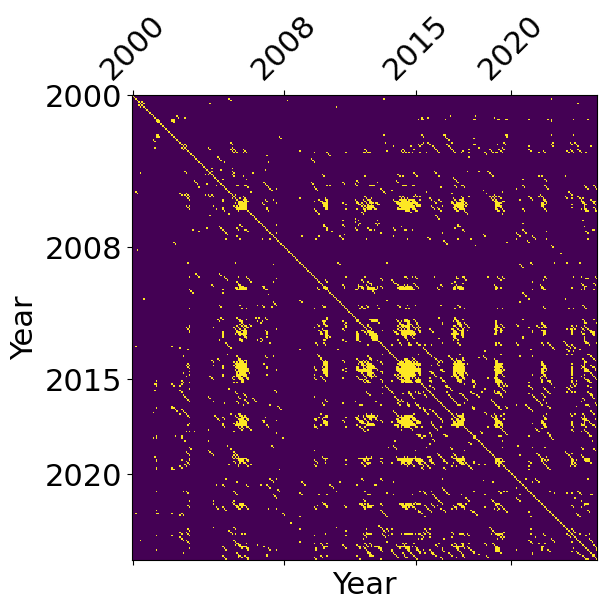

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


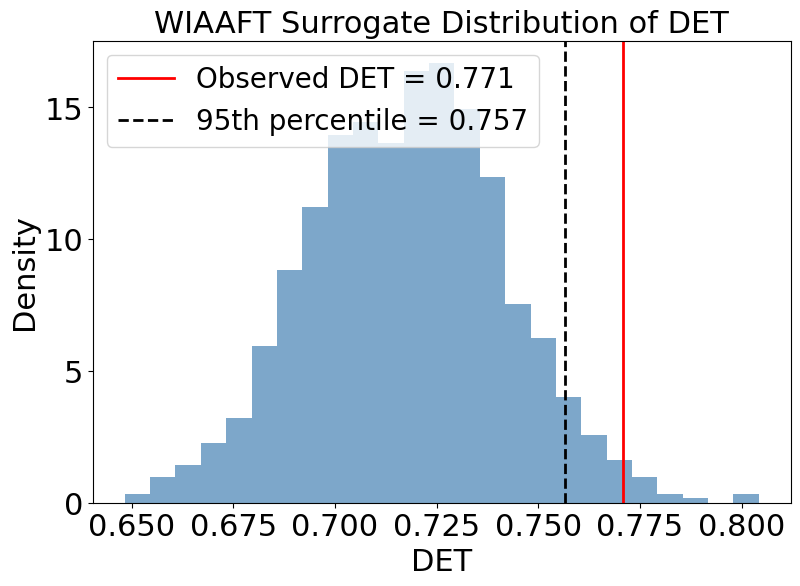

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


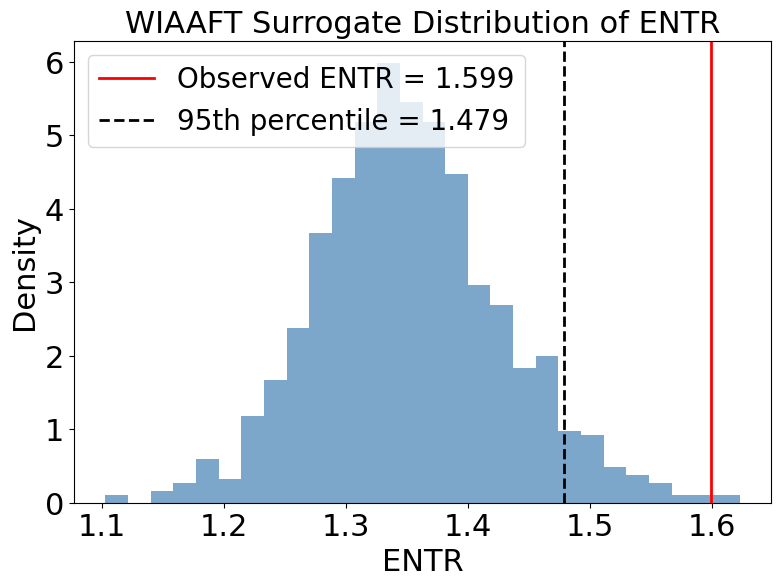

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


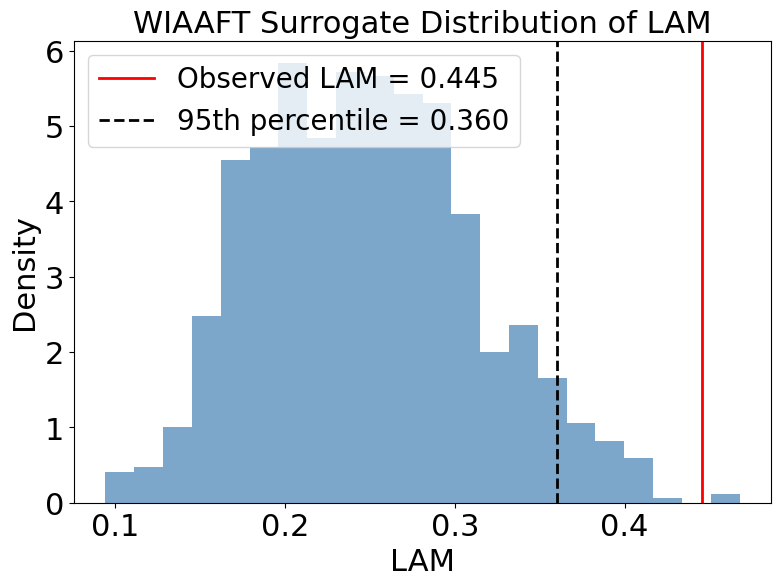

 38%|████████████████▉                            | 3/8 [00:33<00:58, 11.75s/it]

RQA  log_returns Embedding dimensions:5 
 DET of original:0.7708230655476322 
 Recurrence rate: 0.05002010916403332 
Threshold:1.2986999999998734 
 Laminarity:0.44543992648645664 
Shannon Entropy:1.598669086031546 
Rank-order p-value (det):0.015 
Rank-order p-value (lam):0.003 
Rank-order p-value (entr):0.004 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



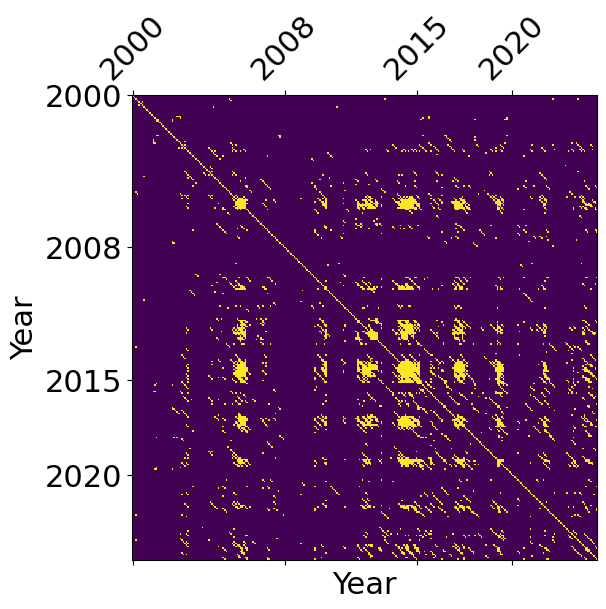

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


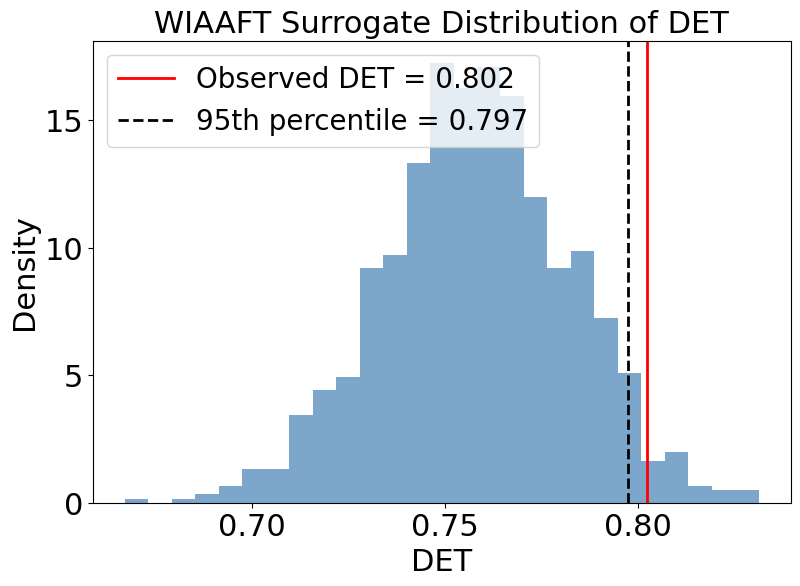

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


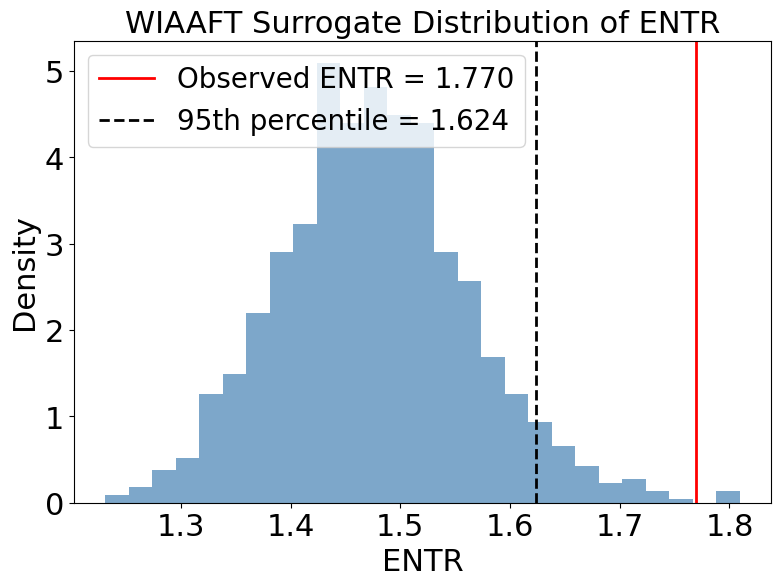

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


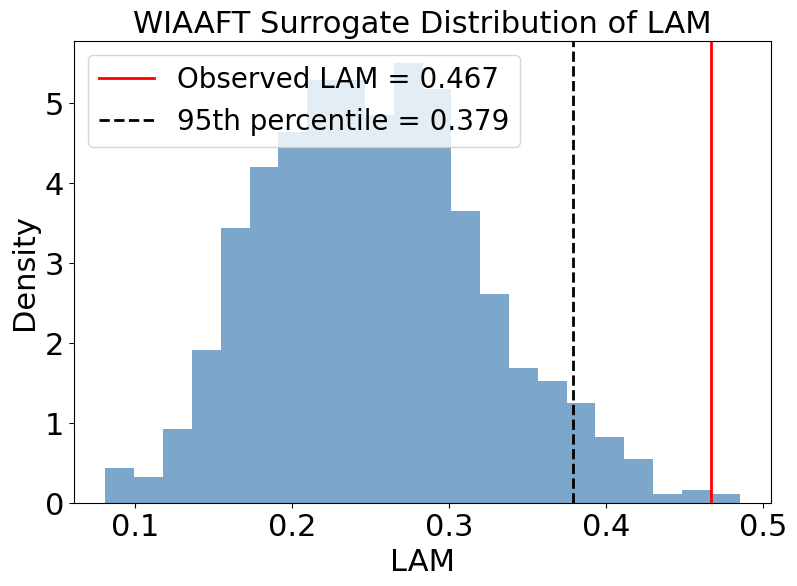

 50%|██████████████████████▌                      | 4/8 [00:49<00:54, 13.58s/it]

RQA  log_returns Embedding dimensions:6 
 DET of original:0.8023833167805303 
 Recurrence rate: 0.05000231385071035 
Threshold:1.5397999999998468 
 Laminarity:0.46668209162316826 
Shannon Entropy:1.7699114627159465 
Rank-order p-value (det):0.031 
Rank-order p-value (lam):0.003 
Rank-order p-value (entr):0.004 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



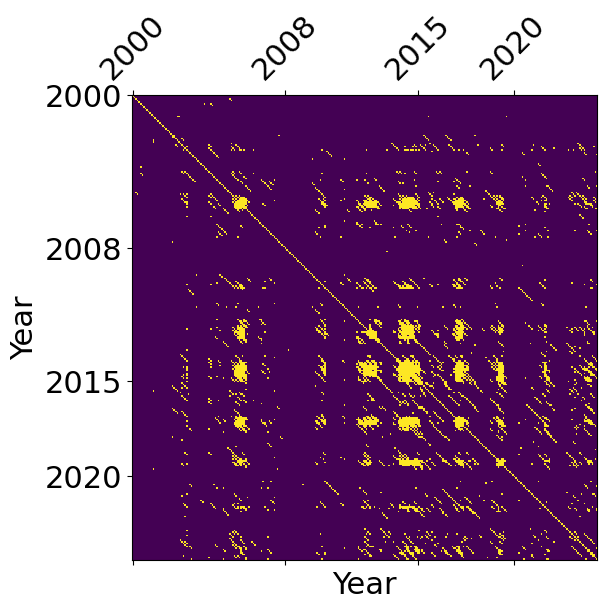

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


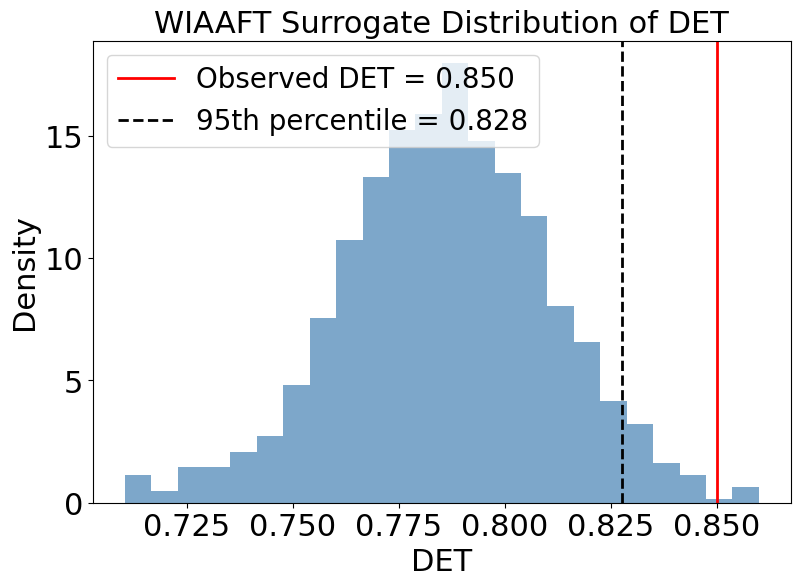

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


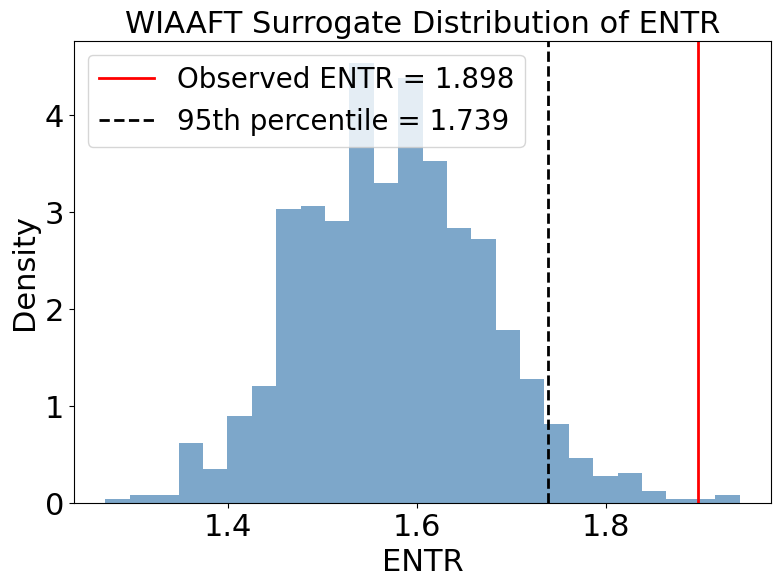

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


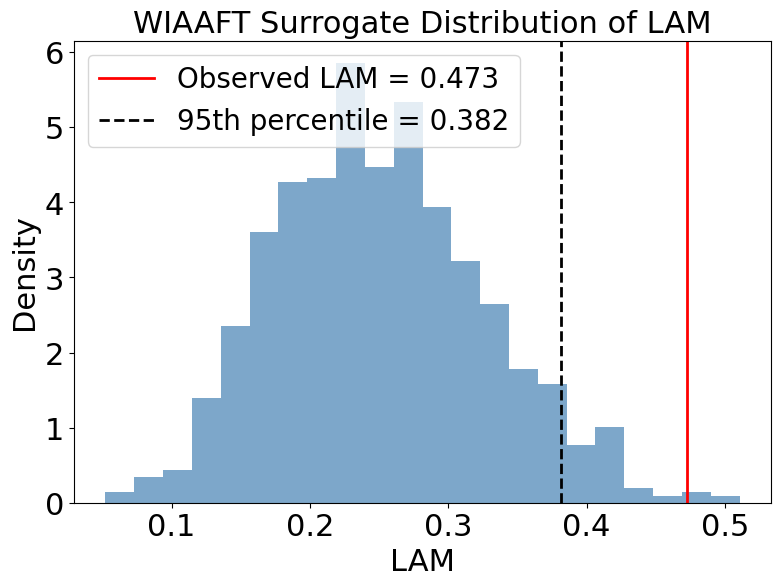

 62%|████████████████████████████▏                | 5/8 [01:08<00:46, 15.48s/it]

RQA  log_returns Embedding dimensions:7 
 DET of original:0.849999999997875 
 Recurrence rate: 0.050006406597630726 
Threshold:1.7589999999998227 
 Laminarity:0.4728627999057236 
Shannon Entropy:1.8977004217194673 
Rank-order p-value (det):0.005 
Rank-order p-value (lam):0.005 
Rank-order p-value (entr):0.003 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



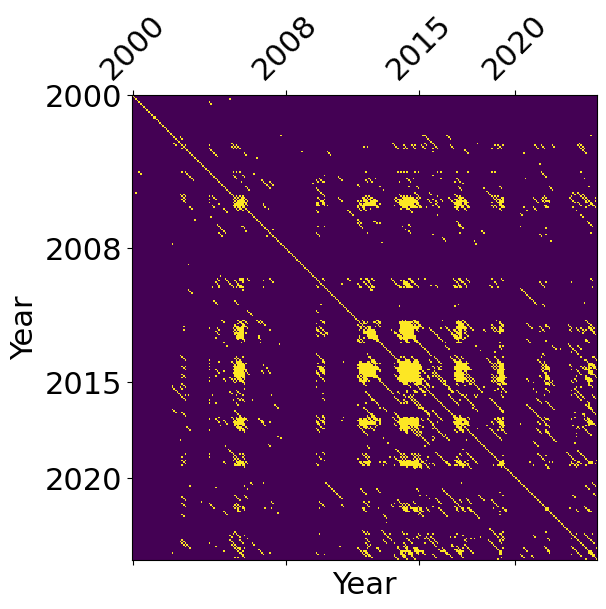

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


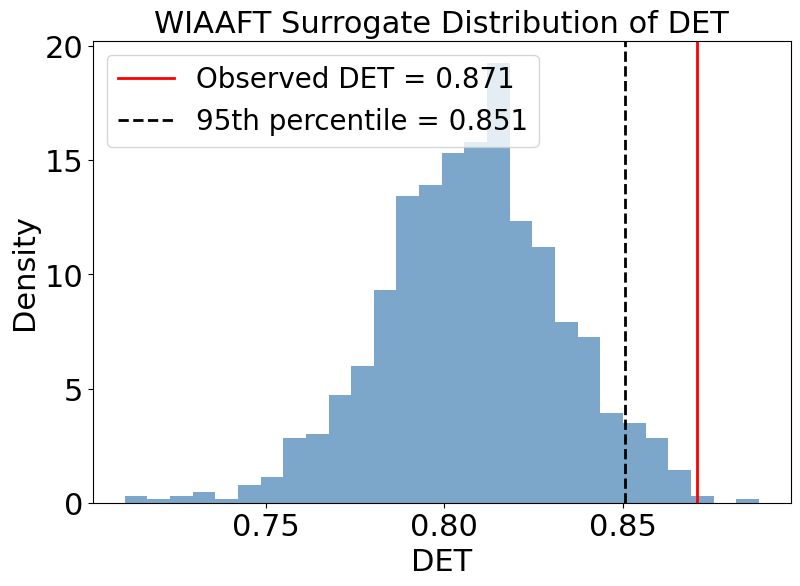

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


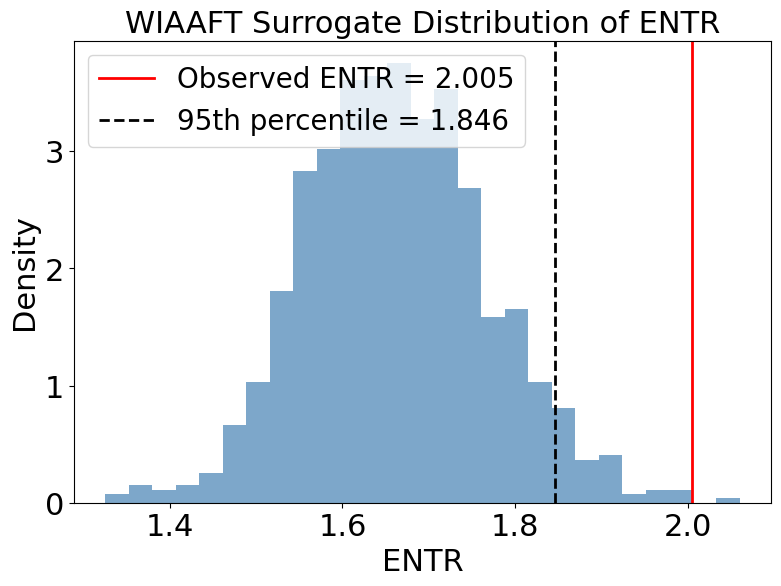

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


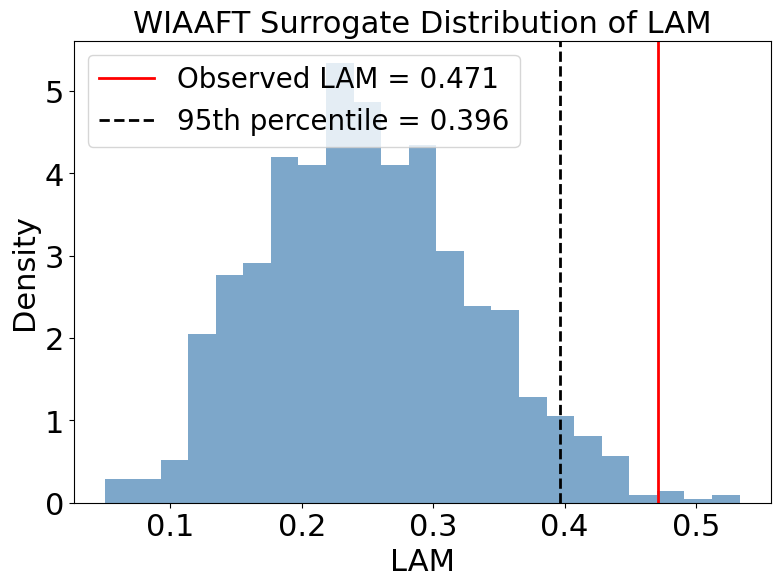

 75%|█████████████████████████████████▊           | 6/8 [01:29<00:34, 17.30s/it]

RQA  log_returns Embedding dimensions:8 
 DET of original:0.8705941591116048 
 Recurrence rate: 0.0500093826233815 
Threshold:1.9729999999997991 
 Laminarity:0.47138836772872567 
Shannon Entropy:2.0049668688089164 
Rank-order p-value (det):0.002 
Rank-order p-value (lam):0.007 
Rank-order p-value (entr):0.002 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



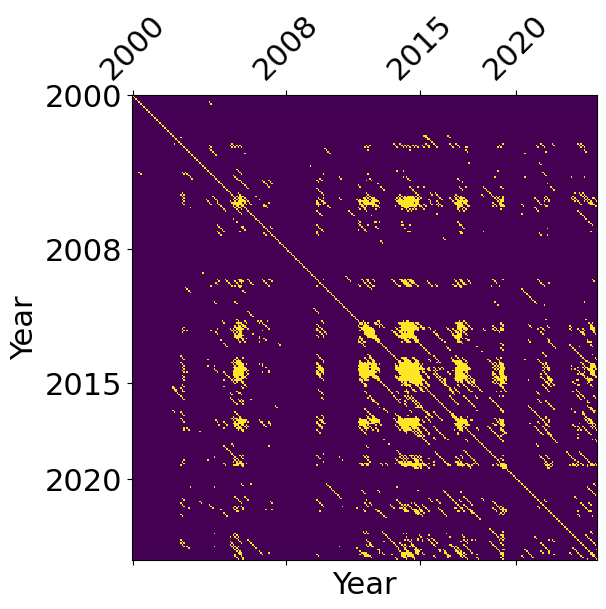

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


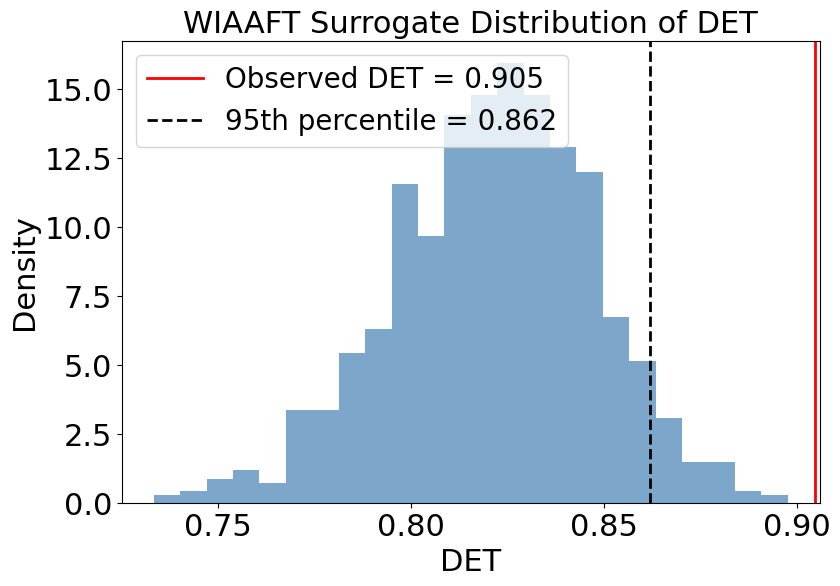

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


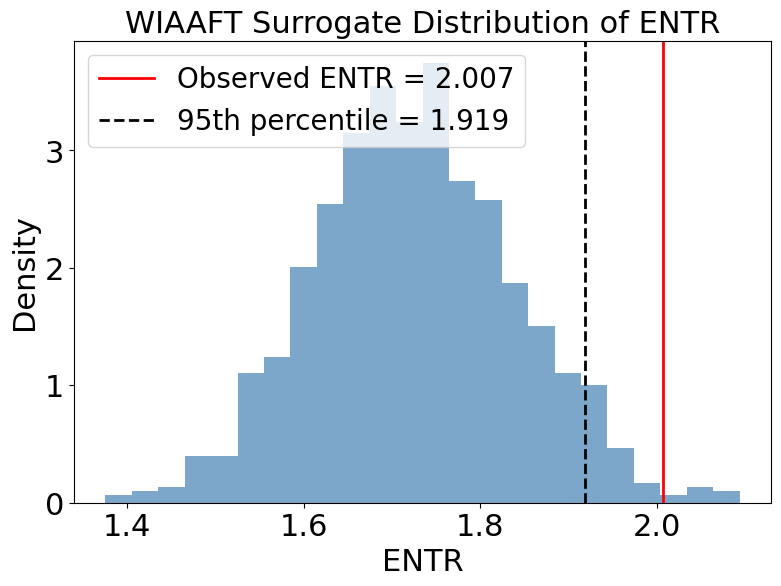

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


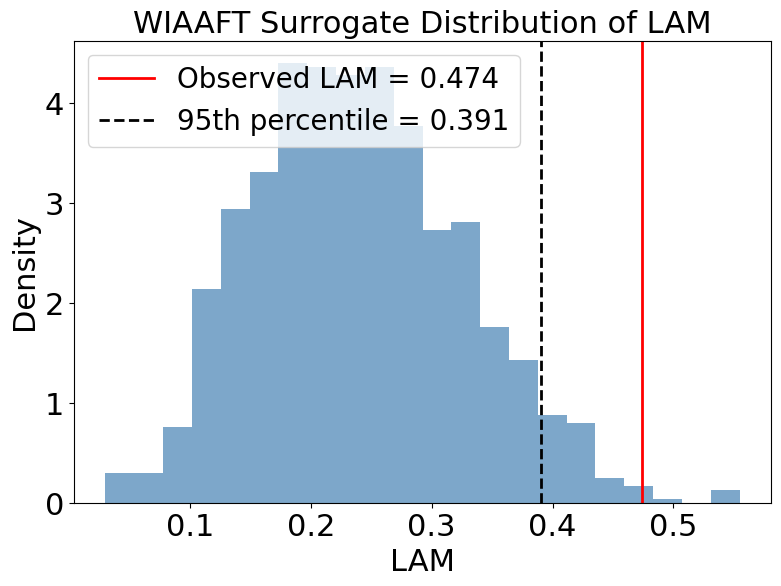

 88%|███████████████████████████████████████▍     | 7/8 [01:52<00:19, 19.18s/it]

RQA  log_returns Embedding dimensions:9 
 DET of original:0.904665314399329 
 Recurrence rate: 0.050011218573233665 
Threshold:2.1537000000001205 
 Laminarity:0.4736717827615734 
Shannon Entropy:2.0067033161242236 
Rank-order p-value (det):0.001 
Rank-order p-value (lam):0.005 
Rank-order p-value (entr):0.01 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



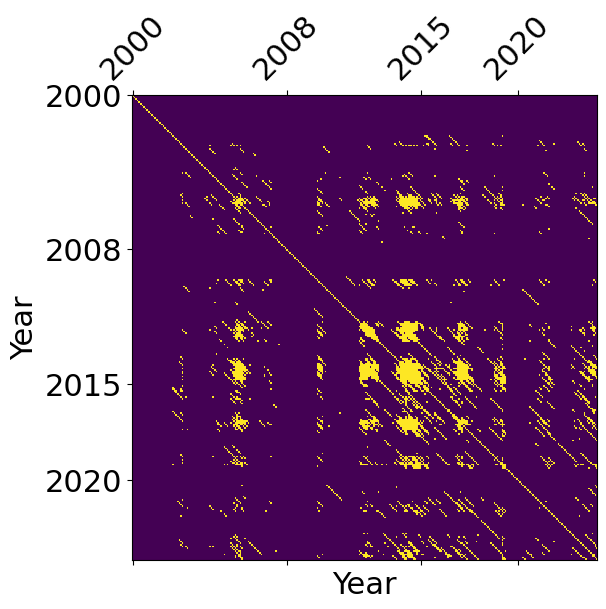

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


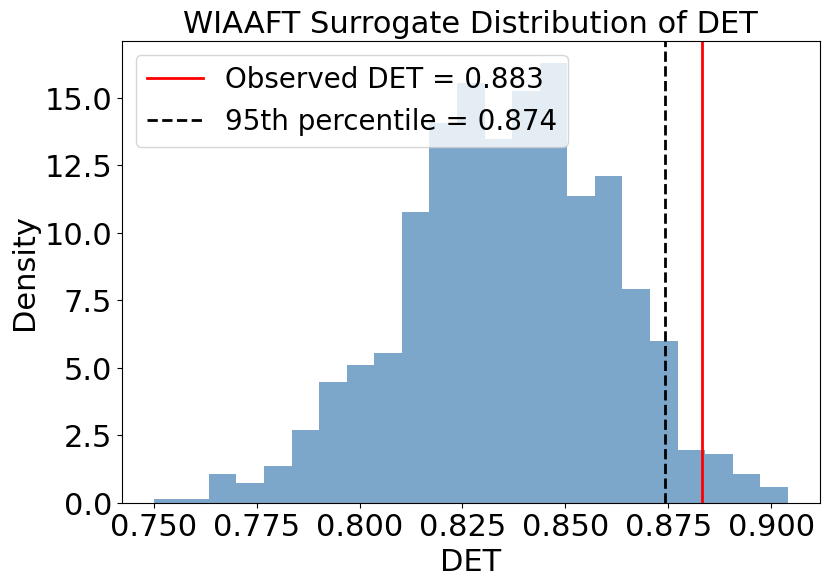

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


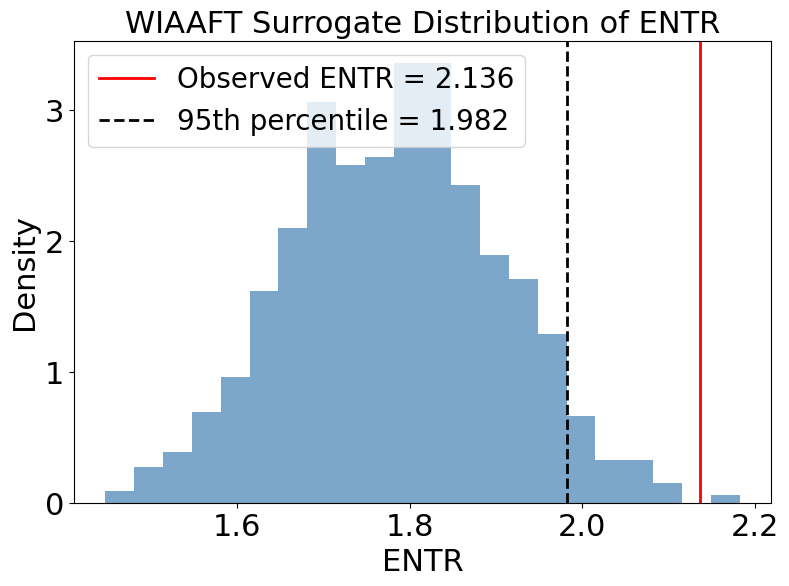

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


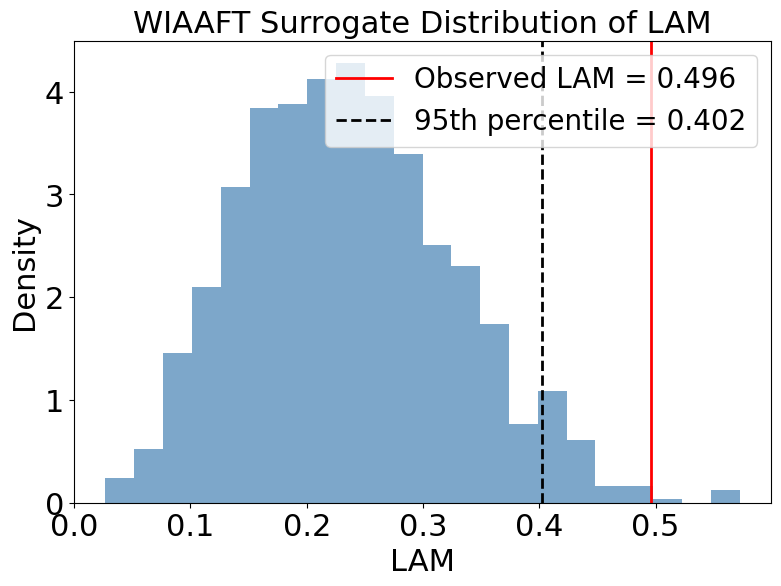

100%|█████████████████████████████████████████████| 8/8 [02:17<00:00, 17.16s/it]

RQA  log_returns Embedding dimensions:10 
 DET of original:0.8831036242958573 
 Recurrence rate: 0.05003567181926278 
Threshold:2.3423000000005185 
 Laminarity:0.49596007604444875 
Shannon Entropy:2.135983659159937 
Rank-order p-value (det):0.024 
Rank-order p-value (lam):0.005 
Rank-order p-value (entr):0.003 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



In [20]:
t_min=1
k="log_returns"
det_j=[]
embed=[]
det_surro_ff=[]
kkk=[]
lam_j=[]
ent_j=[]
lam_surro = []
ent_surro=[]
s = lcurve(k)
with open("test_output/log_returns_WIAAFT", "w") as f:
    subprocess.run(["julia", "WIAAFT_surrogates.jl", "log_returns"], text=True, check=True)
    for dim in tqdm(range(3, 11, 1)):
        tt1=0.001
        dimension=dim
        RR_orig = 0
        while RR_orig < 0.05:
            tt1 = tt1 + 0.0001
            det, RR_orig, lam_orig, entr_orig, matrix= RP_RN(s, dim, tt1)
        det_j.append(det)
        embed.append(dim)
        lam_j.append(lam_orig)
        ent_j.append(entr_orig)

        n = matrix.shape[0]
        
        ticks = [0, 96, 180, 240]

        labels = [
            "2000",
            "2008",
            "2015",
            "2020"
        ]
        
        pylab.matshow(matrix)
        
        pylab.xticks(
            ticks,
            labels,
            rotation=45
        )
        
        pylab.yticks(
            ticks,
            labels
        )
        
        pylab.xlabel("Year")
        pylab.ylabel("Year")
        
        pylab.savefig(
            f"test_output/WIAAFT/WIAAFT_RP_{dim}_log_returns.pdf",
            format="pdf",
            dpi=650
        )
        
        pylab.show()

        det_ff, lam_ff, entr_ff = sur_test_WIAAFT(dim, tt1)

        fig1, ax1 = plt.subplots(1)
        qd95 = np.percentile(det_ff, 95)
        ax1.hist(det_ff,bins='auto',density=True,alpha=0.7,color='steelblue')
        ax1.axvline(det,color='red',linewidth=2,label=f'Observed DET = {det:.3f}')
        ax1.axvline(qd95,color='black',linestyle='--',linewidth=2,label=f'95th percentile = {qd95:.3f}')
        ax1.set_xlabel("DET")
        ax1.set_ylabel("Density")
        ax1.set_title("WIAAFT Surrogate Distribution of DET")
        ax1.legend()
        fig1.savefig('test_output/WIAAFT/log_returns_surro_{}.eps'.format(dim), format="eps", dpi=650)
        plt.show()
        plt.close()

        fig2, ax2 = plt.subplots(1)
        qe95 = np.percentile(entr_ff, 95)
        ax2.hist(entr_ff,bins='auto',density=True,alpha=0.7,color='steelblue')
        ax2.axvline(entr_orig,color='red',linewidth=2,label=f'Observed ENTR = {entr_orig:.3f}')
        ax2.axvline(qe95,color='black',linestyle='--',linewidth=2,label=f'95th percentile = {qe95:.3f}')
        ax2.set_xlabel("ENTR")
        ax2.set_ylabel("Density")
        ax2.set_title("WIAAFT Surrogate Distribution of ENTR")
        ax2.legend()
        fig2.savefig('test_output/WIAAFT/log_returns_surro_{}_ENTR.eps'.format(dim), format="eps", dpi=650)
        plt.show()
        plt.close()

        fig3, axs3 = plt.subplots(1)
        ql95 = np.percentile(lam_ff, 95)
        axs3.hist(lam_ff,bins='auto',density=True,alpha=0.7,color='steelblue')
        axs3.axvline(lam_orig,color='red',linewidth=2,label=f'Observed LAM = {lam_orig:.3f}')
        axs3.axvline(ql95,color='black',linestyle='--',linewidth=2,label=f'95th percentile = {ql95:.3f}')
        axs3.set_xlabel("LAM")
        axs3.set_ylabel("Density")
        axs3.set_title("WIAAFT Surrogate Distribution of LAM")
        axs3.legend()
        fig3.savefig('test_output/WIAAFT/log_returns_surro_{}_LAM.eps'.format(dim), format="eps", dpi=650)
        plt.show()
        plt.close()
        
        r = np.sum(det_ff >= det)
        r1 = np.sum(lam_ff >= lam_orig)
        r2 = np.sum(entr_ff >= entr_orig)
        p_rank = (r + 1) / (999 + 1)
        p_rank_lam =(r1 + 1) / (999 + 1)
        p_rank_entr = (r2 + 1) / (999 + 1)
        alpha = 0.05
        reject_null1 = p_rank < alpha
        reject_null2 = p_rank_lam < alpha
        reject_null3 = p_rank_entr < alpha
        f.write("RQA  {} Embedding dimensions:{} \n" 
            " DET of original:{} \n"
            " Recurrence rate: {} \n" 
            "Threshold:{} \n "
            "Laminarity:{} \n" 
            "Shannon Entropy:{} \n" 
            "Rank-order p-value (det):{} \n"
            "Rank-order p-value (lam):{} \n"
            "Rank-order p-value (entr):{} \n" 
            "Reject null (det) hypothesis:{}\n Reject null (lam) hypothesis:{}\n"
            "Reject null (entr) hypothesis:{}\n \n \n".format(k, dim, det, RR_orig, tt1, lam_orig, entr_orig, 
                                                              p_rank, p_rank_lam, p_rank_entr, reject_null1, reject_null2, 
                                                              reject_null3))
        print("RQA  {} Embedding dimensions:{} \n" 
            " DET of original:{} \n"
            " Recurrence rate: {} \n" 
            "Threshold:{} \n "
            "Laminarity:{} \n" 
            "Shannon Entropy:{} \n" 
            "Rank-order p-value (det):{} \n"
            "Rank-order p-value (lam):{} \n"
            "Rank-order p-value (entr):{} \n" 
            "Reject null (det) hypothesis:{}\n Reject null (lam) hypothesis:{}\n"
            "Reject null (entr) hypothesis:{}\n \n \n".format(k, dim, det, RR_orig, tt1, lam_orig, entr_orig, 
                                                              p_rank, p_rank_lam, p_rank_entr, reject_null1, reject_null2, 
                                                              reject_null3))
        det_surro_ff.append(det_ff)
        kkk.append(np.full(999, dimension))
        lam_surro.append(lam_ff)
        ent_surro.append(entr_ff)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


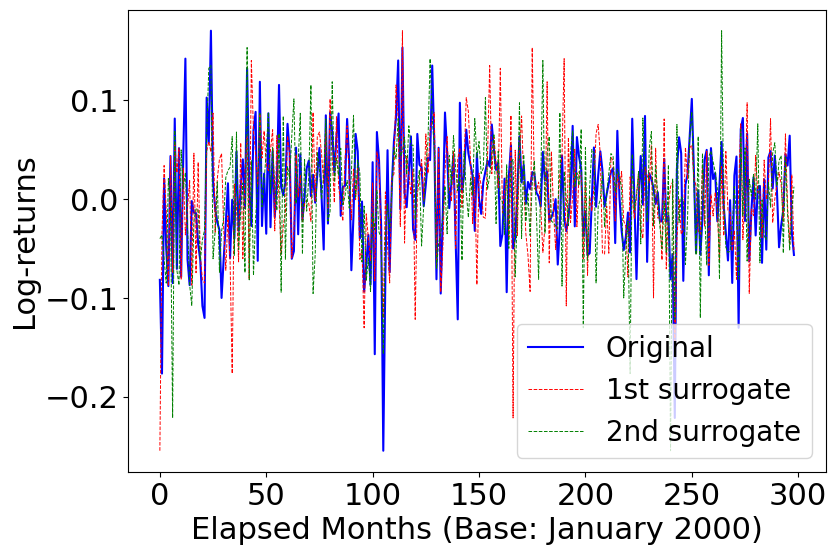

In [24]:
surro1 = np.loadtxt("surro_index/WIAAFT/qp_surr_001")
surro2 = np.loadtxt("surro_index/WIAAFT/qp_surr_002")
surro3 = np.loadtxt("surro_index/WIAAFT/qp_surr_003")
f1, ax1 = plt.subplots(1)
ax1.plot(log_returns,linewidth=1.5,label = 'Original', color="blue")
ax1.plot(surro1, "r--", linewidth=0.7, label = '1st surrogate')
ax1.plot(surro2, "g--", linewidth=0.7, label = '2nd surrogate')
plt.xlabel("Elapsed Months (Base: January 2000)")
plt.legend()
plt.ylabel("Log-returns")
f1.savefig('test_output/wiaaft_surrogates_log.eps', format="eps", dpi=650)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


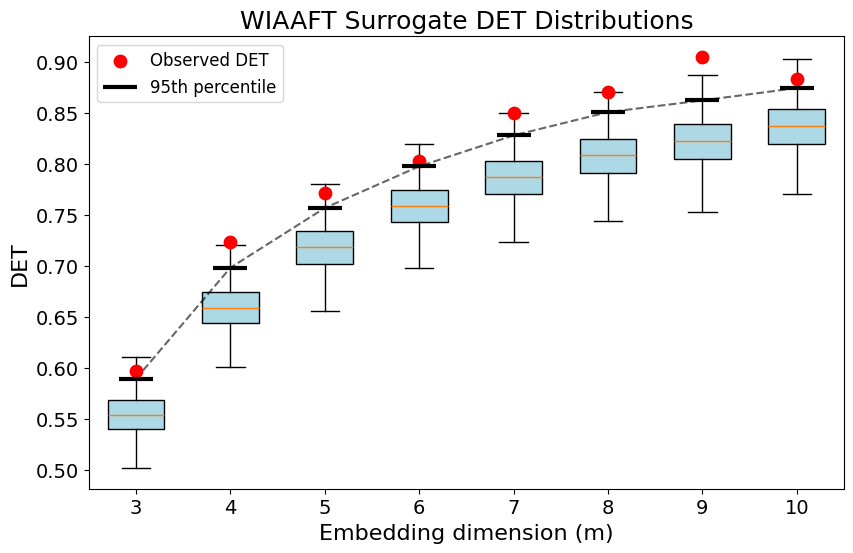

In [15]:

fig, ax = plt.subplots(1)

# Use actual embedding dimensions
dims = embed    # e.g. [3,4,5,6,7,8,9,10,11,12]

# Boxplots of surrogate DET distributions
bp = ax.boxplot(
    det_surro_ff,
    positions=dims,
    widths=0.6,
    patch_artist=True,
    showfliers=False
)

for box in bp['boxes']:
    box.set(
        facecolor='lightblue',
        edgecolor='black'
    )

# Observed DET values
ax.scatter(
    dims,
    det_j,
    color='red',
    s=80,
    zorder=10,
    label='Observed DET'
)

# 95th percentile of surrogate distributions
q95 = [
    np.percentile(x, 95)
    for x in det_surro_ff
]

ax.scatter(
    dims,
    q95,
    color='black',
    marker='_',
    s=600,
    linewidths=3,
    zorder=11,
    label='95th percentile'
)

# Connect the 95th percentiles
ax.plot(
    dims,
    q95,
    'k--',
    alpha=0.6
)

ax.set_xticks(dims)

ax.set_xlabel(
    "Embedding dimension (m)",
    fontsize=16
)

ax.set_ylabel(
    "DET",
    fontsize=16
)

ax.set_title(
    "WIAAFT Surrogate DET Distributions",
    fontsize=18
)

ax.tick_params(
    axis='both',
    labelsize=14
)

ax.legend(fontsize=12)

plt.tight_layout()

fig.savefig(
    "test_output/WIAAFT/WIAAFT_surro_m_logreturns.eps",
    format="eps",
    dpi=650,
    bbox_inches="tight"
)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


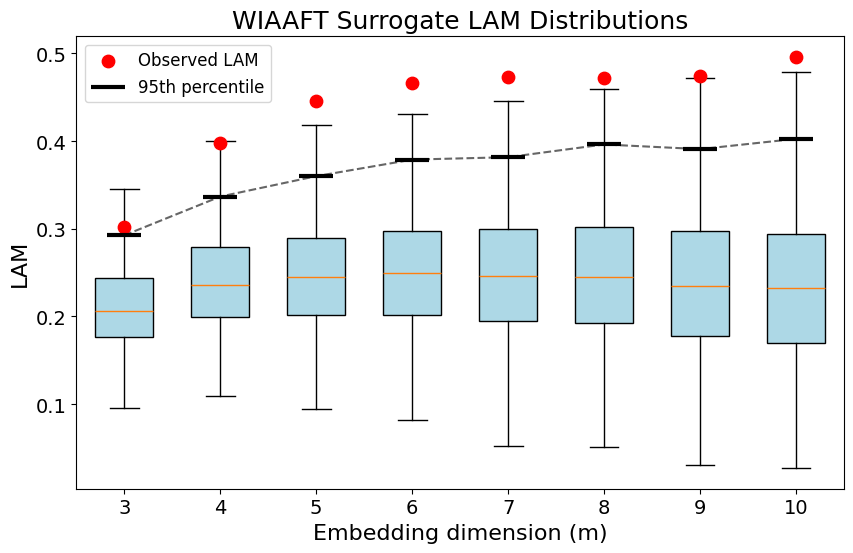

In [16]:

fig, ax = plt.subplots(1)

# Use actual embedding dimensions
dims = embed    # e.g. [3,4,5,6,7,8,9,10,11,12]

# Boxplots of surrogate DET distributions
bp = ax.boxplot(
    lam_surro,
    positions=dims,
    widths=0.6,
    patch_artist=True,
    showfliers=False
)

for box in bp['boxes']:
    box.set(
        facecolor='lightblue',
        edgecolor='black'
    )

# Observed DET values
ax.scatter(
    dims,
    lam_j,
    color='red',
    s=80,
    zorder=10,
    label='Observed LAM'
)

# 95th percentile of surrogate distributions
ql95 = [
    np.percentile(x, 95)
    for x in lam_surro
]

ax.scatter(
    dims,
    ql95,
    color='black',
    marker='_',
    s=600,
    linewidths=3,
    zorder=11,
    label='95th percentile'
)

# Connect the 95th percentiles
ax.plot(
    dims,
    ql95,
    'k--',
    alpha=0.6
)

ax.set_xticks(dims)

ax.set_xlabel(
    "Embedding dimension (m)",
    fontsize=16
)

ax.set_ylabel(
    "LAM",
    fontsize=16
)

ax.set_title(
    "WIAAFT Surrogate LAM Distributions",
    fontsize=18
)

ax.tick_params(
    axis='both',
    labelsize=14
)

ax.legend(fontsize=12)

plt.tight_layout()

fig.savefig(
    "test_output/WIAAFT/WIAAFT_surro_lam_m_logreturns.eps",
    format="eps",
    dpi=650,
    bbox_inches="tight"
)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


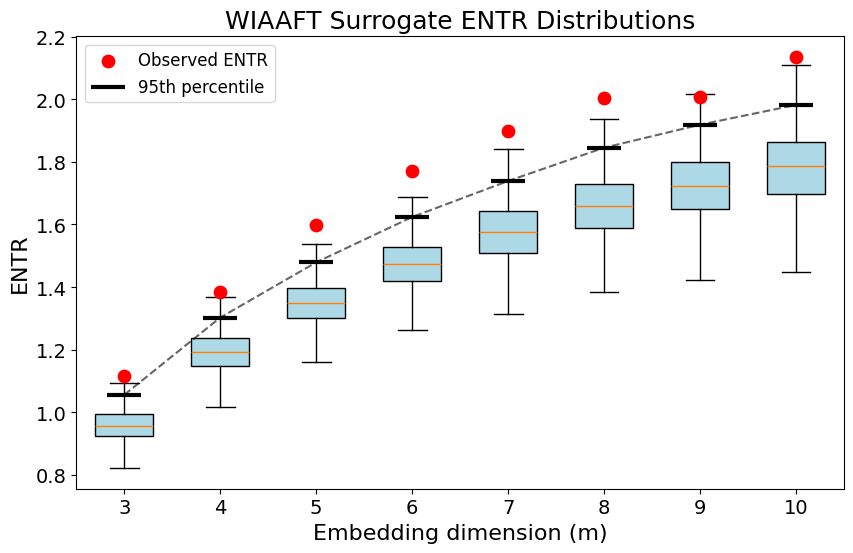

In [17]:

fig, ax = plt.subplots(1)

# Use actual embedding dimensions
dims = embed    # e.g. [3,4,5,6,7,8,9,10,11,12]

# Boxplots of surrogate DET distributions
bp = ax.boxplot(
    ent_surro,
    positions=dims,
    widths=0.6,
    patch_artist=True,
    showfliers=False
)

for box in bp['boxes']:
    box.set(
        facecolor='lightblue',
        edgecolor='black'
    )

# Observed DET values
ax.scatter(
    dims,
    ent_j,
    color='red',
    s=80,
    zorder=10,
    label='Observed ENTR'
)

# 95th percentile of surrogate distributions
qe95 = [
    np.percentile(x, 95)
    for x in ent_surro
]

ax.scatter(
    dims,
    qe95,
    color='black',
    marker='_',
    s=600,
    linewidths=3,
    zorder=11,
    label='95th percentile'
)

# Connect the 95th percentiles
ax.plot(
    dims,
    qe95,
    'k--',
    alpha=0.6
)

ax.set_xticks(dims)

ax.set_xlabel(
    "Embedding dimension (m)",
    fontsize=16
)

ax.set_ylabel(
    "ENTR",
    fontsize=16
)

ax.set_title(
    "WIAAFT Surrogate ENTR Distributions",
    fontsize=18
)

ax.tick_params(
    axis='both',
    labelsize=14
)

ax.legend(fontsize=12)

plt.tight_layout()

fig.savefig(
    "test_output/WIAAFT/WIAAFT_surro_entr_m_logreturns.eps",
    format="eps",
    dpi=650,
    bbox_inches="tight"
)

plt.show()

## PPS

  0%|                                                     | 0/8 [00:00<?, ?it/s]

Mean Nearest Neighbor Distance: 0.3809993748381841
Pseudo-periodic surrogates generated successfullly


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


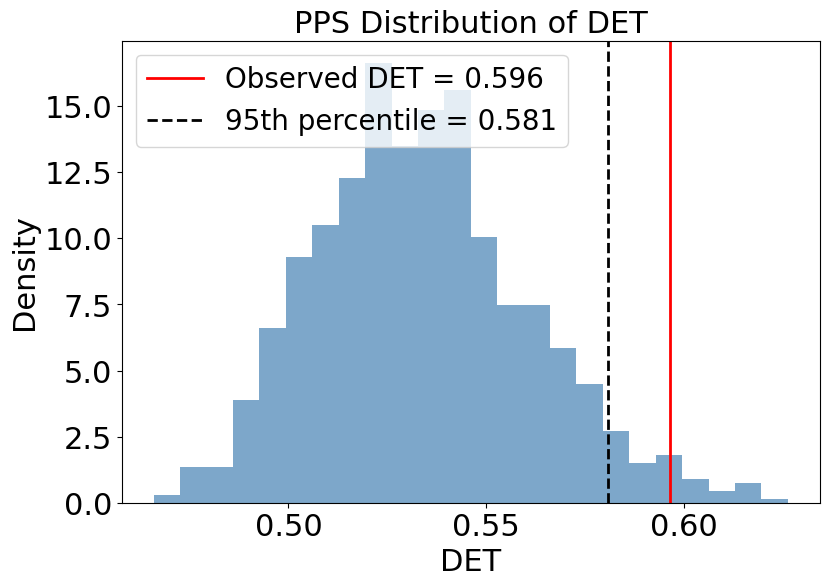

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


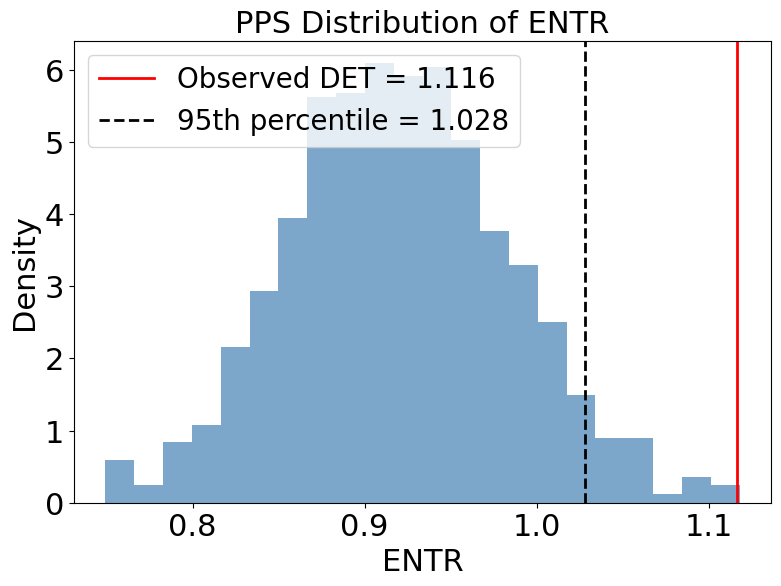

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


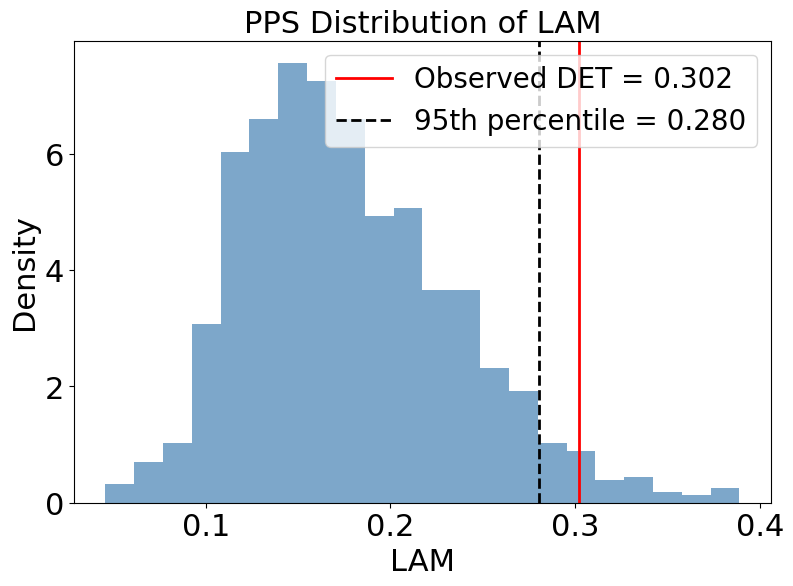

 12%|█████▋                                       | 1/8 [00:12<01:25, 12.23s/it]

RQA  log_returns Embedding dimensions:3 
 DET of original:0.5964997569261145 
 Recurrence rate: 0.050006235191420376 
Threshold:0.7344999999999354 
 Laminarity:0.302199047834273 
Shannon Entropy:1.1160913094215752 
Rank-order p-value (det):0.044 
Rank-order p-value (lam):0.064 
Rank-order p-value (entr):0.004 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:False
Reject null (entr) hypothesis:True
 
 

Mean Nearest Neighbor Distance: 0.649142693526036
Pseudo-periodic surrogates generated successfullly


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


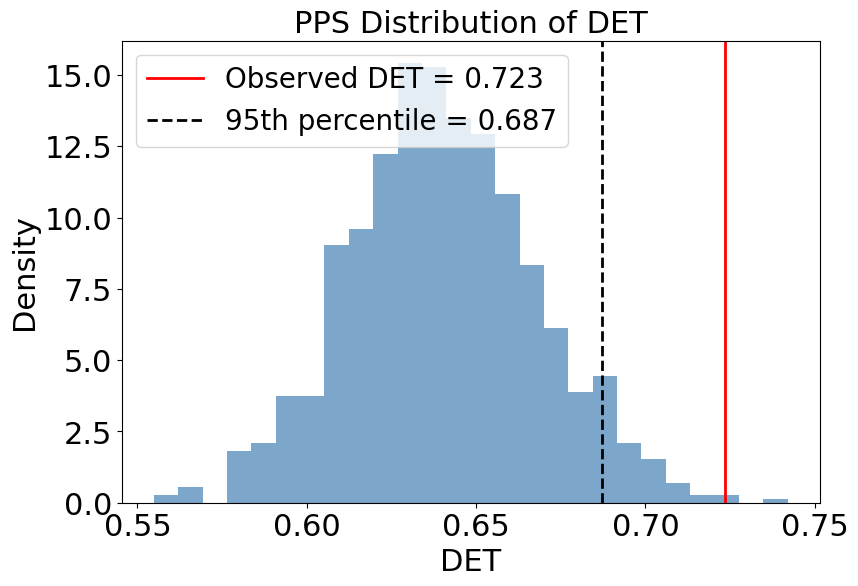

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


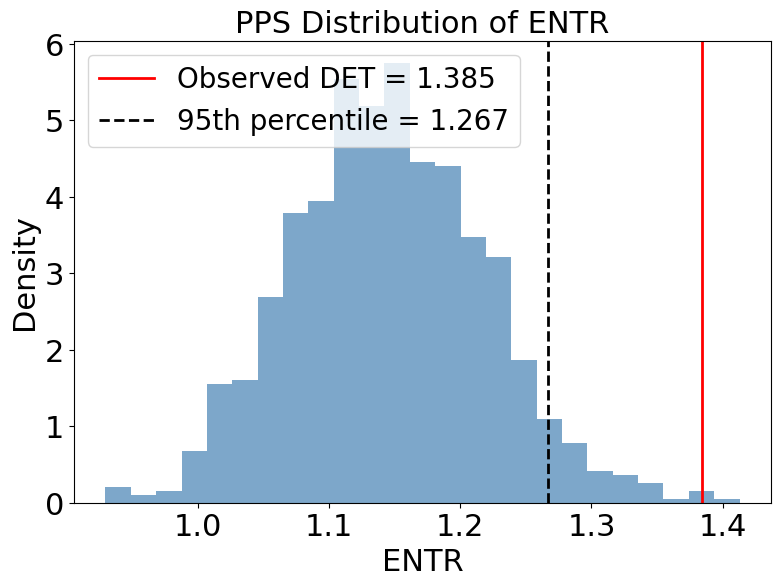

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


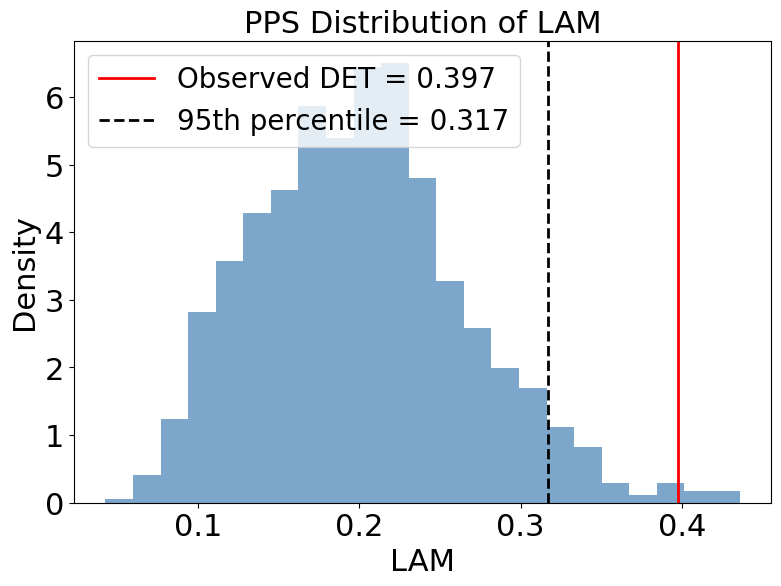

 25%|███████████▎                                 | 2/8 [00:27<01:24, 14.10s/it]

RQA  log_returns Embedding dimensions:4 
 DET of original:0.7234459128714551 
 Recurrence rate: 0.05001369612856099 
Threshold:1.039899999999902 
 Laminarity:0.397307165676866 
Shannon Entropy:1.3845141369528717 
Rank-order p-value (det):0.008 
Rank-order p-value (lam):0.014 
Rank-order p-value (entr):0.006 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 

Mean Nearest Neighbor Distance: 0.9072954208631322
Pseudo-periodic surrogates generated successfullly


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


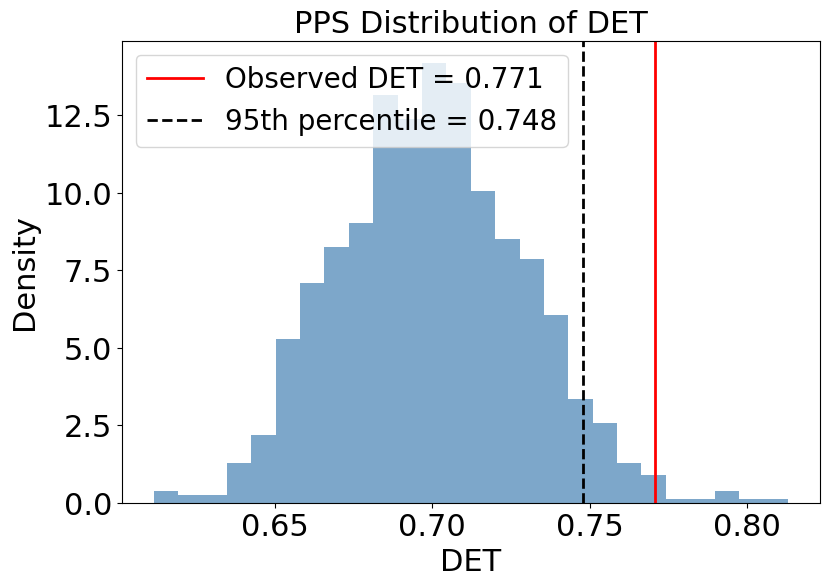

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


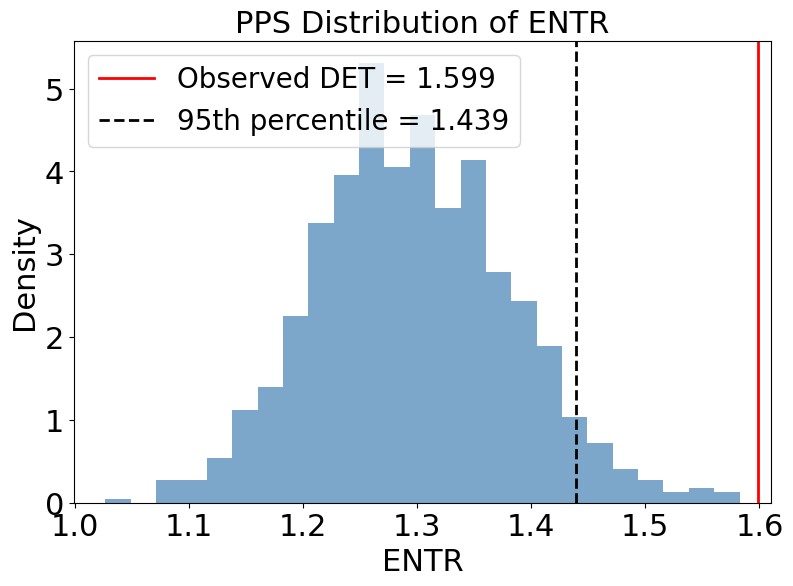

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


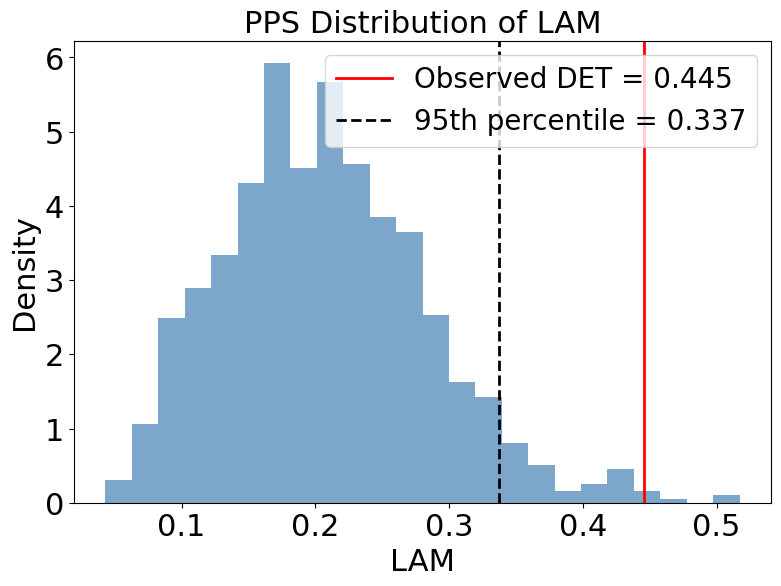

 38%|████████████████▉                            | 3/8 [00:45<01:19, 15.90s/it]

RQA  log_returns Embedding dimensions:5 
 DET of original:0.7708230655476322 
 Recurrence rate: 0.05002010916403332 
Threshold:1.2986999999998734 
 Laminarity:0.44543992648645664 
Shannon Entropy:1.598669086031546 
Rank-order p-value (det):0.02 
Rank-order p-value (lam):0.014 
Rank-order p-value (entr):0.002 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 

Mean Nearest Neighbor Distance: 1.1502367130401743
Pseudo-periodic surrogates generated successfullly


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


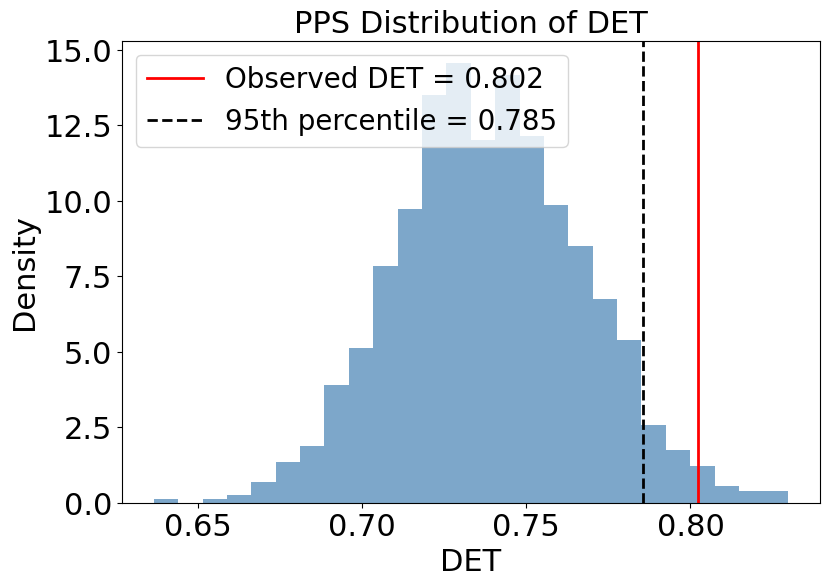

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


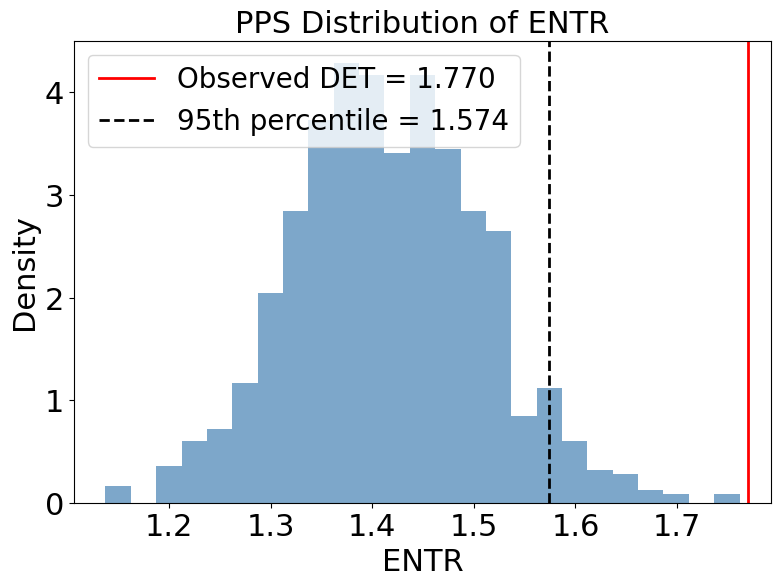

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


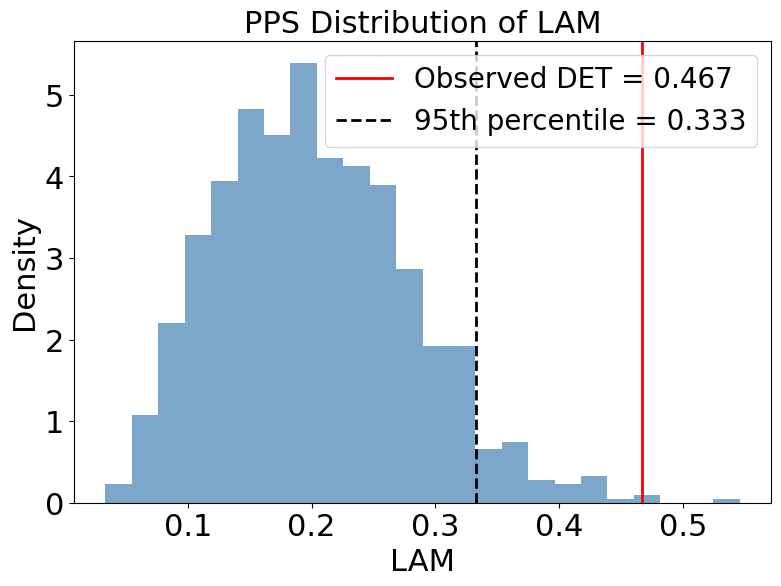

 50%|██████████████████████▌                      | 4/8 [01:05<01:09, 17.34s/it]

RQA  log_returns Embedding dimensions:6 
 DET of original:0.8023833167805303 
 Recurrence rate: 0.05000231385071035 
Threshold:1.5397999999998468 
 Laminarity:0.46668209162316826 
Shannon Entropy:1.7699114627159465 
Rank-order p-value (det):0.032 
Rank-order p-value (lam):0.008 
Rank-order p-value (entr):0.002 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 

Mean Nearest Neighbor Distance: 1.401357980652238
Pseudo-periodic surrogates generated successfullly


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


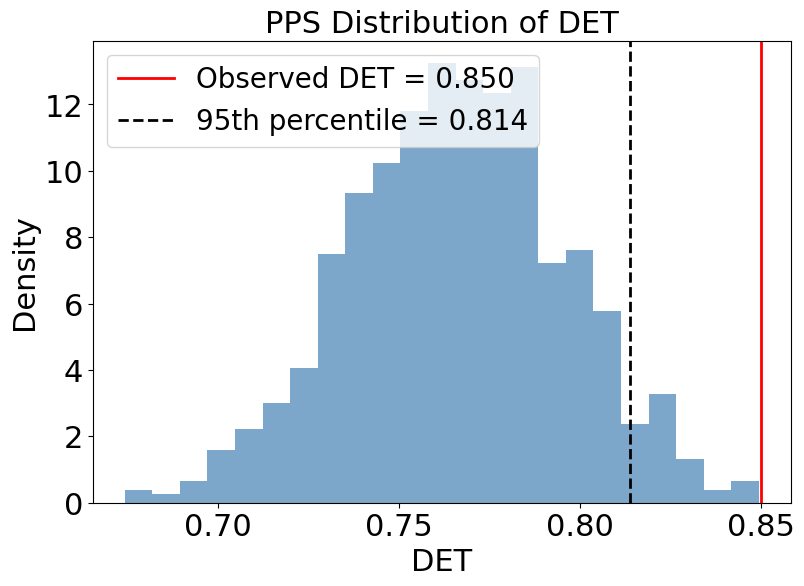

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


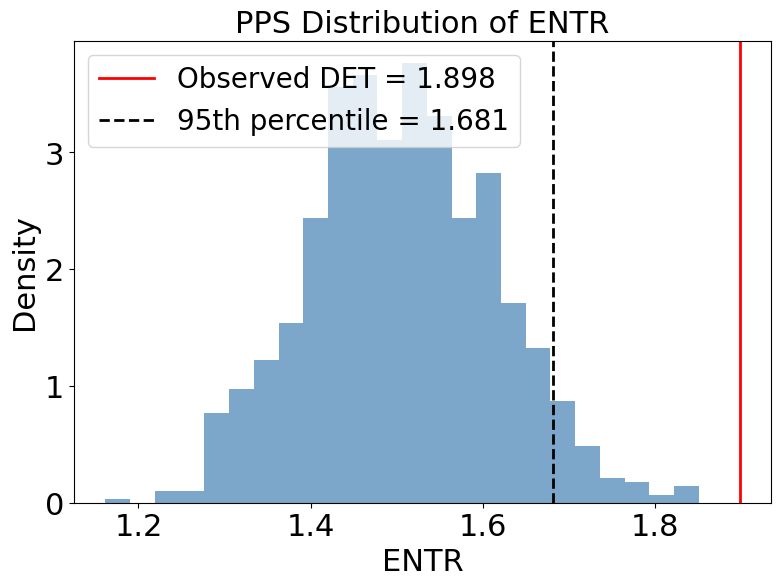

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


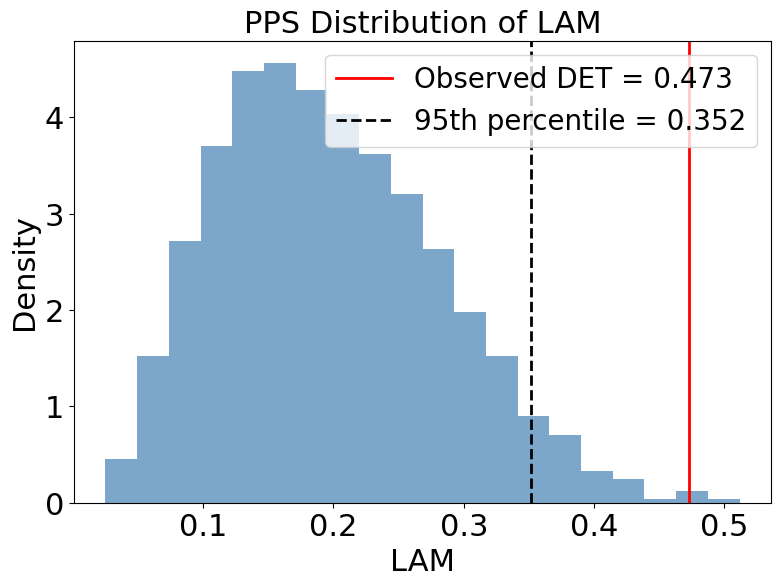

 62%|████████████████████████████▏                | 5/8 [01:28<00:58, 19.58s/it]

RQA  log_returns Embedding dimensions:7 
 DET of original:0.849999999997875 
 Recurrence rate: 0.050006406597630726 
Threshold:1.7589999999998227 
 Laminarity:0.4728627999057236 
Shannon Entropy:1.8977004217194673 
Rank-order p-value (det):0.002 
Rank-order p-value (lam):0.01 
Rank-order p-value (entr):0.002 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 

Mean Nearest Neighbor Distance: 1.638077975860093
Pseudo-periodic surrogates generated successfullly


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


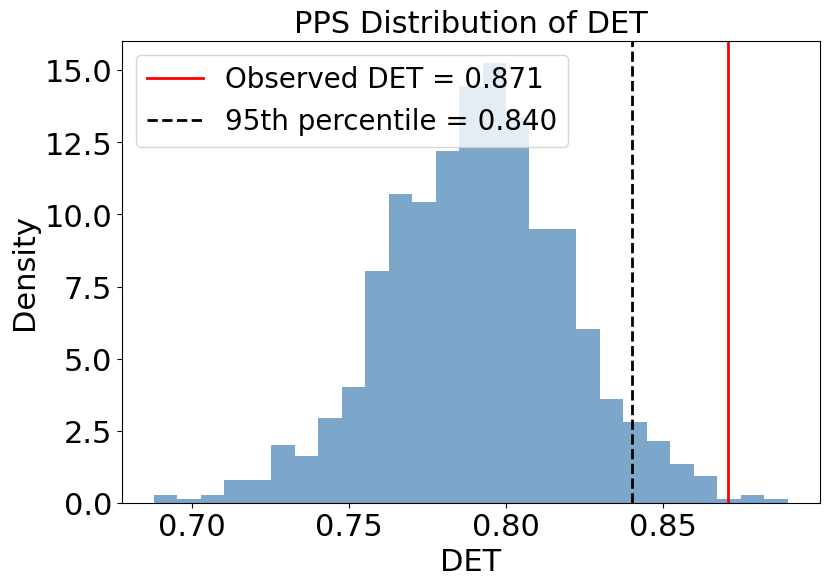

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


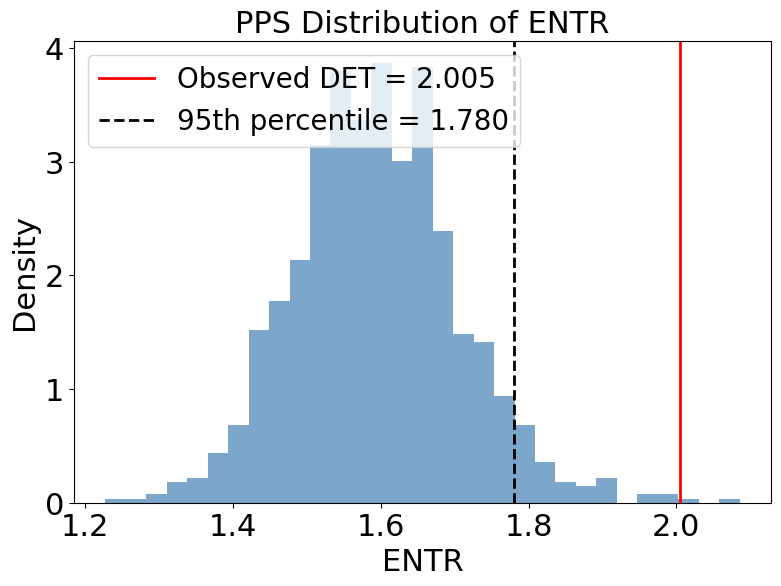

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


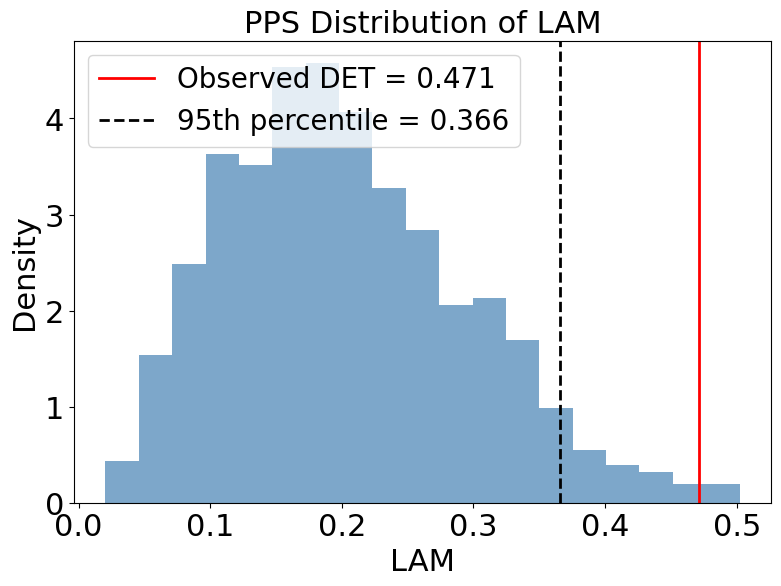

 75%|█████████████████████████████████▊           | 6/8 [01:54<00:43, 21.70s/it]

RQA  log_returns Embedding dimensions:8 
 DET of original:0.8705941591116048 
 Recurrence rate: 0.0500093826233815 
Threshold:1.9729999999997991 
 Laminarity:0.47138836772872567 
Shannon Entropy:2.0049668688089164 
Rank-order p-value (det):0.008 
Rank-order p-value (lam):0.018 
Rank-order p-value (entr):0.006 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 

Mean Nearest Neighbor Distance: 1.8327302272667017
Pseudo-periodic surrogates generated successfullly


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


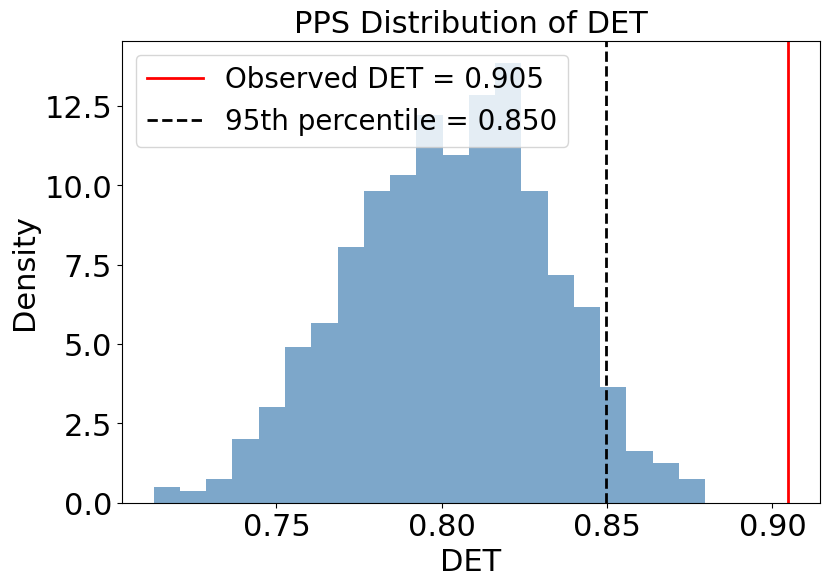

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


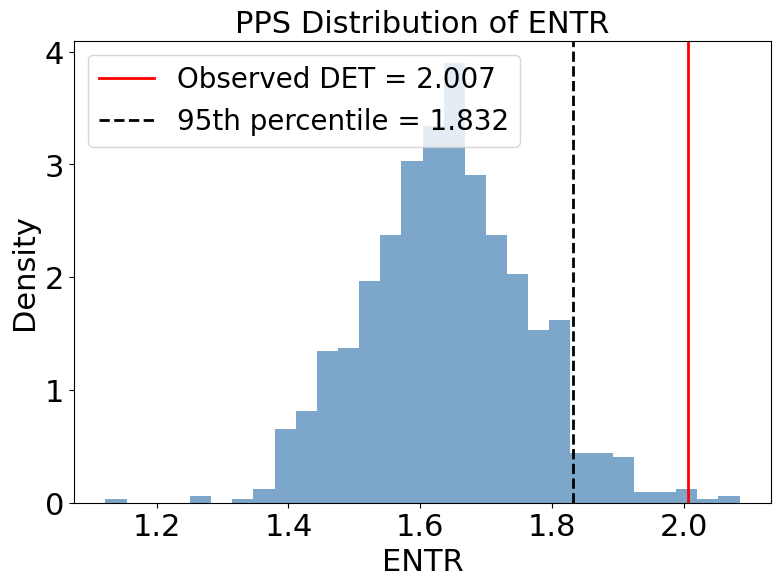

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


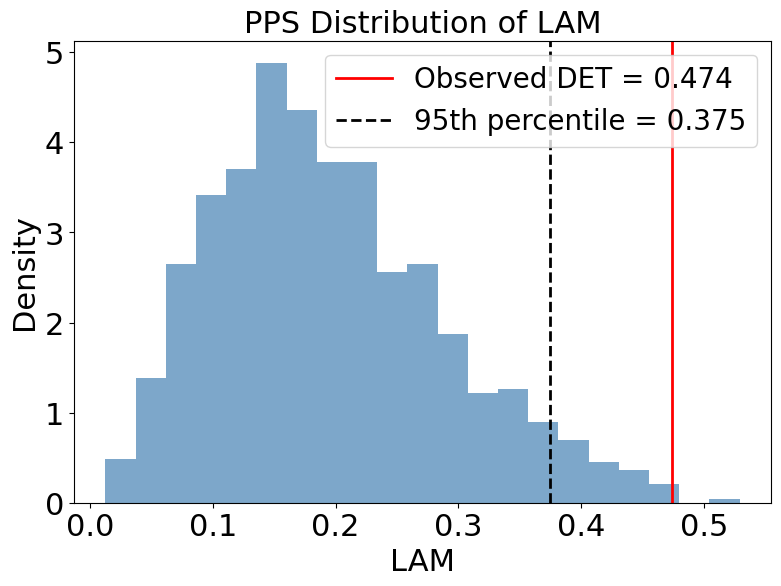

 88%|███████████████████████████████████████▍     | 7/8 [02:21<00:23, 23.41s/it]

RQA  log_returns Embedding dimensions:9 
 DET of original:0.904665314399329 
 Recurrence rate: 0.050011218573233665 
Threshold:2.1537000000001205 
 Laminarity:0.4736717827615734 
Shannon Entropy:2.0067033161242236 
Rank-order p-value (det):0.002 
Rank-order p-value (lam):0.004 
Rank-order p-value (entr):0.012 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 

Mean Nearest Neighbor Distance: 2.019856028100289
Pseudo-periodic surrogates generated successfullly


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


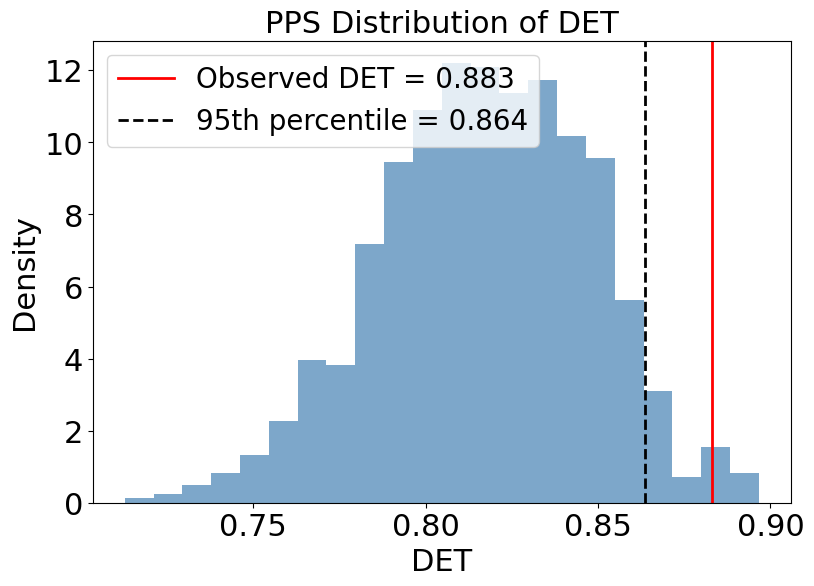

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


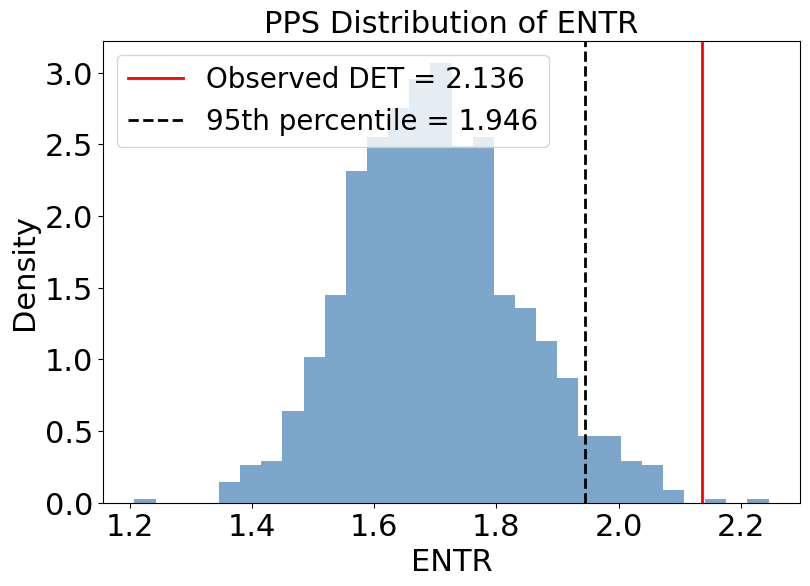

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


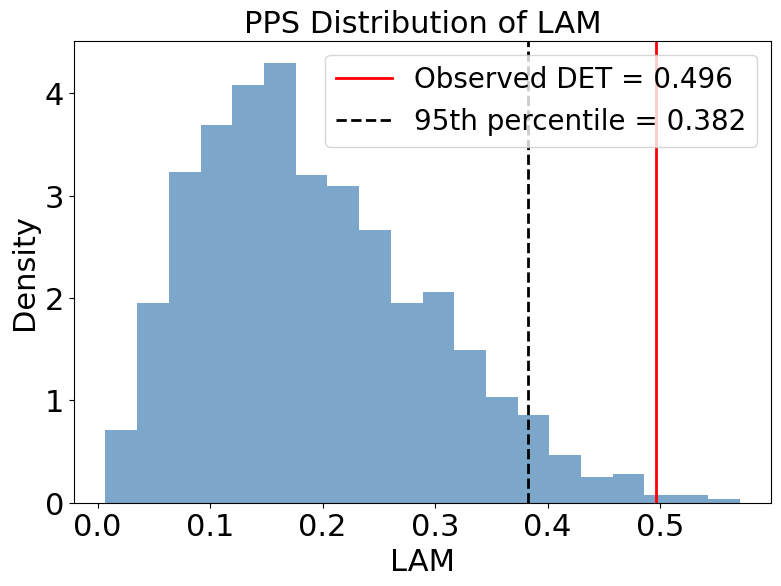

100%|█████████████████████████████████████████████| 8/8 [02:50<00:00, 21.29s/it]

RQA  log_returns Embedding dimensions:10 
 DET of original:0.8831036242958573 
 Recurrence rate: 0.05003567181926278 
Threshold:2.3423000000005185 
 Laminarity:0.49596007604444875 
Shannon Entropy:2.135983659159937 
Rank-order p-value (det):0.03 
Rank-order p-value (lam):0.008 
Rank-order p-value (entr):0.006 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



In [22]:
t_min=1
k="log_returns"
det_j=[]
embed=[]
det_surro_ff=[]
kkk=[]
lam_j=[]
ent_j=[]
lam_surro = []
ent_surro=[]
s = lcurve(k)
with open("test_output/log_returns_PP", "w") as f:
    for dim in tqdm(range(3, 11, 1)):
        tt1=0.001
        dimension=dim
        RR_orig = 0
        while RR_orig < 0.05:
            tt1 = tt1 + 0.0001
            det, RR_orig, lam_orig, entr_orig, matrix= RP_RN(s, dim, tt1)
        orig_rp=RecurrencePlot(s, dim=dimension , tau=t_min, metric = "euclidean", threshold=tt1, normalize=True, silence_level = 3)
        det_j.append(det)
        embed.append(dim)
        lam_j.append(lam_orig)
        ent_j.append(entr_orig)
        dist_matrix = orig_rp.euclidean_distance_matrix()
        np.fill_diagonal(dist_matrix, np.inf)
        nearest_neighbor_distances = np.min(dist_matrix, axis=1)
        mean_nn_distance = np.mean(nearest_neighbor_distances)
        print(f"Mean Nearest Neighbor Distance: {mean_nn_distance}")
        noise_rad = 0.7*mean_nn_distance
        subprocess.run(["julia", "PP.jl", str(noise_rad), str(dim), str(t_min), "log_returns"], text=True, check=True)
        det_ff, lam_ff, entr_ff = sur_test_PP( dim, tt1)

        fig1, ax1 = plt.subplots(1)
        qd95 = np.percentile(det_ff, 95)
        ax1.hist(det_ff,bins='auto',density=True,alpha=0.7,color='steelblue')
        ax1.axvline(det,color='red',linewidth=2,label=f'Observed DET = {det:.3f}')
        ax1.axvline(qd95,color='black',linestyle='--',linewidth=2,label=f'95th percentile = {qd95:.3f}')
        ax1.set_xlabel("DET")
        ax1.set_ylabel("Density")
        ax1.set_title("PPS Distribution of DET")
        ax1.legend()
        fig1.savefig('test_output/PP/log_returns_PP_surro_{}.eps'.format(dim), format="eps", dpi=650)
        plt.show()
        plt.close()

        fig2, ax2 = plt.subplots(1)
        qe95 = np.percentile(entr_ff, 95)
        ax2.hist(entr_ff,bins='auto',density=True,alpha=0.7,color='steelblue')
        ax2.axvline(entr_orig,color='red',linewidth=2,label=f'Observed DET = {entr_orig:.3f}')
        ax2.axvline(qe95,color='black',linestyle='--',linewidth=2,label=f'95th percentile = {qe95:.3f}')
        ax2.set_xlabel("ENTR")
        ax2.set_ylabel("Density")
        ax2.set_title("PPS Distribution of ENTR")
        ax2.legend()
        fig2.savefig('test_output/PP/log_returns_PP_surro_{}_ENTR.eps'.format(dim), format="eps", dpi=650)
        plt.show()
        plt.close()

        fig3, axs3 = plt.subplots(1)
        ql95 = np.percentile(lam_ff, 95)
        axs3.hist(lam_ff,bins='auto',density=True,alpha=0.7,color='steelblue')
        axs3.axvline(lam_orig,color='red',linewidth=2,label=f'Observed DET = {lam_orig:.3f}')
        axs3.axvline(ql95,color='black',linestyle='--',linewidth=2,label=f'95th percentile = {ql95:.3f}')
        axs3.set_xlabel("LAM")
        axs3.set_ylabel("Density")
        axs3.set_title("PPS Distribution of LAM")
        axs3.legend()
        fig3.savefig('test_output/PP/log_returns_PP_surro_{}_LAM.eps'.format(dim), format="eps", dpi=650)
        plt.show()
        plt.close()
        


        r_up = np.sum(det_ff >= det)
        r1_up = np.sum(lam_ff >= lam_orig)
        r2_up = np.sum(entr_ff >= entr_orig)
        r_down = np.sum(det_ff <= det)
        r1_down = np.sum(lam_ff <= lam_orig)
        r2_down = np.sum(entr_ff <= entr_orig)
        p_rank = min(1, 2.0 * ((min(r_up, r_down) + 1) / (999 + 1)))
        p_rank_lam = min(1, 2.0 * ((min(r1_up, r1_down) + 1) / (999 + 1)))
        p_rank_entr = min(1, 2.0 * ((min(r2_up, r2_down) + 1) / (999 + 1)))
        alpha = 0.05
        reject_null1 = p_rank < alpha
        reject_null2 = p_rank_lam < alpha
        reject_null3 = p_rank_entr < alpha
        f.write("RQA  {} Embedding dimensions:{} \n" 
            " DET of original:{} \n"
            " Recurrence rate: {} \n" 
            "Threshold:{} \n "
            "Laminarity:{} \n" 
            "Shannon Entropy:{} \n" 
            "Rank-order p-value (det):{} \n"
            "Rank-order p-value (lam):{} \n"
            "Rank-order p-value (entr):{} \n" 
            "Reject null (det) hypothesis:{}\n Reject null (lam) hypothesis:{}\n"
            "Reject null (entr) hypothesis:{}\n \n \n".format(k, dim, det, RR_orig, tt1, lam_orig, entr_orig, 
                                                              p_rank, p_rank_lam, p_rank_entr, reject_null1, reject_null2, 
                                                              reject_null3))
        print("RQA  {} Embedding dimensions:{} \n" 
            " DET of original:{} \n"
            " Recurrence rate: {} \n" 
            "Threshold:{} \n "
            "Laminarity:{} \n" 
            "Shannon Entropy:{} \n" 
            "Rank-order p-value (det):{} \n"
            "Rank-order p-value (lam):{} \n"
            "Rank-order p-value (entr):{} \n" 
            "Reject null (det) hypothesis:{}\n Reject null (lam) hypothesis:{}\n"
            "Reject null (entr) hypothesis:{}\n \n \n".format(k, dim, det, RR_orig, tt1, lam_orig, entr_orig, 
                                                              p_rank, p_rank_lam, p_rank_entr, reject_null1, reject_null2, 
                                                              reject_null3))
        det_surro_ff.append(det_ff)
        kkk.append(np.full(999, dimension))
        lam_surro.append(lam_ff)
        ent_surro.append(entr_ff)

Mean Nearest Neighbor Distance: 1.616672536631309


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Pseudo-periodic surrogates generated successfullly


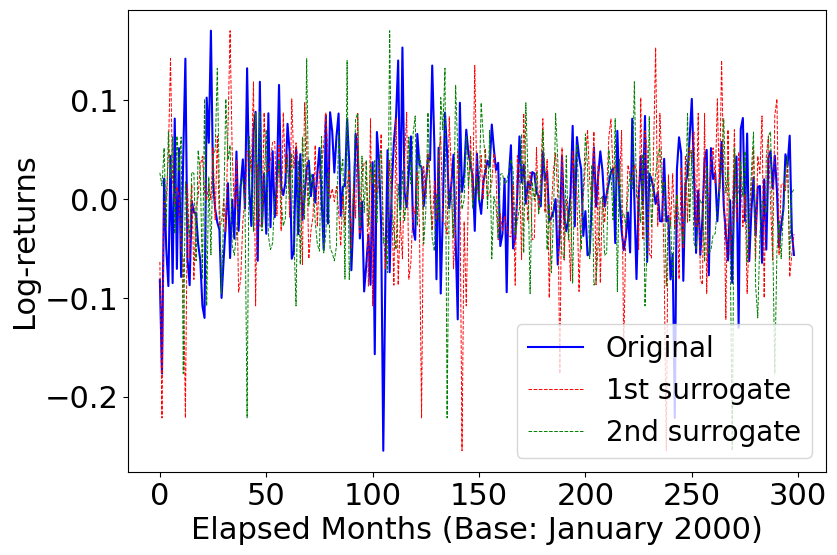

In [32]:
tt1=0.001
k="log_returns"
s = lcurve(k)
dim=8
dimension=dim
RR_orig = 0
while RR_orig < 0.05:
    tt1 = tt1 + 0.0001
    det, RR_orig, lam_orig, entr_orig, matrix= RP_RN(s, dim, tt1)
orig_rp=RecurrencePlot(s, dim=dimension , tau=t_min, metric = "euclidean", threshold=tt1, normalize=True, silence_level = 3)
dist_matrix = orig_rp.euclidean_distance_matrix()
np.fill_diagonal(dist_matrix, np.inf)
nearest_neighbor_distances = np.min(dist_matrix, axis=1)
mean_nn_distance = np.mean(nearest_neighbor_distances)
print(f"Mean Nearest Neighbor Distance: {mean_nn_distance}")
noise_rad = 0.7*mean_nn_distance
subprocess.run(["julia", "PP.jl", str(noise_rad), str(dim), str(t_min), "log_returns"], text=True, check=True)
surro1 = np.loadtxt("surro_index/PP/qp_surr_001")
surro2 = np.loadtxt("surro_index/PP/qp_surr_002")
f1, ax1 = plt.subplots(1)
ax1.plot(log_returns,linewidth=1.5,label = 'Original', color="blue")
ax1.plot(surro1, "r--",linewidth=0.7,label = '1st surrogate')
ax1.plot(surro2, "g--",linewidth=0.7, label = '2nd surrogate')

plt.xlabel("Elapsed Months (Base: January 2000)")
plt.legend()
plt.ylabel("Log-returns")
f1.savefig('test_output/PP_surrogates_log.eps', format="eps", dpi=650)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


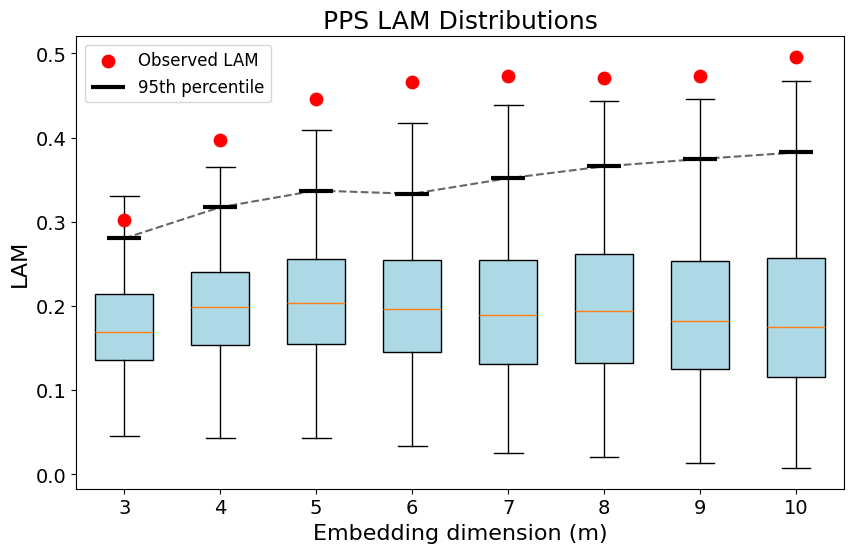

In [19]:

fig, ax = plt.subplots(1)

# Use actual embedding dimensions
dims = embed    # e.g. [3,4,5,6,7,8,9,10,11,12]

# Boxplots of surrogate DET distributions
bp = ax.boxplot(
    lam_surro,
    positions=dims,
    widths=0.6,
    patch_artist=True,
    showfliers=False
)

for box in bp['boxes']:
    box.set(
        facecolor='lightblue',
        edgecolor='black'
    )

# Observed DET values
ax.scatter(
    dims,
    lam_j,
    color='red',
    s=80,
    zorder=10,
    label='Observed LAM'
)

# 95th percentile of surrogate distributions
ql95 = [
    np.percentile(x, 95)
    for x in lam_surro
]

ax.scatter(
    dims,
    ql95,
    color='black',
    marker='_',
    s=600,
    linewidths=3,
    zorder=11,
    label='95th percentile'
)

# Connect the 95th percentiles
ax.plot(
    dims,
    ql95,
    'k--',
    alpha=0.6
)

ax.set_xticks(dims)

ax.set_xlabel(
    "Embedding dimension (m)",
    fontsize=16
)

ax.set_ylabel(
    "LAM",
    fontsize=16
)

ax.set_title(
    "PPS LAM Distributions",
    fontsize=18
)

ax.tick_params(
    axis='both',
    labelsize=14
)

ax.legend(fontsize=12)

plt.tight_layout()

fig.savefig(
    "test_output/WIAAFT/PP_log_surro_lam_m.eps",
    format="eps",
    dpi=650,
    bbox_inches="tight"
)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


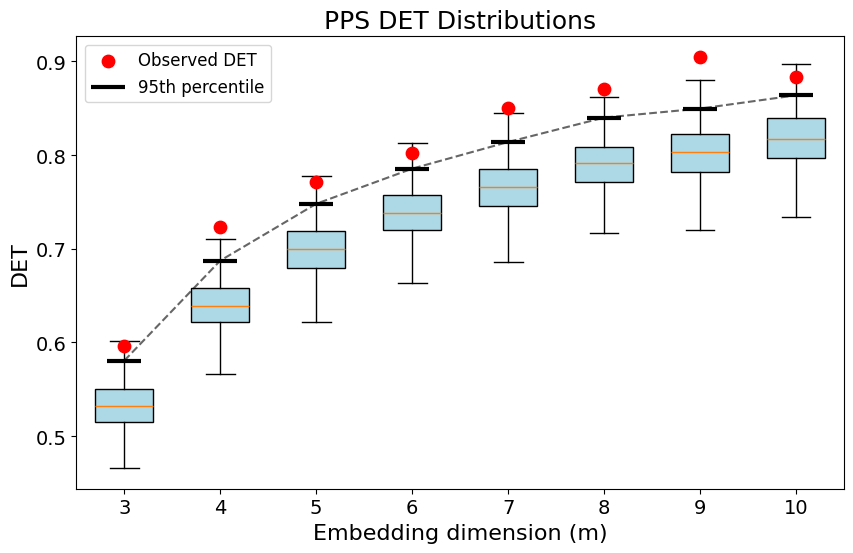

In [20]:

fig, ax = plt.subplots(1)

# Use actual embedding dimensions
dims = embed    # e.g. [3,4,5,6,7,8,9,10,11,12]

# Boxplots of surrogate DET distributions
bp = ax.boxplot(
    det_surro_ff,
    positions=dims,
    widths=0.6,
    patch_artist=True,
    showfliers=False
)

for box in bp['boxes']:
    box.set(
        facecolor='lightblue',
        edgecolor='black'
    )

# Observed DET values
ax.scatter(
    dims,
    det_j,
    color='red',
    s=80,
    zorder=10,
    label='Observed DET'
)

# 95th percentile of surrogate distributions
q95 = [
    np.percentile(x, 95)
    for x in det_surro_ff
]

ax.scatter(
    dims,
    q95,
    color='black',
    marker='_',
    s=600,
    linewidths=3,
    zorder=11,
    label='95th percentile'
)

# Connect the 95th percentiles
ax.plot(
    dims,
    q95,
    'k--',
    alpha=0.6
)

ax.set_xticks(dims)

ax.set_xlabel(
    "Embedding dimension (m)",
    fontsize=16
)

ax.set_ylabel(
    "DET",
    fontsize=16
)

ax.set_title(
    "PPS DET Distributions",
    fontsize=18
)

ax.tick_params(
    axis='both',
    labelsize=14
)

ax.legend(fontsize=12)

plt.tight_layout()

fig.savefig(
    "test_output/PP/PP_log_surro_m.eps",
    format="eps",
    dpi=650,
    bbox_inches="tight"
)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


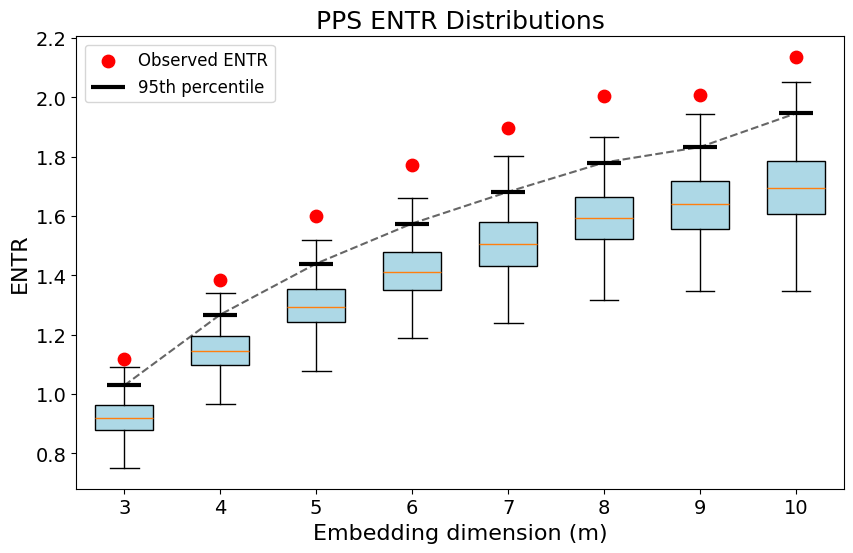

In [21]:

fig, ax = plt.subplots(1)

# Use actual embedding dimensions
dims = embed    # e.g. [3,4,5,6,7,8,9,10,11,12]

# Boxplots of surrogate DET distributions
bp = ax.boxplot(
    ent_surro,
    positions=dims,
    widths=0.6,
    patch_artist=True,
    showfliers=False
)

for box in bp['boxes']:
    box.set(
        facecolor='lightblue',
        edgecolor='black'
    )

# Observed DET values
ax.scatter(
    dims,
    ent_j,
    color='red',
    s=80,
    zorder=10,
    label='Observed ENTR'
)

# 95th percentile of surrogate distributions
qe95 = [
    np.percentile(x, 95)
    for x in ent_surro
]

ax.scatter(
    dims,
    qe95,
    color='black',
    marker='_',
    s=600,
    linewidths=3,
    zorder=11,
    label='95th percentile'
)

# Connect the 95th percentiles
ax.plot(
    dims,
    qe95,
    'k--',
    alpha=0.6
)

ax.set_xticks(dims)

ax.set_xlabel(
    "Embedding dimension (m)",
    fontsize=16
)

ax.set_ylabel(
    "ENTR",
    fontsize=16
)

ax.set_title(
    "PPS ENTR Distributions",
    fontsize=18
)

ax.tick_params(
    axis='both',
    labelsize=14
)

ax.legend(fontsize=12)

plt.tight_layout()

fig.savefig(
    "test_output/PP/PP_log_surro_entr_m.eps",
    format="eps",
    dpi=650,
    bbox_inches="tight"
)

plt.show()

{'m': 8,
 'fnn_value': 0.3684211,
 'method': 'No saturation detected (minimum FNN fallback)'}

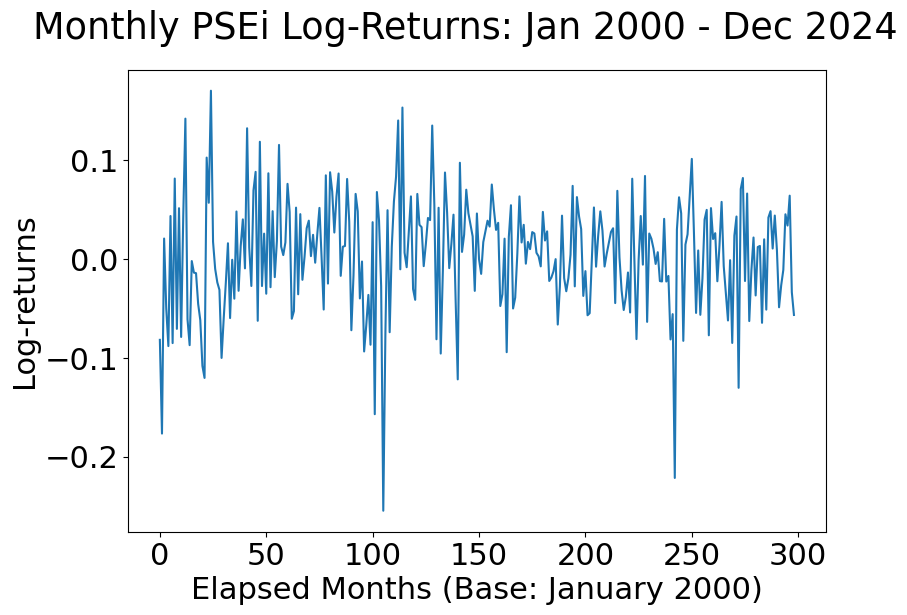

In [26]:
f1, ax1 = plt.subplots(1)
f1.suptitle("Monthly PSEi Log-Returns: Jan 2000 - Dec 2024")
ax1.plot(log_returns)
plt.xlabel("Elapsed Months (Base: January 2000)")
plt.ylabel("Log-returns")
f1.savefig('test_output/log_returns.eps', format="eps", dpi=650)
extract_embedding_dimension("log_returns")

# Delay Embedding

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


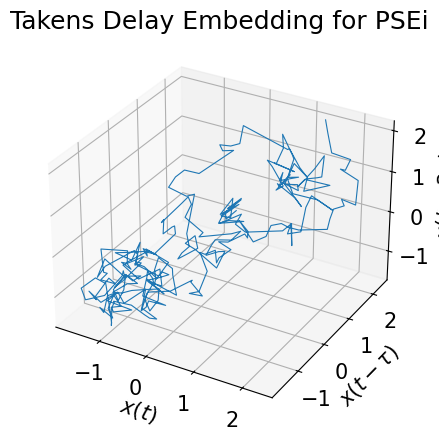

In [17]:
rp = RecurrencePlot(data, dim=4, tau=6, metric="euclidean", normalize=True,   silence_level=3,threshold = 0.326)
X = rp.embedding


fig = plt.figure()
ax = fig.add_subplot(projection="3d")

ax.plot(X[:, 0], X[:, 1], X[:, 2], lw=0.8)
ax.set_xlabel(r"$x(t)$")
ax.set_ylabel(r"$x(t-\tau)$")
ax.set_zlabel(r"$x(t-2\tau)$")
ax.set_title("Takens Delay Embedding for PSEi")
fig.savefig("delay_embed.eps", format="eps", dpi=650)
plt.show()
plt.close()

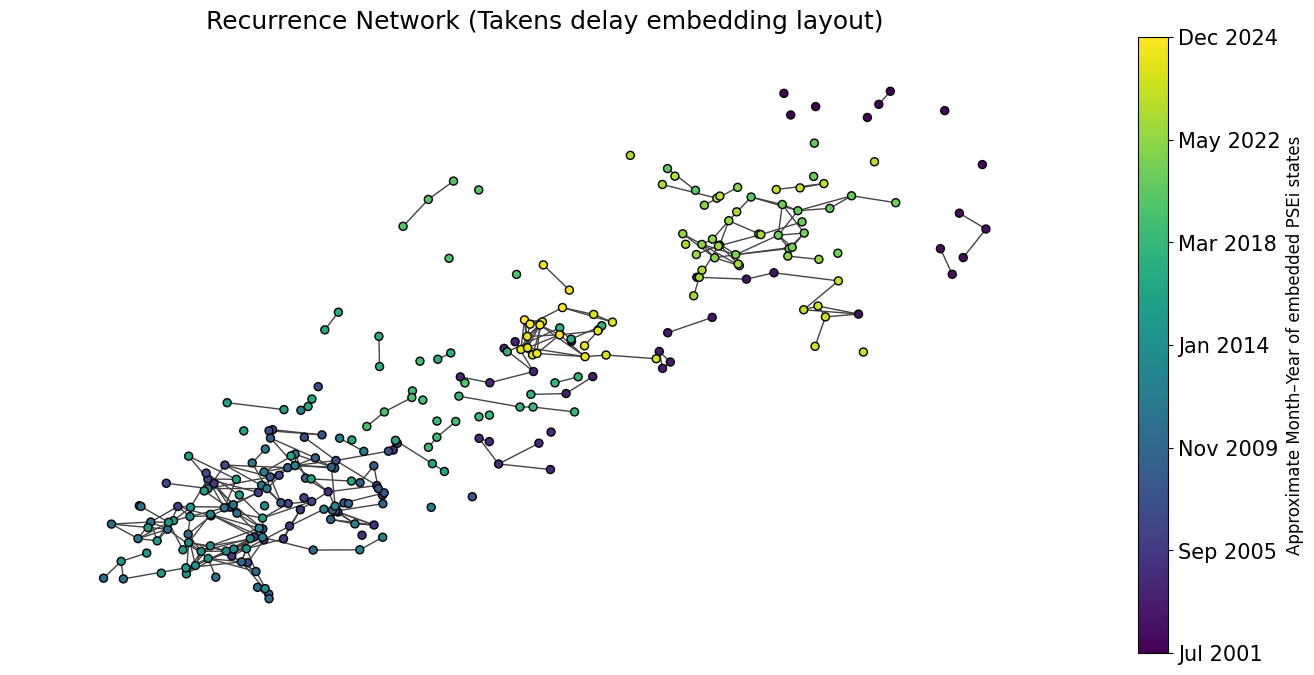

In [18]:
import igraph as ig
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import calendar


months = []
for year in range(2000, 2025):
    for m in range(1, 13):
        months.append(f"{calendar.month_abbr[m]} {year}")

offset = (4 - 1) * 6   # (m - 1)*tau = 18
months_embedded = months[offset:]

indices = [0, 50, 100, 150, 200, 250, len(months_embedded) - 1]
selected_labels = [months_embedded[i] for i in indices]


rn = RecurrenceNetwork( data, dim=4, tau=6,metric="euclidean",threshold=0.326,normalize=True,silence_level=3)

A = rn.adjacency
g = ig.Graph.Adjacency(A.tolist(), mode="undirected")
g_size = g.vcount()

coords = X[:, [0, 1]]
layout = ig.Layout(coords.tolist())

colors = [plt.cm.viridis(i / (g_size - 1)) for i in range(g_size)]

fig, ax = plt.subplots(figsize=(15, 8))
ig.plot(g, target=ax, layout=layout,vertex_size=8,vertex_color=colors,edge_width=1)

ax.set_title("Recurrence Network (Takens delay embedding layout)")


norm = Normalize(vmin=0, vmax=g_size - 1)
sm = ScalarMappable(norm=norm, cmap=plt.cm.viridis)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax,orientation='vertical',fraction=0.03,pad=0.05)

tick_positions = np.linspace(0, g_size - 1, len(indices))
cbar.set_ticks(tick_positions)
cbar.set_ticklabels(selected_labels)
cbar.set_label('Approximate Month–Year of embedded PSEi states', fontsize=12)

fig.savefig("network.eps", format="eps", dpi=650)
plt.show()
plt.close()

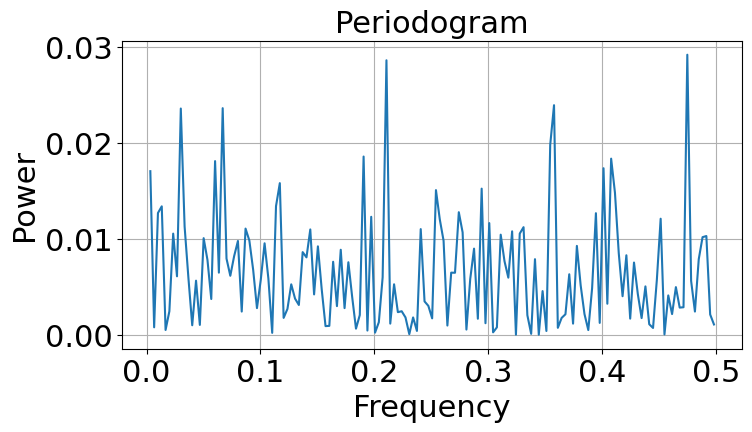

2.1056338028169015


In [25]:
from scipy.signal import periodogram
import numpy as np
import matplotlib.pyplot as plt



freq, power = periodogram(log_returns)

plt.figure(figsize=(8,4))
plt.plot(freq[1:], power[1:])
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.title("Periodogram")
plt.grid(True)
plt.show()
idx = np.argmax(power[1:]) + 1

dominant_frequency = freq[idx]

dominant_period = 1 / dominant_frequency

print(dominant_period)